In [1]:
# jump Enhance process cell to avoid too much effort
import pandas as pd, numpy as np

# === 路徑 ===
a_path = 'forTrain_ds_doService.csv'   # Service features
b_path = 'forTrain_ds_bill_24_onehot.csv'     # Billing features
c_path = 'enhanced_customer_features_with_LLM.csv'  # CSR features with LLM sentiment
d_path = 'cleaned_dataset_fix_20241231.csv'                    # customer final status @2024/12/31
out_path = 'csr_service_bill_SFSS.csv'

# === A, B ===
a = pd.read_csv(a_path, sep='^').rename(columns={'客編': 'CUST_NO'})
b = pd.read_csv(b_path, sep=',').rename(columns={'客編': 'CUST_NO'})
c = pd.read_csv(c_path, sep=',')
d = pd.read_csv(d_path, sep='^').rename(columns={'客編': 'CUST_NO'})


✅ 已載入字型： ['Noto Sans TC']


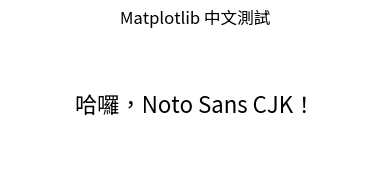

In [2]:
# 跨平台載入 Noto Sans CJK 字型並驗證
"""
跨平台載入 Noto Sans CJK 字型並驗證
在 VS Code + 本地 Python 環境執行
"""

import os
import sys
import platform
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---------- 1. 推斷各作業系統的預設字型路徑 ----------
def guess_noto_path() -> str | None:
    """回傳可能存在的 NotoSansCJK-Regular.ttc 路徑，找不到則回傳 None"""
    candidates = []

    match platform.system():
        case "Windows":
            candidates = [
                r"C:\Windows\Fonts\NotoSansCJK-Regular.ttc",
                r"C:\Windows\Fonts\NotoSansCJKtc-Regular.otf",
            ]
        case "Darwin":  # macOS
            candidates = [
                "/Library/Fonts/NotoSansCJK-Regular.ttc",
                "/System/Library/Fonts/NotoSansCJK.ttc",
            ]
        case "Linux":
            # 常見安裝位置；亦可加入 ~/.local/share/fonts
            candidates = [
                "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
                "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
                str(Path.home() / ".local/share/fonts/NotoSansCJK-Regular.ttc"),
            ]

    for p in candidates:
        if Path(p).is_file():
            return p
    return None


# ---------- 2. 取得字型路徑（可改為專案內相對路徑） ----------
# font_path = guess_noto_path()
font_path = 'NotoSansTC-Regular.ttf'  # 若已下載字型檔，請確認路徑正確

if font_path is None:
    # 若系統沒安裝，可改成專案相對路徑，例如 Path("fonts/NotoSansCJK-Regular.ttc")
    font_path = "fonts/NotoSansCJK-Regular.ttc"  # 請確認實際檔案位置
    if not Path(font_path).is_file():
        sys.exit(
            f"❌ 找不到 Noto Sans CJK 字型！\n"
            f"  請先安裝字型或把字型檔放到 {font_path}"
        )

# ---------- 3. 動態註冊並設定為預設中文字型 ----------
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()

# ---------- 4. 驗證 ----------
print("✅ 已載入字型：", plt.rcParams["font.family"])

# (可選) 畫個示範圖
plt.figure(figsize=(4, 2))
plt.title("Matplotlib 中文測試")
plt.text(0.5, 0.5, "哈囉，Noto Sans CJK！", ha="center", va="center", size=16)
plt.axis("off")
plt.tight_layout()
plt.show()


In [3]:
# 列印a資料集的所有欄位
print("=== a資料集所有欄位列表 ===")
print(f"a資料集形狀: {a.shape}")
print(f"總欄位數: {len(a.columns)}")
print()

# 列印所有欄位名稱
print("所有欄位:")
for i, col in enumerate(a.columns, 1):
    print(f"{i:3d}. {col}")

# 額外顯示欄位的資料型態
print(f"\n=== 欄位資料型態統計 ===")
dtype_counts = a.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"{dtype}: {count} 個欄位")

# 顯示前幾筆資料的欄位內容作為參考
print(f"\n=== 前3筆資料預覽 ===")
print(a.head(3))

=== a資料集所有欄位列表 ===
a資料集形狀: (52473, 44)
總欄位數: 44

所有欄位:
  1. CUST_NO
  2. 工單原因_主要
  3. 工單原因_次要
  4. 工單原因_種類數
  5. 工單原因_最新
  6. 工單原因_最舊
  7. 工單原因_重複率
  8. 工單嚴重程度_平均
  9. 工單嚴重程度_最高
 10. 工單升級趨勢
 11. 工單原因_文字特徵
 12. 工單原因_其他_測試正常_次數
 13. 工單原因_其他_測試正常_是否發生
 14. 工單原因_其他_測試正常_佔比
 15. 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_次數
 16. 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生
 17. 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_佔比
 18. 工單原因_Epon實體問題_光纖斷裂_次數
 19. 工單原因_Epon實體問題_光纖斷裂_是否發生
 20. 工單原因_Epon實體問題_光纖斷裂_佔比
 21. 工單原因_用戶端問題_數據機故,更換_次數
 22. 工單原因_用戶端問題_數據機故,更換_是否發生
 23. 工單原因_用戶端問題_數據機故,更換_佔比
 24. 工單原因_RF線路問題_改良線路_次數
 25. 工單原因_RF線路問題_改良線路_是否發生
 26. 工單原因_RF線路問題_改良線路_佔比
 27. 工單原因_其他_次數
 28. 工單原因_其他_是否發生
 29. 工單原因_其他_佔比
 30. 工單原因_RF線路問題_調整訊號_次數
 31. 工單原因_RF線路問題_調整訊號_是否發生
 32. 工單原因_RF線路問題_調整訊號_佔比
 33. 工單原因_用戶端問題_用戶不善操作_次數
 34. 工單原因_用戶端問題_用戶不善操作_是否發生
 35. 工單原因_用戶端問題_用戶不善操作_佔比
 36. 產品名稱
 37. 使用狀態
 38. 最新工單日期
 39. 工單日期
 40. 30天內
 41. 60天內
 42. 90天內
 43. 90天以上
 44. 平均等待天數

=== 欄位資料型態統計 ===
int64: 23 個欄位
float64: 12 個欄位
object: 9 個欄位

=== 前3筆資料預覽 

=== 分析a資料集中工單日期的年份分布 ===
使用的日期欄位: 工單日期

=== 工單日期基本統計 ===
工單日期範圍: 2021-12-28 19:23:16 至 2025-01-23 23:41:04
總工單數: 52473
工單年份範圍: 2021 - 2025

=== 工單數量按年份分布 ===
2021年: 1 筆 (0.0%)
2022年: 10,685 筆 (20.4%)
2023年: 14,626 筆 (27.9%)
2024年: 25,361 筆 (48.3%)
2025年: 1,800 筆 (3.4%)


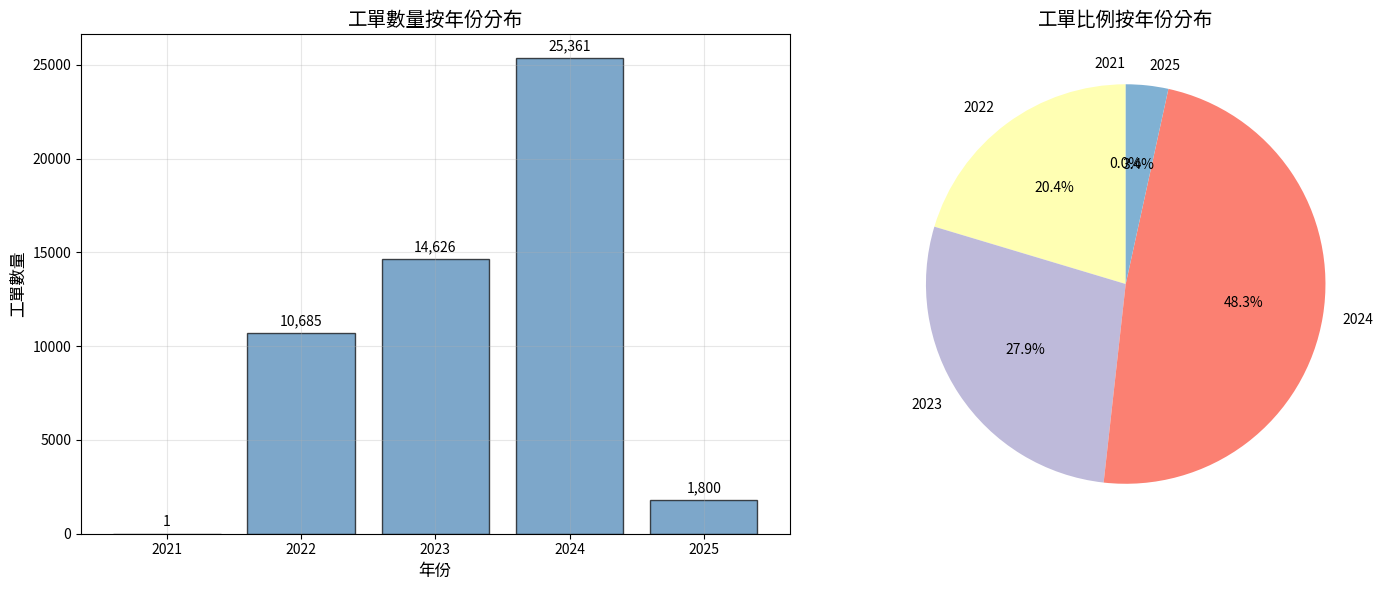


=== 進階分析 ===
年度間差異:
年度變化率:
2021 → 2022: +1068400.0%
2022 → 2023: +36.9%
2023 → 2024: +73.4%
2024 → 2025: -92.9%

工單最多的年份: 2024年 (25,361 筆)
工單最少的年份: 2021年 (1 筆)

=== 統計摘要 ===
平均每年工單數: 10495 筆
工單數標準差: 10294 筆
工單數變異係數: 0.98


In [4]:
# 分析工單日期的年份分布
print("=== 分析a資料集中工單日期的年份分布 ===")

# 確保工單日期是datetime格式
if '工單日期' in a.columns:
    date_col = '工單日期'
elif '工單日' in a.columns:
    date_col = '工單日'
else:
    # 找出可能的日期欄位
    date_cols = [col for col in a.columns if '日期' in col or '日' in col]
    print(f"找到的日期相關欄位: {date_cols}")
    if date_cols:
        date_col = date_cols[0]
    else:
        print("❌ 找不到工單日期相關欄位")
        print(f"可用欄位: {list(a.columns[:10])}...")

if 'date_col' in locals():
    print(f"使用的日期欄位: {date_col}")
    
    # 轉換為datetime格式
    a[date_col] = pd.to_datetime(a[date_col], errors='coerce')
    
    # 檢查轉換結果
    invalid_dates = a[date_col].isnull().sum()
    if invalid_dates > 0:
        print(f"⚠️ 有 {invalid_dates} 筆無法轉換的日期")
    
    # 提取年份
    a['工單年份'] = a[date_col].dt.year
    
    # 基本統計
    print(f"\n=== 工單日期基本統計 ===")
    print(f"工單日期範圍: {a[date_col].min()} 至 {a[date_col].max()}")
    print(f"總工單數: {len(a)}")
    print(f"工單年份範圍: {a['工單年份'].min()} - {a['工單年份'].max()}")
    
    # 按年份統計
    print(f"\n=== 工單數量按年份分布 ===")
    yearly_counts = a['工單年份'].value_counts().sort_index()
    yearly_percentage = (yearly_counts / yearly_counts.sum() * 100)
    
    for year, count in yearly_counts.items():
        percentage = yearly_percentage[year]
        print(f"{int(year)}年: {count:,} 筆 ({percentage:.1f}%)")
    
    # 視覺化
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 年份分布柱狀圖
    ax1.bar(yearly_counts.index, yearly_counts.values, 
            color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_title('工單數量按年份分布', fontsize=14, fontweight='bold')
    ax1.set_xlabel('年份', fontsize=12)
    ax1.set_ylabel('工單數量', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # 為每個柱子添加數值標籤
    for i, v in enumerate(yearly_counts.values):
        ax1.text(yearly_counts.index[i], v + max(yearly_counts.values)*0.01, 
                f'{v:,}', ha='center', va='bottom', fontsize=10)
    
    # 年份分布圓餅圖
    ax2.pie(yearly_counts.values, labels=yearly_counts.index, autopct='%1.1f%%',
            startangle=90, colors=plt.cm.Set3(range(len(yearly_counts))))
    ax2.set_title('工單比例按年份分布', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # 進階分析
    print(f"\n=== 進階分析 ===")
    print(f"年度間差異:")
    
    # 計算年度增長率
    if len(yearly_counts) > 1:
        print("年度變化率:")
        for i in range(1, len(yearly_counts)):
            current_year = yearly_counts.index[i]
            prev_year = yearly_counts.index[i-1]
            current_count = yearly_counts.iloc[i]
            prev_count = yearly_counts.iloc[i-1]
            
            growth_rate = ((current_count - prev_count) / prev_count) * 100
            print(f"{int(prev_year)} → {int(current_year)}: {growth_rate:+.1f}%")
    
    # 找出工單最多和最少的年份
    max_year = yearly_counts.idxmax()
    min_year = yearly_counts.idxmin()
    print(f"\n工單最多的年份: {int(max_year)}年 ({yearly_counts[max_year]:,} 筆)")
    print(f"工單最少的年份: {int(min_year)}年 ({yearly_counts[min_year]:,} 筆)")
    
    # 統計資訊
    print(f"\n=== 統計摘要 ===")
    print(f"平均每年工單數: {yearly_counts.mean():.0f} 筆")
    print(f"工單數標準差: {yearly_counts.std():.0f} 筆")
    print(f"工單數變異係數: {yearly_counts.std()/yearly_counts.mean():.2f}")

else:
    print("❌ 無法找到適合的工單日期欄位進行分析")

In [5]:
# 保留a資料集中工單日期為2024年的資料，其餘刪去
print("=== 篩選a資料集：僅保留2024年工單資料 ===")

# 檢查篩選前的狀況
print(f"篩選前a資料集形狀: {a.shape}")

# 尋找日期欄位
date_col = None
if '工單日期' in a.columns:
    date_col = '工單日期'
elif '工單日' in a.columns:
    date_col = '工單日'
else:
    # 找出可能的日期欄位
    date_cols = [col for col in a.columns if '日期' in col or '日' in col]
    print(f"找到的日期相關欄位: {date_cols}")
    if date_cols:
        date_col = date_cols[0]
        print(f"使用欄位: {date_col}")

if date_col is None:
    print("❌ 找不到工單日期相關欄位")
    print(f"可用欄位: {list(a.columns)}")
else:
    # 轉換日期欄位為datetime格式
    print(f"使用日期欄位: {date_col}")
    
    # 檢查原始資料格式
    print(f"原始日期資料範例:")
    print(a[date_col].head())
    print(f"資料型態: {a[date_col].dtype}")
    
    # 轉換為datetime格式
    try:
        # 嘗試直接轉換
        a[date_col] = pd.to_datetime(a[date_col], errors='coerce')
        print("✅ 日期轉換成功")
    except Exception as e:
        print(f"日期轉換失敗，嘗試其他格式: {e}")
        # 嘗試不同的日期格式
        for fmt in ['%Y%m%d', '%Y-%m-%d', '%Y/%m/%d']:
            try:
                a[date_col] = pd.to_datetime(a[date_col], format=fmt, errors='coerce')
                print(f"✅ 使用格式 {fmt} 轉換成功")
                break
            except:
                continue
        else:
            print("❌ 無法轉換日期格式")
    
    # 檢查轉換後的結果
    invalid_dates = a[date_col].isnull().sum()
    if invalid_dates > 0:
        print(f"⚠️ 有 {invalid_dates} 筆無法轉換的日期")
    
    # 提取年份
    a['工單年份'] = a[date_col].dt.year
    
    # 顯示篩選前的年份分布
    print(f"\n=== 篩選前年份分布 ===")
    yearly_counts_before = a['工單年份'].value_counts().sort_index()
    print("各年份工單數量:")
    for year, count in yearly_counts_before.items():
        if not pd.isna(year):
            print(f"  {int(year)}年: {count:,} 筆")
    
    # 篩選僅保留2023年和2024年的資料
    print(f"\n=== 執行2023年和2024年資料篩選 ===")
    
    # 檢查2023年和2024年資料是否存在
    year_2023_count = (a['工單年份'] == 2023).sum()
    year_2024_count = (a['工單年份'] == 2024).sum()
    # target_years_count = year_2023_count + year_2024_count
    target_years_count = year_2024_count
    
    print(f"2023年工單數量: {year_2023_count:,} 筆")
    print(f"2024年工單數量: {year_2024_count:,} 筆")
    print(f"目標年份總計: {target_years_count:,} 筆")
    
    if target_years_count == 0:
        print("❌ 警告：沒有找到2023年或2024年的工單資料！")
        print("可用的年份:")
        available_years = a['工單年份'].dropna().unique()
        for year in sorted(available_years):
            print(f"  {int(year)}")
    else:
        # 執行篩選
        # a_filtered = a[a['工單年份'].isin([2023, 2024])].copy()
        a_filtered = a[a['工單年份'].isin([2024])].copy()
        
        print(f"\n=== 篩選結果 ===")
        print(f"篩選前總筆數: {len(a):,}")
        print(f"篩選後總筆數: {len(a_filtered):,}")
        print(f"刪除筆數: {len(a) - len(a_filtered):,}")
        print(f"保留比例: {len(a_filtered) / len(a) * 100:.1f}%")
        
        # 檢查客戶數量變化
        customers_before = a['CUST_NO'].nunique() if 'CUST_NO' in a.columns else None
        customers_after = a_filtered['CUST_NO'].nunique() if 'CUST_NO' in a_filtered.columns else None
        
        if customers_before and customers_after:
            print(f"篩選前客戶數: {customers_before:,}")
            print(f"篩選後客戶數: {customers_after:,}")
            print(f"客戶保留比例: {customers_after / customers_before * 100:.1f}%")
        
        # 驗證篩選結果
        remaining_years = a_filtered['工單年份'].unique()
        print(f"\n=== 篩選驗證 ===")
        print(f"篩選後剩餘年份: {sorted([int(year) for year in remaining_years if not pd.isna(year)])}")
        
        # valid_years = set([2023, 2024])
        valid_years = set([2024])
        actual_years = set([int(year) for year in remaining_years if not pd.isna(year)])
        
        if actual_years.issubset(valid_years):
            print("✅ 篩選成功：僅包含2024年資料")
        else:
            extra_years = actual_years - valid_years
            print(f"⚠️ 篩選後仍包含其他年份資料: {extra_years}")
        
        # 顯示2023年和2024年各月份分布
        if len(a_filtered) > 0:
            print(f"\n=== 各月份分布 ===")
            a_filtered['工單月份'] = a_filtered[date_col].dt.month
            
            for year in valid_years:
                year_data = a_filtered[a_filtered['工單年份'] == year]
                if len(year_data) > 0:
                    print(f"\n{year}年各月份分布:")
                    monthly_counts = year_data['工單月份'].value_counts().sort_index()
                    
                    for month, count in monthly_counts.items():
                        if not pd.isna(month):
                            print(f"  {int(month):2d}月: {count:,} 筆")
        
        # 更新a變數
        a = a_filtered.copy()
        
        # 清理臨時欄位
        columns_to_drop = ['工單年份', '工單月份']
        existing_temp_cols = [col for col in columns_to_drop if col in a.columns]
        if existing_temp_cols:
            a = a.drop(columns=existing_temp_cols)
            print(f"\n✅ 已清理臨時欄位: {existing_temp_cols}")
        
        print(f"\n✅ 工單資料篩選完成")
        print(f"最終a資料集形狀: {a.shape}")
        
        # 顯示最終統計
        print(f"\n=== 最終統計資訊 ===")
        print(f"保留的工單數量: {len(a):,} 筆")
        if 'CUST_NO' in a.columns:
            print(f"涉及客戶數量: {a['CUST_NO'].nunique():,} 位")
        
        # 顯示日期範圍
        if len(a) > 0:
            date_range_start = a[date_col].min()
            date_range_end = a[date_col].max()
            print(f"日期範圍: {date_range_start.strftime('%Y-%m-%d')} 至 {date_range_end.strftime('%Y-%m-%d')}")
        
        # 顯示最終年份分布
        final_a_years = pd.to_datetime(a[date_col]).dt.year
        final_yearly_counts = final_a_years.value_counts().sort_index()
        print(f"\n篩選後年份分布:")
        for year, count in final_yearly_counts.items():
            print(f"  {int(year)}年: {count:,} 筆 ({count/len(a)*100:.1f}%)")
            
        print(f"\n✅ 所有非篩選年份以外的工單資料已成功刪除")

=== 篩選a資料集：僅保留2024年工單資料 ===
篩選前a資料集形狀: (52473, 45)
使用日期欄位: 工單日期
原始日期資料範例:
0   2023-09-04 21:19:20
1   2022-08-26 20:58:06
2   2022-04-13 21:29:02
3   2024-03-12 20:52:06
4   2023-10-13 14:48:42
Name: 工單日期, dtype: datetime64[ns]
資料型態: datetime64[ns]
✅ 日期轉換成功

=== 篩選前年份分布 ===
各年份工單數量:
  2021年: 1 筆
  2022年: 10,685 筆
  2023年: 14,626 筆
  2024年: 25,361 筆
  2025年: 1,800 筆

=== 執行2023年和2024年資料篩選 ===
2023年工單數量: 14,626 筆
2024年工單數量: 25,361 筆
目標年份總計: 25,361 筆

=== 篩選結果 ===
篩選前總筆數: 52,473
篩選後總筆數: 25,361
刪除筆數: 27,112
保留比例: 48.3%
篩選前客戶數: 52,473
篩選後客戶數: 25,361
客戶保留比例: 48.3%

=== 篩選驗證 ===
篩選後剩餘年份: [2024]
✅ 篩選成功：僅包含2024年資料

=== 各月份分布 ===

2024年各月份分布:
   1月: 1,562 筆
   2月: 1,368 筆
   3月: 1,639 筆
   4月: 1,791 筆
   5月: 1,748 筆
   6月: 1,845 筆
   7月: 2,659 筆
   8月: 2,405 筆
   9月: 2,546 筆
  10月: 2,454 筆
  11月: 2,713 筆
  12月: 2,631 筆

✅ 已清理臨時欄位: ['工單年份', '工單月份']

✅ 工單資料篩選完成
最終a資料集形狀: (25361, 44)

=== 最終統計資訊 ===
保留的工單數量: 25,361 筆
涉及客戶數量: 25,361 位
日期範圍: 2024-01-01 至 2024-12-31

篩選後年份分布:
  2024年: 25,361 筆 (100.0%

In [6]:
a.reset_index(drop=True, inplace=True)
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25361 entries, 0 to 25360
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   CUST_NO                           25361 non-null  int64         
 1   工單原因_主要                           25361 non-null  object        
 2   工單原因_次要                           13120 non-null  object        
 3   工單原因_種類數                          25361 non-null  int64         
 4   工單原因_最新                           25361 non-null  object        
 5   工單原因_最舊                           25361 non-null  object        
 6   工單原因_重複率                          25361 non-null  float64       
 7   工單嚴重程度_平均                         25361 non-null  float64       
 8   工單嚴重程度_最高                         25361 non-null  int64         
 9   工單升級趨勢                            25361 non-null  float64       
 10  工單原因_文字特徵                         25361 non-nu

In [7]:
print("=== 檢查 a、b、c 三個資料集中 DType 為 object 的欄位 ===")

# 檢查 a 資料集
print("\n=== a 資料集 (工單特徵) ===")
print(f"a 資料集形狀: {a.shape}")
a_object_cols = a.select_dtypes(include=['object']).columns.tolist()
print(f"object 類型欄位數量: {len(a_object_cols)}")
if a_object_cols:
    print("object 類型欄位清單:")
    for i, col in enumerate(a_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = a[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
else:
    print("  ✅ 沒有 object 類型欄位")

# 檢查 b 資料集
print("\n=== b 資料集 (帳單資料特徵) ===")
print(f"b 資料集形狀: {b.shape}")
b_object_cols = b.select_dtypes(include=['object']).columns.tolist()
print(f"object 類型欄位數量: {len(b_object_cols)}")
if b_object_cols:
    print("object 類型欄位清單:")
    for i, col in enumerate(b_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = b[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
else:
    print("  ✅ 沒有 object 類型欄位")

# 檢查 c 資料集
print("\n=== c 資料集 (來電記錄特徵) ===")
print(f"c 資料集形狀: {c.shape}")
c_object_cols = c.select_dtypes(include=['object']).columns.tolist()
print(f"object 類型欄位數量: {len(c_object_cols)}")
if c_object_cols:
    print("object 類型欄位清單:")
    for i, col in enumerate(c_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = c[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
else:
    print("  ✅ 沒有 object 類型欄位")

# 總結
print(f"\n=== 總結 ===")
total_object_cols = len(a_object_cols) + len(b_object_cols) + len(c_object_cols)
print(f"a 資料集 object 欄位: {len(a_object_cols)} 個")
print(f"b 資料集 object 欄位: {len(b_object_cols)} 個")
print(f"c 資料集 object 欄位: {len(c_object_cols)} 個")
print(f"總計 object 欄位: {total_object_cols} 個")

# 如果有 object 欄位，建議處理方式
if total_object_cols > 0:
    print(f"\n=== 建議處理方式 ===")
    print("1. 檢查是否為類別變數 → 使用 pd.get_dummies() 進行 one-hot 編碼")
    print("2. 檢查是否為日期時間 → 使用 pd.to_datetime() 轉換")
    print("3. 檢查是否為數值但儲存為文字 → 使用 pd.to_numeric() 轉換")
    print("4. 檢查是否包含空值或特殊字符 → 進行資料清理")
else:
    print(f"\n✅ 三個資料集都沒有 object 類型欄位，資料類型處理良好")

# 詳細資料型態分析
print(f"\n=== 詳細資料型態分析 ===")
for dataset_name, dataset in [('a', a), ('b', b), ('c', c)]:
    print(f"\n{dataset_name} 資料集資料型態統計:")
    dtype_counts = dataset.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"  {dtype}: {count} 個欄位")

=== 檢查 a、b、c 三個資料集中 DType 為 object 的欄位 ===

=== a 資料集 (工單特徵) ===
a 資料集形狀: (25361, 44)
object 類型欄位數量: 8
object 類型欄位清單:
   1. 工單原因_主要
      範例值: ['用戶端問題_IP分享(集線)器,無線AP問題', '用戶端問題_用戶不善操作', '用戶端問題_重新註冊']
   2. 工單原因_次要
      範例值: ['RF線路問題_調整訊號', '用戶端問題_IP分享(集線)器,無線AP問題', '用戶端問題_數據機故,更換']
   3. 工單原因_最新
      範例值: ['其他_測試正常', 'RF線路問題_更換室外5C頭', '用戶端問題_IP分享(集線)器,無線AP問題']
   4. 工單原因_最舊
      範例值: ['用戶端問題_IP分享(集線)器,無線AP問題', '用戶端問題_用戶不善操作', '用戶端問題_重新註冊']
   5. 工單原因_文字特徵
      範例值: ['用戶端問題_IP分享(集線)器,無線AP問題 | RF線路問題_調整訊號 | 其他_測試正常', '用戶端問題_用戶不善操作 | 用戶端問題_用戶不善操作 | 用戶端問題_IP分享(集線)器,無線AP問題 | 用戶端問題_用戶不善操作 | 用戶端問題_用戶不善操作 | RF線路問題_更換室外5C頭', '用戶端問題_IP分享(集線)器,無線AP問題']
   6. 產品名稱
      範例值: ['EPON', 'CM']
   7. 使用狀態
      範例值: ['使用中', '停用']
   8. 最新工單日期
      範例值: ['2024-03-12 20:52:06', '2024-01-24 22:44:05', '2024-05-03 20:05:51']

=== b 資料集 (帳單資料特徵) ===
b 資料集形狀: (85118, 16)
object 類型欄位數量: 0
  ✅ 沒有 object 類型欄位

=== c 資料集 (來電記錄特徵) ===
c 資料集形狀: (44349, 145)
object 類型欄位數量: 1
object 類型欄位清單:
   1. 客戶分群
      範例值

In [8]:
d.head()

,CUST_NO,產品名稱,用戶種類,相關編號,起日,迄日,系統台,地區,繳別,使用狀態
0,4,EPON,一般收視戶,2434278,2021-10-29 19:10:30,NaN,大屯,太平區,1,使用中
1,35,EPON,一般收視戶,2623958,2023-09-13 11:53:01,NaN,大屯,大里區,1,使用中
2,47,EPON,一般收視戶,2486478,2022-06-08 11:10:05,NaN,大屯,大里區,12,使用中
3,96,EPON,一般收視戶,2215186,2019-06-21 10:56:15,NaN,大屯,大里區,6,停用
4,110,EPON,一般收視戶,2637783,2023-11-06 13:53:11,NaN,大屯,大里區,1,使用中


In [9]:
# 處理d資料集：篩選EPON/CM產品並處理重複客編
print("=== 處理d資料集：篩選EPON/CM產品並處理重複客編 ===")

# 步驟1: 篩選產品名稱為EPON或CM的資料
print("=== 步驟1: 篩選產品名稱 ===")
print(f"原始d資料集形狀: {d.shape}")
print("原始產品名稱分布:")
print(d['產品名稱'].value_counts().head(10))

# 篩選僅保留EPON或CM的資料
d_filtered = d[d['產品名稱'].isin(['EPON', 'CM'])].copy()

print(f"\n篩選後結果:")
print(f"篩選前筆數: {len(d)}")
print(f"篩選後筆數: {len(d_filtered)}")
print(f"刪除筆數: {len(d) - len(d_filtered)}")
print(f"保留比例: {len(d_filtered) / len(d) * 100:.1f}%")

print(f"\n篩選後產品名稱分布:")
print(d_filtered['產品名稱'].value_counts())

# 步驟2: 檢查重複客編狀況
print(f"\n=== 步驟2: 檢查重複客編狀況 ===")
total_records = len(d_filtered)
unique_customers = d_filtered['CUST_NO'].nunique()
duplicate_count = total_records - unique_customers

print(f"總記錄數: {total_records:,}")
print(f"唯一客編數: {unique_customers:,}")
print(f"重複記錄數: {duplicate_count:,}")
print(f"重複比例: {duplicate_count / total_records * 100:.2f}%")

if duplicate_count > 0:
    # 找出有重複的客編
    customer_counts = d_filtered['CUST_NO'].value_counts()
    duplicated_customers = customer_counts[customer_counts > 1]
    
    print(f"\n有重複記錄的客編數量: {len(duplicated_customers)}")
    print(f"重複次數分布:")
    duplicate_distribution = duplicated_customers.value_counts().sort_index()
    for count, freq in duplicate_distribution.items():
        print(f"  重複{count}次的客編: {freq} 個")
    
    # 顯示重複客編範例（處理前）
    print(f"\n=== 重複客編範例（處理前） ===")
    sample_customers = duplicated_customers.head(3).index
    for cust_no in sample_customers:
        records = d_filtered[d_filtered['CUST_NO'] == cust_no].sort_values('起日')
        print(f"\n客編 {cust_no} 的記錄:")
        for i, (idx, row) in enumerate(records.iterrows(), 1):
            print(f"  記錄{i}: 起日={row['起日']}, 迄日={row['迄日']}, 使用狀態={row['使用狀態']}")

# 步驟3: 處理重複客編 - 修改後的邏輯
print(f"\n=== 步驟3: 處理重複客編 - 修改後的邏輯 ===")
print("處理邏輯:")
print("1. 迄日為空值時保留有空值的記錄")
print("2. 迄日均無空值者保留起日最晚的記錄")

# 檢查起日和迄日欄位的資料型態
print(f"\n起日欄位資料型態: {d_filtered['起日'].dtype}")
print(f"迄日欄位資料型態: {d_filtered['迄日'].dtype}")
print(f"起日範例值: {d_filtered['起日'].head().tolist()}")
print(f"迄日範例值: {d_filtered['迄日'].head().tolist()}")

# 檢查迄日空值情況
null_end_dates = d_filtered['迄日'].isnull().sum()
print(f"迄日空值數量: {null_end_dates}")

# 轉換起日為日期格式（如果需要）
if d_filtered['起日'].dtype == 'object':
    print("\n轉換起日為日期格式...")
    try:
        d_filtered['起日_date'] = pd.to_datetime(d_filtered['起日'], errors='coerce')
    except:
        d_filtered['起日_date'] = pd.to_datetime(d_filtered['起日'], format='%Y%m%d', errors='coerce')
    
    null_dates = d_filtered['起日_date'].isnull().sum()
    if null_dates > 0:
        print(f"⚠️ 有 {null_dates} 筆起日無法轉換為日期格式")
    else:
        print("✅ 所有起日都成功轉換為日期格式")
else:
    d_filtered['起日_date'] = d_filtered['起日']

print(f"\n執行去重處理...")

# 定義去重函數
def deduplicate_records(group):
    """
    對每個客編的重複記錄進行去重
    1. 如果有迄日為空值的記錄，優先保留迄日為空值的記錄
    2. 如果迄日都不為空值，保留起日最晚的記錄
    """
    if len(group) == 1:
        # 只有一筆記錄，直接返回
        return group
    
    # 檢查是否有迄日為空值的記錄
    null_end_records = group[group['迄日'].isnull()]
    
    if len(null_end_records) > 0:
        # 有迄日為空值的記錄，保留其中一筆（如果有多筆空值記錄，取起日最晚的）
        if len(null_end_records) == 1:
            return null_end_records
        else:
            # 多筆迄日為空值記錄，取起日最晚的
            return null_end_records.loc[null_end_records['起日_date'].idxmax():null_end_records['起日_date'].idxmax()]
    else:
        # 迄日都不為空值，保留起日最晚的記錄
        return group.loc[group['起日_date'].idxmax():group['起日_date'].idxmax()]

# 執行去重
print("正在執行去重處理...")
d_deduped_list = []

for cust_no, group in d_filtered.groupby('CUST_NO'):
    deduped_record = deduplicate_records(group)
    d_deduped_list.append(deduped_record)

d_deduped = pd.concat(d_deduped_list, ignore_index=True)

print(f"\n=== 去重結果 ===")
print(f"去重前筆數: {len(d_filtered)}")
print(f"去重後筆數: {len(d_deduped)}")
print(f"刪除筆數: {len(d_filtered) - len(d_deduped)}")
print(f"保留比例: {len(d_deduped) / len(d_filtered) * 100:.2f}%")

# 驗證去重結果
remaining_duplicates = d_deduped['CUST_NO'].duplicated().sum()
print(f"去重後剩餘重複客編數: {remaining_duplicates}")

if remaining_duplicates == 0:
    print("✅ 所有重複客編都已處理完成")
else:
    print("⚠️ 仍有重複客編存在")

# 分析去重策略的使用情況
if duplicate_count > 0:
    print(f"\n=== 去重策略分析 ===")
    
    # 統計保留記錄的迄日狀況
    retained_null_end = d_deduped['迄日'].isnull().sum()
    retained_non_null_end = len(d_deduped) - retained_null_end
    
    print(f"保留記錄中迄日為空值的數量: {retained_null_end}")
    print(f"保留記錄中迄日非空值的數量: {retained_non_null_end}")
    
    # 對於有重複記錄的客編，檢查應用的策略
    strategy_analysis = []
    
    for cust_no in duplicated_customers.index:
        original_records = d_filtered[d_filtered['CUST_NO'] == cust_no]
        retained_record = d_deduped[d_deduped['CUST_NO'] == cust_no]
        
        if len(retained_record) > 0:
            retained_record = retained_record.iloc[0]
            null_end_count = original_records['迄日'].isnull().sum()
            
            if null_end_count > 0 and pd.isnull(retained_record['迄日']):
                strategy_analysis.append('保留迄日空值記錄')
            elif null_end_count == 0:
                strategy_analysis.append('保留起日最晚記錄')
            else:
                strategy_analysis.append('其他情況')
    
    strategy_counts = pd.Series(strategy_analysis).value_counts()
    print(f"\n去重策略統計:")
    for strategy, count in strategy_counts.items():
        print(f"  {strategy}: {count} 個客編")

# 顯示處理後的範例
if duplicate_count > 0:
    print(f"\n=== 重複客編範例（處理後） ===")
    for cust_no in sample_customers:
        # 原始記錄
        original_records = d_filtered[d_filtered['CUST_NO'] == cust_no]
        retained_record = d_deduped[d_deduped['CUST_NO'] == cust_no]
        
        if len(retained_record) > 0:
            retained_record = retained_record.iloc[0]
            print(f"\n客編 {cust_no}:")
            print(f"  原始記錄數: {len(original_records)}")
            print(f"  保留記錄: 起日={retained_record['起日']}, 迄日={retained_record['迄日']}, 使用狀態={retained_record['使用狀態']}")
            
            # 判斷使用的策略
            null_end_count = original_records['迄日'].isnull().sum()
            if null_end_count > 0 and pd.isnull(retained_record['迄日']):
                print(f"  策略: 保留迄日空值記錄")
            elif null_end_count == 0:
                print(f"  策略: 保留起日最晚記錄")

# 清理臨時欄位
if '起日_date' in d_deduped.columns:
    d_deduped = d_deduped.drop(columns=['起日_date'])

# 更新d變數
d = d_deduped.copy()

print(f"\n✅ d資料集處理完成")
print(f"最終d資料集形狀: {d.shape}")
print(f"最終產品名稱分布:")
print(d['產品名稱'].value_counts())
print(f"最終使用狀態分布:")
print(d['使用狀態'].value_counts())
print(f"最終迄日空值數量: {d['迄日'].isnull().sum()}")

=== 處理d資料集：篩選EPON/CM產品並處理重複客編 ===
=== 步驟1: 篩選產品名稱 ===
原始d資料集形狀: (315066, 10)
原始產品名稱分布:
產品名稱
CM      198941
EPON    116125
Name: count, dtype: int64

篩選後結果:
篩選前筆數: 315066
篩選後筆數: 315066
刪除筆數: 0
保留比例: 100.0%

篩選後產品名稱分布:
產品名稱
CM      198941
EPON    116125
Name: count, dtype: int64

=== 步驟2: 檢查重複客編狀況 ===
總記錄數: 315,066
唯一客編數: 315,066
重複記錄數: 0
重複比例: 0.00%

=== 步驟3: 處理重複客編 - 修改後的邏輯 ===
處理邏輯:
1. 迄日為空值時保留有空值的記錄
2. 迄日均無空值者保留起日最晚的記錄

起日欄位資料型態: object
迄日欄位資料型態: object
起日範例值: ['2021-10-29 19:10:30', '2023-09-13 11:53:01', '2022-06-08 11:10:05', '2019-06-21 10:56:15', '2023-11-06 13:53:11']
迄日範例值: [nan, nan, nan, nan, nan]
迄日空值數量: 134670

轉換起日為日期格式...
✅ 所有起日都成功轉換為日期格式

執行去重處理...
正在執行去重處理...

=== 去重結果 ===
去重前筆數: 315066
去重後筆數: 315066
刪除筆數: 0
保留比例: 100.00%
去重後剩餘重複客編數: 0
✅ 所有重複客編都已處理完成

✅ d資料集處理完成
最終d資料集形狀: (315066, 10)
最終產品名稱分布:
產品名稱
CM      198941
EPON    116125
Name: count, dtype: int64
最終使用狀態分布:
使用狀態
停用     208460
使用中    106606
Name: count, dtype: int64
最終迄日空值數量: 134670


In [14]:
# <<<已整理d資料集可忽略--針對d資料集處理使用狀態
print("=== 針對d資料集處理使用狀態 ===")

# 檢查處理前的使用狀態分布
print("=== 處理前使用狀態分布 ===")
print(f"處理前d資料集筆數: {len(d)}")
status_before = d['使用狀態'].value_counts()
print("處理前使用狀態分布:")
print(status_before)

# 定義狀態映射規則
print(f"\n=== 狀態處理規則 ===")
print("1. 改為停用: 欠款斷線、拆機中、退租(先斷線未拆機)")
print("2. 改為使用中: 維修中、設備加裝、派收中、暫停、移機中")
print("3. 刪除記錄: 無法完工、裝機中、促銷中，其他未列舉狀態")

# 定義要保留的狀態（會進行處理的狀態）
to_stop_using = ['欠款斷線', '拆機中', '退租(先斷線未拆機)']
to_using = ['維修中', '設備加裝', '派收中', '暫停', '移機中']
explicitly_delete = ['無法完工', '裝機中', '促銷中']
keep_as_is = ['使用中', '停用']  # 原本就是正確狀態的，保持不變

# 所有應該保留的狀態
all_keep_statuses = to_stop_using + to_using + keep_as_is

print(f"\n=== 狀態分析 ===")
print(f"將改為停用的狀態: {to_stop_using}")
print(f"將改為使用中的狀態: {to_using}")
print(f"明確要刪除的狀態: {explicitly_delete}")
print(f"保持不變的狀態: {keep_as_is}")

# 找出其他未列舉的狀態
current_statuses = set(d['使用狀態'].unique())
listed_statuses = set(to_stop_using + to_using + explicitly_delete + keep_as_is)
other_statuses = current_statuses - listed_statuses

print(f"\n=== 發現的其他未列舉狀態 ===")
if other_statuses:
    for status in sorted(other_statuses):
        count = (d['使用狀態'] == status).sum()
        print(f"  {status}: {count} 筆")
    print(f"其他未列舉狀態總計: {len(other_statuses)} 種")
else:
    print("  ✅ 沒有發現其他未列舉的狀態")

# 步驟1: 將指定狀態改為停用
print(f"\n=== 步驟1: 將指定狀態改為停用 ===")

existing_stop_statuses = []
for status in to_stop_using:
    count = (d['使用狀態'] == status).sum()
    if count > 0:
        existing_stop_statuses.append(status)
        print(f"  {status}: {count} 筆")
    else:
        print(f"  {status}: 0 筆 (不存在)")

# 執行狀態更改
if existing_stop_statuses:
    d.loc[d['使用狀態'].isin(existing_stop_statuses), '使用狀態'] = '停用'
    print(f"✅ 已將 {len(existing_stop_statuses)} 種狀態改為停用")
else:
    print("⚠️ 沒有找到需要改為停用的狀態")

# 步驟2: 將指定狀態改為使用中
print(f"\n=== 步驟2: 將指定狀態改為使用中 ===")

existing_using_statuses = []
for status in to_using:
    count = (d['使用狀態'] == status).sum()
    if count > 0:
        existing_using_statuses.append(status)
        print(f"  {status}: {count} 筆")
    else:
        print(f"  {status}: 0 筆 (不存在)")

# 執行狀態更改
if existing_using_statuses:
    d.loc[d['使用狀態'].isin(existing_using_statuses), '使用狀態'] = '使用中'
    print(f"✅ 已將 {len(existing_using_statuses)} 種狀態改為使用中")
else:
    print("⚠️ 沒有找到需要改為使用中的狀態")

# 步驟3: 刪除指定狀態和其他未列舉狀態的記錄
to_delete = explicitly_delete + list(other_statuses)
print(f"\n=== 步驟3: 刪除指定狀態和其他未列舉狀態的記錄 ===")

print("要刪除的狀態:")
total_delete_count = 0
for status in to_delete:
    count = (d['使用狀態'] == status).sum()
    total_delete_count += count
    if count > 0:
        print(f"  {status}: {count} 筆")

if len(other_statuses) > 0:
    print(f"\n其中包含 {len(other_statuses)} 種其他未列舉狀態")

print(f"總計需刪除: {total_delete_count} 筆")

# 執行記錄刪除
if total_delete_count > 0:
    d_before_delete = d.copy()
    d = d[~d['使用狀態'].isin(to_delete)].copy()
    
    actual_deleted = len(d_before_delete) - len(d)
    print(f"✅ 已刪除 {actual_deleted} 筆記錄")
    
    # 驗證刪除結果
    remaining_delete_statuses = d['使用狀態'].isin(to_delete).sum()
    if remaining_delete_statuses == 0:
        print("✅ 所有指定狀態和其他未列舉狀態的記錄已成功刪除")
    else:
        print(f"⚠️ 仍有 {remaining_delete_statuses} 筆應刪除的記錄未刪除")
else:
    print("⚠️ 沒有找到需要刪除的狀態記錄")

# 檢查處理後的結果
print(f"\n=== 處理後結果 ===")
print(f"處理後d資料集筆數: {len(d)}")
print(f"筆數變化: {len(d) - len(status_before)} (刪除了 {len(status_before) - len(d)} 筆)")

status_after = d['使用狀態'].value_counts()
print(f"\n處理後使用狀態分布:")
print(status_after)

# 對比處理前後的變化
print(f"\n=== 處理前後對比 ===")
all_statuses = set(status_before.index) | set(status_after.index)

for status in sorted(all_statuses):
    before_count = status_before.get(status, 0)
    after_count = status_after.get(status, 0)
    change = after_count - before_count
    
    if change != 0:
        change_str = f"({change:+d})" if change != 0 else ""
        print(f"{status}: {before_count} → {after_count} {change_str}")

# 重設索引
d = d.reset_index(drop=True)
print(f"\n✅ 已重設索引，最終d資料集形狀: {d.shape}")

# 驗證最終狀態
print(f"\n=== 最終驗證 ===")
final_statuses = d['使用狀態'].unique()
print(f"最終包含的使用狀態: {sorted(final_statuses)}")

# 檢查最終狀態是否只包含預期的狀態
expected_final_statuses = {'使用中', '停用'}
unexpected_statuses = set(final_statuses) - expected_final_statuses

if unexpected_statuses:
    print(f"⚠️ 警告：存在非預期的狀態: {unexpected_statuses}")
else:
    print("✅ 最終狀態符合預期，只包含'使用中'和'停用'")

# 顯示最終統計
print(f"\n=== 最終統計 ===")
print(f"使用中客戶數: {(d['使用狀態'] == '使用中').sum()}")
print(f"停用客戶數: {(d['使用狀態'] == '停用').sum()}")
print(f"使用中比例: {(d['使用狀態'] == '使用中').mean() * 100:.1f}%")
print(f"停用比例: {(d['使用狀態'] == '停用').mean() * 100:.1f}%")

=== 針對d資料集處理使用狀態 ===
=== 處理前使用狀態分布 ===
處理前d資料集筆數: 315066
處理前使用狀態分布:
使用狀態
停用     208460
使用中    106606
Name: count, dtype: int64

=== 狀態處理規則 ===
1. 改為停用: 欠款斷線、拆機中、退租(先斷線未拆機)
2. 改為使用中: 維修中、設備加裝、派收中、暫停、移機中
3. 刪除記錄: 無法完工、裝機中、促銷中，其他未列舉狀態

=== 狀態分析 ===
將改為停用的狀態: ['欠款斷線', '拆機中', '退租(先斷線未拆機)']
將改為使用中的狀態: ['維修中', '設備加裝', '派收中', '暫停', '移機中']
明確要刪除的狀態: ['無法完工', '裝機中', '促銷中']
保持不變的狀態: ['使用中', '停用']

=== 發現的其他未列舉狀態 ===
  ✅ 沒有發現其他未列舉的狀態

=== 步驟1: 將指定狀態改為停用 ===
  欠款斷線: 0 筆 (不存在)
  拆機中: 0 筆 (不存在)
  退租(先斷線未拆機): 0 筆 (不存在)
⚠️ 沒有找到需要改為停用的狀態

=== 步驟2: 將指定狀態改為使用中 ===
  維修中: 0 筆 (不存在)
  設備加裝: 0 筆 (不存在)
  派收中: 0 筆 (不存在)
  暫停: 0 筆 (不存在)
  移機中: 0 筆 (不存在)
⚠️ 沒有找到需要改為使用中的狀態

=== 步驟3: 刪除指定狀態和其他未列舉狀態的記錄 ===
要刪除的狀態:
總計需刪除: 0 筆
⚠️ 沒有找到需要刪除的狀態記錄

=== 處理後結果 ===
處理後d資料集筆數: 315066
筆數變化: 315064 (刪除了 -315064 筆)

處理後使用狀態分布:
使用狀態
停用     208460
使用中    106606
Name: count, dtype: int64

=== 處理前後對比 ===

✅ 已重設索引，最終d資料集形狀: (315066, 10)

=== 最終驗證 ===
最終包含的使用狀態: ['使用中', '停用']
✅ 最終狀態符合預期，只包含'使用中'和'停用'

=== 最終統計 ===
使用中客戶數: 106606
停用客戶

In [ ]:
# 忽略此段，因日期不純淨，放棄在d資料集中建立alive_month欄位
print("=== 在d資料集中建立alive_month欄位 ===")

# 檢查當前d資料集狀況
print(f"d資料集形狀: {d.shape}")
print(f"起日欄位資料型態: {d['起日'].dtype}")
print(f"迄日欄位資料型態: {d['迄日'].dtype}")

# 檢查起日和迄日的範例值
print(f"\n=== 起日和迄日範例值 ===")
print("起日範例值:")
print(d['起日'].head(10).tolist())
print("\n迄日範例值 (含空值):")
print(d['迄日'].head(10).tolist())
print(f"\n迄日空值數量: {d['迄日'].isnull().sum()}")
print(f"迄日空值比例: {d['迄日'].isnull().mean() * 100:.1f}%")

# 步驟1: 轉換起日為日期格式
print(f"\n=== 步驟1: 轉換起日為日期格式 ===")
if d['起日'].dtype == 'object':
    try:
        # 嘗試直接轉換
        d['起日_datetime'] = pd.to_datetime(d['起日'], errors='coerce')
    except:
        # 如果失敗，嘗試指定格式
        d['起日_datetime'] = pd.to_datetime(d['起日'], format='%Y%m%d', errors='coerce')
    
    # 檢查轉換結果
    null_start_dates = d['起日_datetime'].isnull().sum()
    if null_start_dates > 0:
        print(f"⚠️ 有 {null_start_dates} 筆起日無法轉換為日期格式")
        # 顯示無法轉換的起日範例
        invalid_dates = d[d['起日_datetime'].isnull()]['起日'].unique()[:5]
        print(f"無法轉換的起日範例: {list(invalid_dates)}")
    else:
        print("✅ 所有起日都成功轉換為日期格式")
else:
    d['起日_datetime'] = pd.to_datetime(d['起日'], errors='coerce')

# 步驟2: 處理迄日
print(f"\n=== 步驟2: 處理迄日 ===")
print("處理邏輯: 迄日為空值時，使用2024/12/31作為結束日期")

# 設定基準日期
base_date = pd.to_datetime('2024-12-31')
print(f"基準日期: {base_date.strftime('%Y-%m-%d')}")

# 處理迄日：空值用基準日期填補，非空值轉為日期格式
def process_end_date(end_date_value):
    if pd.isnull(end_date_value):
        return base_date
    else:
        try:
            return pd.to_datetime(end_date_value, errors='coerce')
        except:
            try:
                return pd.to_datetime(str(end_date_value), format='%Y%m%d', errors='coerce')
            except:
                return base_date  # 如果轉換失敗，使用基準日期

d['迄日_datetime'] = d['迄日'].apply(process_end_date)

# 檢查迄日處理結果
print(f"迄日轉換完成，空值處理情況:")
print(f"原始迄日空值數: {d['迄日'].isnull().sum()}")
print(f"處理後迄日_datetime空值數: {d['迄日_datetime'].isnull().sum()}")

# 步驟3: 計算存活月數
print(f"\n=== 步驟3: 計算存活月數 ===")

def calculate_alive_months(start_date, end_date):
    """
    計算兩個日期之間的月數差異
    """
    if pd.isnull(start_date) or pd.isnull(end_date):
        return 0
    
    # 計算年份和月份的差異
    year_diff = end_date.year - start_date.year
    month_diff = end_date.month - start_date.month
    day_diff = end_date.day - start_date.day
    
    # 總月數差異
    total_months = year_diff * 12 + month_diff
    
    # 如果結束日期的日數小於開始日期的日數，減去1個月
    if day_diff < 0:
        total_months -= 1
    
    # 確保最小值為0
    return max(0, total_months)

# 計算存活月數
d['alive_month'] = d.apply(
    lambda row: calculate_alive_months(row['起日_datetime'], row['迄日_datetime']), 
    axis=1
)

print(f"✅ 存活月數計算完成")

# 步驟4: 驗證和分析結果
print(f"\n=== 步驟4: 驗證和分析結果 ===")

# 基本統計
print(f"存活月數統計:")
print(f"  最小值: {d['alive_month'].min()}")
print(f"  最大值: {d['alive_month'].max()}")
print(f"  平均值: {d['alive_month'].mean():.2f}")
print(f"  中位數: {d['alive_month'].median():.2f}")
print(f"  標準差: {d['alive_month'].std():.2f}")

# 存活月數分布
print(f"\n存活月數分布 (前20個值):")
alive_distribution = d['alive_month'].value_counts().sort_index()
print(alive_distribution.head(20))

# 檢查特殊情況
print(f"\n=== 特殊情況檢查 ===")

# 存活月數為0的情況
zero_months = (d['alive_month'] == 0).sum()
print(f"存活月數為0的記錄數: {zero_months}")

if zero_months > 0:
    print("存活月數為0的範例 (前5筆):")
    zero_examples = d[d['alive_month'] == 0][['CUST_NO', '起日', '迄日', '起日_datetime', '迄日_datetime', 'alive_month']].head()
    for idx, row in zero_examples.iterrows():
        print(f"  客編: {row['CUST_NO']}, 起日: {row['起日']}, 迄日: {row['迄日']}, 存活月數: {row['alive_month']}")

# 使用基準日期的情況（原本迄日為空值）
used_base_date = (d['迄日'].isnull()).sum()
print(f"\n使用基準日期(2024/12/31)計算的記錄數: {used_base_date}")

if used_base_date > 0:
    print("使用基準日期的範例 (前5筆):")
    base_date_examples = d[d['迄日'].isnull()][['CUST_NO', '起日', '迄日', 'alive_month']].head()
    for idx, row in base_date_examples.iterrows():
        print(f"  客編: {row['CUST_NO']}, 起日: {row['起日']}, 迄日: {row['迄日']}, 存活月數: {row['alive_month']}")

# 長期用戶分析
long_term_threshold = 60  # 5年以上
long_term_users = (d['alive_month'] >= long_term_threshold).sum()
print(f"\n長期用戶 (存活{long_term_threshold}個月以上): {long_term_users} 位")
print(f"長期用戶比例: {long_term_users / len(d) * 100:.1f}%")

# 按存活月數區間統計
print(f"\n=== 存活月數區間統計 ===")
def categorize_alive_months(months):
    if months == 0:
        return '0個月'
    elif months <= 6:
        return '1-6個月'
    elif months <= 12:
        return '7-12個月'
    elif months <= 24:
        return '1-2年'
    elif months <= 36:
        return '2-3年'
    elif months <= 60:
        return '3-5年'
    else:
        return '5年以上'

d['alive_month_category'] = d['alive_month'].apply(categorize_alive_months)
category_distribution = d['alive_month_category'].value_counts()

print("存活月數區間分布:")
for category, count in category_distribution.items():
    percentage = count / len(d) * 100
    print(f"  {category}: {count:,} 位 ({percentage:.1f}%)")

# 清理臨時欄位（保留alive_month）
columns_to_drop = ['起日_datetime', '迄日_datetime', 'alive_month_category']
existing_temp_cols = [col for col in columns_to_drop if col in d.columns]

if existing_temp_cols:
    d = d.drop(columns=existing_temp_cols)
    print(f"\n✅ 已清理臨時欄位: {existing_temp_cols}")

print(f"\n✅ alive_month欄位建立完成")
print(f"最終d資料集形狀: {d.shape}")
print(f"新增欄位: alive_month")

# 顯示最終結果範例
print(f"\n=== 最終結果範例 ===")
sample_data = d[['CUST_NO', '起日', '迄日', 'alive_month', '使用狀態']].head(10)
print(sample_data.to_string(index=False))

=== 在d資料集中建立alive_month欄位 ===
d資料集形狀: (305817, 10)
起日欄位資料型態: object
迄日欄位資料型態: object

=== 起日和迄日範例值 ===
起日範例值:
['2021/10/29 19:10:30', '2023/09/13 11:53:01', '2022/06/08 11:10:05', '2019/06/21 10:56:15', '2023/11/06 13:53:11', '2021/07/10 20:27:26', '2021/10/04 11:56:24', '2016/07/16 21:56:13', '2019/11/22 17:07:55', '2021/03/23 14:29:58']

迄日範例值 (含空值):
[nan, nan, nan, nan, nan, nan, nan, '2017/04/06 11:49:08', nan, nan]

迄日空值數量: 127020
迄日空值比例: 41.5%

=== 步驟1: 轉換起日為日期格式 ===
✅ 所有起日都成功轉換為日期格式

=== 步驟2: 處理迄日 ===
處理邏輯: 迄日為空值時，使用2024/12/31作為結束日期
基準日期: 2024-12-31
迄日轉換完成，空值處理情況:
原始迄日空值數: 127020
處理後迄日_datetime空值數: 0

=== 步驟3: 計算存活月數 ===
✅ 存活月數計算完成

=== 步驟4: 驗證和分析結果 ===
存活月數統計:
  最小值: 0
  最大值: 230
  平均值: 43.55
  中位數: 31.00
  標準差: 42.05

存活月數分布 (前20個值):
alive_month
0     28066
1      2325
2      2941
3      2943
4      2850
5      4214
6      8728
7      5788
8      3759
9      4086
10     3280
11     5314
12    11282
13     6674
14     4211
15     3969
16     3313
17     3539
18     4314
19     

In [ ]:
# # 忽略此段，因日期不純淨，放棄在d資料集中建立alive_month欄位
# 儲存整理過後的d資料集
print("=== 儲存整理過後的d資料集 ===")

# 檢查當前d資料集狀況
print(f"當前d資料集形狀: {d.shape}")
print(f"當前d資料集欄位數: {len(d.columns)}")

# 顯示d資料集的欄位列表
print(f"\n=== d資料集欄位列表 ===")
for i, col in enumerate(d.columns, 1):
    print(f"{i:2d}. {col}")

# 檢查關鍵統計資訊
print(f"\n=== d資料集關鍵統計 ===")
print(f"客戶數量: {d['CUST_NO'].nunique()}")
print(f"總記錄數: {len(d)}")
print(f"產品名稱分布:")
print(d['產品名稱'].value_counts())
print(f"\n使用狀態分布:")
print(d['使用狀態'].value_counts())

# 檢查alive_month欄位統計
if 'alive_month' in d.columns:
    print(f"\nalive_month統計:")
    print(f"  最小值: {d['alive_month'].min()}")
    print(f"  最大值: {d['alive_month'].max()}")
    print(f"  平均值: {d['alive_month'].mean():.2f}")
    print(f"  中位數: {d['alive_month'].median():.2f}")

# 檢查空值情況
null_count = d.isnull().sum().sum()
print(f"\n總空值數: {null_count}")

# 設定輸出檔案路徑
output_path = 'cleaned_dataset3.csv'

# 儲存資料集
try:
    d.to_csv(output_path, sep='^', index=False)
    print(f"\n✅ 已成功儲存d資料集至 {output_path}")
    print(f"儲存格式: CSV檔案，分隔符號為 '^'")
    print(f"是否包含索引: 否")
    
    # 驗證儲存結果
    import os
    if os.path.exists(output_path):
        file_size = os.path.getsize(output_path)
        print(f"檔案大小: {file_size:,} bytes ({file_size/1024/1024:.2f} MB)")
    
except Exception as e:
    print(f"❌ 儲存失敗: {str(e)}")

# 顯示儲存的資料摘要
print(f"\n=== 儲存的資料摘要 ===")
print(f"檔案名稱: {output_path}")
print(f"資料筆數: {len(d):,}")
print(f"欄位數量: {len(d.columns)}")
print(f"唯一客戶數: {d['CUST_NO'].nunique():,}")
print(f"產品類型: {', '.join(d['產品名稱'].unique())}")
print(f"使用狀態: {', '.join(d['使用狀態'].unique())}")

# 顯示前5筆資料作為範例
print(f"\n=== 儲存資料範例（前5筆） ===")
sample_cols = ['CUST_NO', '產品名稱', '使用狀態', '起日', '迄日']
if 'alive_month' in d.columns:
    sample_cols.append('alive_month')

print(d[sample_cols].head().to_string(index=False))

=== 儲存整理過後的d資料集 ===
當前d資料集形狀: (305817, 11)
當前d資料集欄位數: 11

=== d資料集欄位列表 ===
 1. CUST_NO
 2. 產品名稱
 3. 用戶種類
 4. 相關編號
 5. 起日
 6. 迄日
 7. 系統台
 8. 地區
 9. 繳別
10. 使用狀態
11. alive_month

=== d資料集關鍵統計 ===
客戶數量: 305817
總記錄數: 305817
產品名稱分布:
產品名稱
CM      200482
EPON    105335
Name: count, dtype: int64

使用狀態分布:
使用狀態
停用     197977
使用中    107840
Name: count, dtype: int64

alive_month統計:
  最小值: 0
  最大值: 230
  平均值: 43.55
  中位數: 31.00

總空值數: 127029

✅ 已成功儲存d資料集至 cleaned_dataset3.csv
儲存格式: CSV檔案，分隔符號為 '^'
是否包含索引: 否
檔案大小: 30,363,879 bytes (28.96 MB)

=== 儲存的資料摘要 ===
檔案名稱: cleaned_dataset3.csv
資料筆數: 305,817
欄位數量: 11
唯一客戶數: 305,817
產品類型: EPON, CM
使用狀態: 使用中, 停用

=== 儲存資料範例（前5筆） ===
 CUST_NO 產品名稱 使用狀態                  起日  迄日  alive_month
       4 EPON  使用中 2021/10/29 19:10:30 NaN           38
      35 EPON  使用中 2023/09/13 11:53:01 NaN           15
      47 EPON  使用中 2022/06/08 11:10:05 NaN           30
      96 EPON   停用 2019/06/21 10:56:15 NaN           66
     110 EPON  使用中 2023/11/06 13:53:11 NaN           13

Enhance process start here

In [10]:
# 檢查 b 資料集中 CUST_NO 的唯一性
print("=== 檢查 b 資料集中 CUST_NO 的唯一性 ===")

# 基本資訊
print(f"b 資料集形狀: {b.shape}")
print(f"總記錄數: {len(b):,}")

# CUST_NO 唯一性分析
total_records = len(b)
unique_customers = b['CUST_NO'].nunique()
duplicate_records = total_records - unique_customers

print(f"\n=== CUST_NO 唯一性統計 ===")
print(f"總記錄數: {total_records:,}")
print(f"唯一客戶數 (CUST_NO): {unique_customers:,}")
print(f"重複記錄數: {duplicate_records:,}")
print(f"唯一性比例: {unique_customers / total_records * 100:.2f}%")

if duplicate_records > 0:
    print(f"\n⚠️ b 資料集中存在重複的 CUST_NO")
    
    # 分析重複情況
    customer_counts = b['CUST_NO'].value_counts()
    duplicated_customers = customer_counts[customer_counts > 1]
    
    print(f"有重複記錄的客戶數量: {len(duplicated_customers):,}")
    print(f"重複客戶佔總客戶數比例: {len(duplicated_customers) / unique_customers * 100:.2f}%")
    
    # 重複次數分布
    print(f"\n=== 重複次數分布 ===")
    duplicate_distribution = duplicated_customers.value_counts().sort_index()
    for count, freq in duplicate_distribution.items():
        total_records_for_this_count = count * freq
        print(f"重複 {count} 次的客戶: {freq:,} 個 (產生 {total_records_for_this_count:,} 筆記錄)")
    
    # 顯示重複客戶範例
    print(f"\n=== 重複客戶範例 (前10個) ===")
    sample_duplicated = duplicated_customers.head(10)
    
    for i, (cust_no, count) in enumerate(sample_duplicated.items(), 1):
        print(f"\n{i}. 客戶編號: {cust_no} (共 {count} 筆記錄)")
        
        # 顯示該客戶的所有記錄
        customer_records = b[b['CUST_NO'] == cust_no]
        
        # 只顯示前幾個欄位作為範例
        display_cols = ['CUST_NO'] + [col for col in b.columns if col != 'CUST_NO'][:5]
        
        print("   記錄詳情:")
        for idx, (_, row) in enumerate(customer_records.iterrows(), 1):
            record_info = []
            for col in display_cols[:6]:  # 限制顯示欄位數量
                if col in row.index:
                    record_info.append(f"{col}={row[col]}")
            print(f"     記錄{idx}: {', '.join(record_info)}")
    
    # 分析重複記錄是否完全相同
    print(f"\n=== 重複記錄相同性分析 ===")
    identical_duplicates = 0
    different_duplicates = 0
    
    for cust_no in duplicated_customers.index[:100]:  # 分析前100個重複客戶
        customer_records = b[b['CUST_NO'] == cust_no]
        
        # 排除 CUST_NO 欄位，檢查其他欄位是否完全相同
        other_cols = [col for col in b.columns if col != 'CUST_NO']
        
        if len(customer_records) > 1:
            # 檢查是否所有記錄都完全相同
            first_record = customer_records.iloc[0][other_cols]
            all_identical = True
            
            for idx in range(1, len(customer_records)):
                if not customer_records.iloc[idx][other_cols].equals(first_record):
                    all_identical = False
                    break
            
            if all_identical:
                identical_duplicates += 1
            else:
                different_duplicates += 1
    
    total_analyzed = min(100, len(duplicated_customers))
    print(f"分析了前 {total_analyzed} 個重複客戶:")
    print(f"  完全相同的重複記錄: {identical_duplicates} 個客戶")
    print(f"  有差異的重複記錄: {different_duplicates} 個客戶")
    
    if identical_duplicates > 0:
        print(f"  → 有 {identical_duplicates}/{total_analyzed} 個客戶存在完全重複的記錄，可考慮去重")
    
    if different_duplicates > 0:
        print(f"  → 有 {different_duplicates}/{total_analyzed} 個客戶的多筆記錄有差異，需要合併策略")

else:
    print(f"\n✅ b 資料集中每個 CUST_NO 都是唯一的")
    print(f"沒有發現重複的客戶記錄")

# 檢查 CUST_NO 的資料品質
print(f"\n=== CUST_NO 資料品質檢查 ===")
print(f"CUST_NO 資料型別: {b['CUST_NO'].dtype}")
print(f"CUST_NO 空值數量: {b['CUST_NO'].isnull().sum()}")

if b['CUST_NO'].isnull().sum() > 0:
    print(f"⚠️ 發現 {b['CUST_NO'].isnull().sum()} 個空值的 CUST_NO")

# CUST_NO 格式分析
print(f"\nCUST_NO 格式分析:")
sample_cust_nos = b['CUST_NO'].dropna().head(10).tolist()
print(f"範例 CUST_NO: {sample_cust_nos}")

# 檢查 CUST_NO 長度分布
if b['CUST_NO'].dtype == 'object':
    cust_no_lengths = b['CUST_NO'].astype(str).str.len()
    print(f"CUST_NO 長度統計:")
    print(f"  最短: {cust_no_lengths.min()}")
    print(f"  最長: {cust_no_lengths.max()}")
    print(f"  平均: {cust_no_lengths.mean():.1f}")
    print(f"  長度分布:")
    length_dist = cust_no_lengths.value_counts().sort_index()
    for length, count in length_dist.head(10).items():
        print(f"    長度 {length}: {count:,} 個")

print(f"\n✅ b 資料集 CUST_NO 唯一性檢查完成")

=== 檢查 b 資料集中 CUST_NO 的唯一性 ===
b 資料集形狀: (85118, 16)
總記錄數: 85,118

=== CUST_NO 唯一性統計 ===
總記錄數: 85,118
唯一客戶數 (CUST_NO): 85,118
重複記錄數: 0
唯一性比例: 100.00%

✅ b 資料集中每個 CUST_NO 都是唯一的
沒有發現重複的客戶記錄

=== CUST_NO 資料品質檢查 ===
CUST_NO 資料型別: int64
CUST_NO 空值數量: 0

CUST_NO 格式分析:
範例 CUST_NO: [1107235, 950469, 734283, 1027561, 1028286, 942658, 959227, 1028088, 293366, 951758]

✅ b 資料集 CUST_NO 唯一性檢查完成


In [11]:
b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85118 entries, 0 to 85117
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CUST_NO                   85118 non-null  int64  
 1   平均繳款延遲日數                  85118 non-null  float64
 2   paytype_1                 85118 non-null  int64  
 3   paytype_3                 85118 non-null  int64  
 4   paytype_6                 85118 non-null  int64  
 5   paytype_12                85118 non-null  int64  
 6   paytype_15                85118 non-null  int64  
 7   paytype_99                85118 non-null  int64  
 8   paymethod_APP臨櫃代收(7-11)   85118 non-null  int64  
 9   paymethod_CVS臨櫃代收(7-11)   85118 non-null  int64  
 10  paymethod_信用卡扣款           85118 non-null  int64  
 11  paymethod_其他繳款方式          85118 non-null  int64  
 12  paymethod_廠商代收            85118 non-null  int64  
 13  paymethod_當月繳帳單           85118 non-null  int64  
 14  paymet

In [12]:
print("=== 檢查 a、b、c 三個資料集中 DType 為 object 的欄位 ===")

# 檢查 a 資料集
print("\n=== a 資料集 (工單特徵) ===")
print(f"a 資料集形狀: {a.shape}")
a_object_cols = a.select_dtypes(include=['object']).columns.tolist()
print(f"object 類型欄位數量: {len(a_object_cols)}")
if a_object_cols:
    print("object 類型欄位清單:")
    for i, col in enumerate(a_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = a[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
else:
    print("  ✅ 沒有 object 類型欄位")

# 檢查 b 資料集
print("\n=== b 資料集 (帳單資料特徵) ===")
print(f"b 資料集形狀: {b.shape}")
b_object_cols = b.select_dtypes(include=['object']).columns.tolist()
print(f"object 類型欄位數量: {len(b_object_cols)}")
if b_object_cols:
    print("object 類型欄位清單:")
    for i, col in enumerate(b_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = b[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
else:
    print("  ✅ 沒有 object 類型欄位")

# 檢查 c 資料集
print("\n=== c 資料集 (來電記錄特徵) ===")
print(f"c 資料集形狀: {c.shape}")
c_object_cols = c.select_dtypes(include=['object']).columns.tolist()
print(f"object 類型欄位數量: {len(c_object_cols)}")
if c_object_cols:
    print("object 類型欄位清單:")
    for i, col in enumerate(c_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = c[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
else:
    print("  ✅ 沒有 object 類型欄位")

# 總結
print(f"\n=== 總結 ===")
total_object_cols = len(a_object_cols) + len(b_object_cols) + len(c_object_cols)
print(f"a 資料集 object 欄位: {len(a_object_cols)} 個")
print(f"b 資料集 object 欄位: {len(b_object_cols)} 個")
print(f"c 資料集 object 欄位: {len(c_object_cols)} 個")
print(f"總計 object 欄位: {total_object_cols} 個")

# 如果有 object 欄位，建議處理方式
if total_object_cols > 0:
    print(f"\n=== 建議處理方式 ===")
    print("1. 檢查是否為類別變數 → 使用 pd.get_dummies() 進行 one-hot 編碼")
    print("2. 檢查是否為日期時間 → 使用 pd.to_datetime() 轉換")
    print("3. 檢查是否為數值但儲存為文字 → 使用 pd.to_numeric() 轉換")
    print("4. 檢查是否包含空值或特殊字符 → 進行資料清理")
else:
    print(f"\n✅ 三個資料集都沒有 object 類型欄位，資料類型處理良好")

# 詳細資料型態分析
print(f"\n=== 詳細資料型態分析 ===")
for dataset_name, dataset in [('a', a), ('b', b), ('c', c)]:
    print(f"\n{dataset_name} 資料集資料型態統計:")
    dtype_counts = dataset.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"  {dtype}: {count} 個欄位")

=== 檢查 a、b、c 三個資料集中 DType 為 object 的欄位 ===

=== a 資料集 (工單特徵) ===
a 資料集形狀: (25361, 44)
object 類型欄位數量: 8
object 類型欄位清單:
   1. 工單原因_主要
      範例值: ['用戶端問題_IP分享(集線)器,無線AP問題', '用戶端問題_用戶不善操作', '用戶端問題_重新註冊']
   2. 工單原因_次要
      範例值: ['RF線路問題_調整訊號', '用戶端問題_IP分享(集線)器,無線AP問題', '用戶端問題_數據機故,更換']
   3. 工單原因_最新
      範例值: ['其他_測試正常', 'RF線路問題_更換室外5C頭', '用戶端問題_IP分享(集線)器,無線AP問題']
   4. 工單原因_最舊
      範例值: ['用戶端問題_IP分享(集線)器,無線AP問題', '用戶端問題_用戶不善操作', '用戶端問題_重新註冊']
   5. 工單原因_文字特徵
      範例值: ['用戶端問題_IP分享(集線)器,無線AP問題 | RF線路問題_調整訊號 | 其他_測試正常', '用戶端問題_用戶不善操作 | 用戶端問題_用戶不善操作 | 用戶端問題_IP分享(集線)器,無線AP問題 | 用戶端問題_用戶不善操作 | 用戶端問題_用戶不善操作 | RF線路問題_更換室外5C頭', '用戶端問題_IP分享(集線)器,無線AP問題']
   6. 產品名稱
      範例值: ['EPON', 'CM']
   7. 使用狀態
      範例值: ['使用中', '停用']
   8. 最新工單日期
      範例值: ['2024-03-12 20:52:06', '2024-01-24 22:44:05', '2024-05-03 20:05:51']

=== b 資料集 (帳單資料特徵) ===
b 資料集形狀: (85118, 16)
object 類型欄位數量: 0
  ✅ 沒有 object 類型欄位

=== c 資料集 (來電記錄特徵) ===
c 資料集形狀: (44349, 145)
object 類型欄位數量: 1
object 類型欄位清單:
   1. 客戶分群
      範例值

整理派工資料集 a :

1.留下與 d 資料集之交集資料

2.產品名稱做 one-hot 編碼

3.刪掉 object type 欄位

In [13]:
# 整理派工資料集a
print("=== 整理派工資料集a ===")

# 步驟1: 留下與d資料集的交集資料
print("\n=== 步驟1: 留下與d資料集的交集資料 ===")

# 檢查處理前的狀況
print(f"處理前a資料集形狀: {a.shape}")
print(f"處理前a資料集客戶數: {a['CUST_NO'].nunique()}")
print(f"d資料集客戶數: {d['CUST_NO'].nunique()}")

# 計算交集
a_cust_set = set(a['CUST_NO'])
d_cust_set = set(d['CUST_NO'])
intersection_cust = a_cust_set & d_cust_set

print(f"a與d的客戶交集數量: {len(intersection_cust)}")
print(f"交集比例(相對於a): {len(intersection_cust) / len(a_cust_set) * 100:.1f}%")
print(f"交集比例(相對於d): {len(intersection_cust) / len(d_cust_set) * 100:.1f}%")

# 篩選出交集資料
a_intersect = a[a['CUST_NO'].isin(d['CUST_NO'])].copy()

print(f"\n篩選結果:")
print(f"篩選後a資料集形狀: {a_intersect.shape}")
print(f"篩選後客戶數: {a_intersect['CUST_NO'].nunique()}")
print(f"保留比例: {len(a_intersect) / len(a) * 100:.1f}%")

# 更新a變數
a = a_intersect.copy()

# 步驟2: 檢查產品名稱並進行one-hot編碼
print(f"\n=== 步驟2: 產品名稱one-hot編碼 ===")

# 檢查產品名稱欄位是否存在
if '產品名稱' in a.columns:
    print("編碼前產品名稱分布:")
    print(a['產品名稱'].value_counts())
    
    # 進行one-hot編碼
    product_encoded = pd.get_dummies(a['產品名稱'], prefix='product', dtype=int)
    
    # 將編碼後的欄位合併到原資料集，並移除原始的'產品名稱'欄位
    a_encoded = pd.concat([a.drop(columns=['產品名稱']), product_encoded], axis=1)
    
    print(f"\none-hot編碼結果:")
    print(f"新增的one-hot欄位: {list(product_encoded.columns)}")
    print(f"編碼後a資料集形狀: {a_encoded.shape}")
    
    # 顯示新增欄位的分布
    print(f"\n各one-hot欄位的值分布:")
    for col in product_encoded.columns:
        print(f"{col}: {a_encoded[col].sum()} 筆 (比例: {a_encoded[col].mean()*100:.1f}%)")
    
    # 更新a變數
    a = a_encoded.copy()
    
    print(f"\n✅ 已成功對產品名稱進行one-hot編碼")
else:
    print("⚠️ 未找到'產品名稱'欄位")

# 步驟3: 檢查並刪除object type欄位
print(f"\n=== 步驟3: 刪除object type欄位 ===")

# 找出所有object類型的欄位
object_cols = a.select_dtypes(include=['object']).columns.tolist()

print(f"找到的object類型欄位數量: {len(object_cols)}")

if object_cols:
    print("object類型欄位清單:")
    for i, col in enumerate(object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = a[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
        print(f"      唯一值數量: {a[col].nunique()}")
        print(f"      空值數量: {a[col].isnull().sum()}")
    
    # 詢問是否要刪除這些欄位
    print(f"\n準備刪除 {len(object_cols)} 個object類型欄位...")
    
    # 刪除object類型欄位
    a_cleaned = a.drop(columns=object_cols)
    
    print(f"\n刪除結果:")
    print(f"刪除前形狀: {a.shape}")
    print(f"刪除後形狀: {a_cleaned.shape}")
    print(f"刪除的欄位: {object_cols}")
    
    # 更新a變數
    a = a_cleaned.copy()
    
    print(f"\n✅ 已成功刪除所有object類型欄位")
else:
    print("✅ 沒有找到object類型欄位")

# 步驟4: 最終驗證
print(f"\n=== 步驟4: 最終驗證 ===")

# 檢查最終的資料型態
print("最終資料型態統計:")
dtype_counts = a.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} 個欄位")

# 檢查是否還有object類型欄位
remaining_object_cols = a.select_dtypes(include=['object']).columns.tolist()
if remaining_object_cols:
    print(f"⚠️ 仍有 {len(remaining_object_cols)} 個object類型欄位: {remaining_object_cols}")
else:
    print("✅ 已成功移除所有object類型欄位")

# 顯示最終資料集資訊
print(f"\n=== 最終資料集資訊 ===")
print(f"最終a資料集形狀: {a.shape}")
print(f"最終客戶數: {a['CUST_NO'].nunique()}")
print(f"總欄位數: {len(a.columns)}")

# 檢查與d資料集的交集是否保持
final_intersection = len(set(a['CUST_NO']) & set(d['CUST_NO']))
print(f"與d資料集的交集客戶數: {final_intersection}")
print(f"交集保持完整: {final_intersection == a['CUST_NO'].nunique()}")

# 顯示前10個欄位
print(f"\n最終欄位列表 (前10個):")
for i, col in enumerate(a.columns[:10], 1):
    print(f"{i:2d}. {col} ({a[col].dtype})")

if len(a.columns) > 10:
    print(f"... 還有 {len(a.columns) - 10} 個欄位")

# 檢查空值情況
total_nulls = a.isnull().sum().sum()
print(f"\n總空值數: {total_nulls}")
if total_nulls > 0:
    print("有空值的欄位:")
    null_cols = a.columns[a.isnull().any()].tolist()
    for col in null_cols[:5]:  # 顯示前5個有空值的欄位
        null_count = a[col].isnull().sum()
        print(f"  {col}: {null_count} 個空值 ({null_count/len(a)*100:.1f}%)")
else:
    print("✅ 沒有空值")

print(f"\n✅ 派工資料集a整理完成")

=== 整理派工資料集a ===

=== 步驟1: 留下與d資料集的交集資料 ===
處理前a資料集形狀: (25361, 44)
處理前a資料集客戶數: 25361
d資料集客戶數: 315066
a與d的客戶交集數量: 25361
交集比例(相對於a): 100.0%
交集比例(相對於d): 8.0%

篩選結果:
篩選後a資料集形狀: (25361, 44)
篩選後客戶數: 25361
保留比例: 100.0%

=== 步驟2: 產品名稱one-hot編碼 ===
編碼前產品名稱分布:
產品名稱
EPON    14577
CM      10784
Name: count, dtype: int64

one-hot編碼結果:
新增的one-hot欄位: ['product_CM', 'product_EPON']
編碼後a資料集形狀: (25361, 45)

各one-hot欄位的值分布:
product_CM: 10784 筆 (比例: 42.5%)
product_EPON: 14577 筆 (比例: 57.5%)

✅ 已成功對產品名稱進行one-hot編碼

=== 步驟3: 刪除object type欄位 ===
找到的object類型欄位數量: 7
object類型欄位清單:
   1. 工單原因_主要
      範例值: ['用戶端問題_IP分享(集線)器,無線AP問題', '用戶端問題_用戶不善操作', '用戶端問題_重新註冊']
      唯一值數量: 119
      空值數量: 0
   2. 工單原因_次要
      範例值: ['RF線路問題_調整訊號', '用戶端問題_IP分享(集線)器,無線AP問題', '用戶端問題_數據機故,更換']
      唯一值數量: 122
      空值數量: 12241
   3. 工單原因_最新
      範例值: ['其他_測試正常', 'RF線路問題_更換室外5C頭', '用戶端問題_IP分享(集線)器,無線AP問題']
      唯一值數量: 128
      空值數量: 0
   4. 工單原因_最舊
      範例值: ['用戶端問題_IP分享(集線)器,無線AP問題', '用戶端問題_用戶不善操作', '用戶端問題_重新註冊']
      唯一值數量: 

整理c資料集:

1.對客戶分群欄位做one-hot 編碼

2.移除object類型欄位

In [14]:
# 整理c資料集
print("=== 整理c資料集 ===")

# 檢查處理前的狀況
print(f"處理前c資料集形狀: {c.shape}")
print(f"處理前c資料集客戶數: {c['CUST_NO'].nunique()}")

# 步驟1: 檢查客戶分群欄位並進行one-hot編碼
print(f"\n=== 步驟1: 客戶分群欄位one-hot編碼 ===")

# 尋找可能的客戶分群欄位
potential_segment_cols = []
for col in c.columns:
    # 尋找包含分群、群組、類型等關鍵字的欄位
    if any(keyword in col.lower() for keyword in ['segment', 'cluster', 'group', '分群', '群組', '類型', 'category']):
        potential_segment_cols.append(col)

print(f"找到的潛在分群欄位: {potential_segment_cols}")

# 檢查所有object類型欄位，可能包含分群資訊
object_cols = c.select_dtypes(include=['object']).columns.tolist()
if 'CUST_NO' in object_cols:
    object_cols.remove('CUST_NO')  # 排除客戶編號

print(f"\n所有object類型欄位: {object_cols}")

# 檢查每個object欄位的唯一值數量，判斷是否適合做one-hot編碼
segment_candidates = []
for col in object_cols:
    unique_count = c[col].nunique()
    null_count = c[col].isnull().sum()
    print(f"\n{col}:")
    print(f"  唯一值數量: {unique_count}")
    print(f"  空值數量: {null_count}")
    
    # 顯示前幾個值作為範例
    sample_values = c[col].dropna().unique()[:5]
    print(f"  範例值: {list(sample_values)}")
    
    # 如果唯一值數量適中（2-20個），考慮作為分群欄位
    if 2 <= unique_count <= 20:
        segment_candidates.append(col)
        print(f"  ✅ 適合進行one-hot編碼")
    else:
        print(f"  ⚠️ 唯一值過多或過少，不適合one-hot編碼")

print(f"\n確定要進行one-hot編碼的欄位: {segment_candidates}")

# 對分群欄位進行one-hot編碼
if segment_candidates:
    print(f"\n=== 執行one-hot編碼 ===")
    
    # 儲存原始資料
    c_original = c.copy()
    
    # 對每個分群欄位進行one-hot編碼
    encoded_dfs = []
    encoded_dfs.append(c.drop(columns=segment_candidates))  # 先加入不需編碼的欄位
    
    for col in segment_candidates:
        print(f"\n處理欄位: {col}")
        print(f"編碼前分布:")
        print(c[col].value_counts(dropna=False))
        
        # 進行one-hot編碼
        encoded = pd.get_dummies(c[col], prefix=f'{col}', dtype=int)
        encoded_dfs.append(encoded)
        
        print(f"新增的one-hot欄位: {list(encoded.columns)}")
        print(f"各one-hot欄位的值分布:")
        for new_col in encoded.columns:
            print(f"  {new_col}: {encoded[new_col].sum()} 筆 (比例: {encoded[new_col].mean()*100:.1f}%)")
    
    # 合併所有編碼後的資料
    c_encoded = pd.concat(encoded_dfs, axis=1)
    
    print(f"\n=== one-hot編碼結果摘要 ===")
    print(f"編碼前形狀: {c.shape}")
    print(f"編碼後形狀: {c_encoded.shape}")
    print(f"新增欄位數: {c_encoded.shape[1] - c.shape[1] + len(segment_candidates)}")
    
    # 更新c變數
    c = c_encoded.copy()
    
    print(f"✅ 已成功對客戶分群欄位進行one-hot編碼")
else:
    print("⚠️ 未找到適合的客戶分群欄位進行one-hot編碼")

# 步驟2: 移除剩餘的object類型欄位
print(f"\n=== 步驟2: 移除object類型欄位 ===")

# 重新檢查object類型欄位
remaining_object_cols = c.select_dtypes(include=['object']).columns.tolist()

print(f"剩餘的object類型欄位數量: {len(remaining_object_cols)}")

if remaining_object_cols:
    print("剩餘object類型欄位清單:")
    for i, col in enumerate(remaining_object_cols, 1):
        print(f"  {i:2d}. {col}")
        # 顯示該欄位的前幾個值作為範例
        sample_values = c[col].dropna().unique()[:3]
        print(f"      範例值: {list(sample_values)}")
        print(f"      唯一值數量: {c[col].nunique()}")
        print(f"      空值數量: {c[col].isnull().sum()}")
    
    # 保留CUST_NO欄位，刪除其他object類型欄位
    cols_to_drop = [col for col in remaining_object_cols if col != 'CUST_NO']
    
    if cols_to_drop:
        print(f"\n準備刪除 {len(cols_to_drop)} 個object類型欄位...")
        print(f"要刪除的欄位: {cols_to_drop}")
        
        # 刪除object類型欄位
        c_cleaned = c.drop(columns=cols_to_drop)
        
        print(f"\n刪除結果:")
        print(f"刪除前形狀: {c.shape}")
        print(f"刪除後形狀: {c_cleaned.shape}")
        
        # 更新c變數
        c = c_cleaned.copy()
        
        print(f"✅ 已成功刪除object類型欄位")
    else:
        print("只剩下CUST_NO欄位，保留不刪除")
else:
    print("✅ 沒有找到需要刪除的object類型欄位")

# 步驟3: 最終驗證
print(f"\n=== 步驟3: 最終驗證 ===")

# 檢查最終的資料型態
print("最終資料型態統計:")
dtype_counts = c.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} 個欄位")

# 檢查是否還有object類型欄位（除了CUST_NO）
final_object_cols = c.select_dtypes(include=['object']).columns.tolist()
non_custno_objects = [col for col in final_object_cols if col != 'CUST_NO']

if non_custno_objects:
    print(f"⚠️ 仍有非CUST_NO的object類型欄位: {non_custno_objects}")
else:
    print("✅ 已成功移除所有非必要的object類型欄位")

# 顯示最終資料集資訊
print(f"\n=== 最終資料集資訊 ===")
print(f"最終c資料集形狀: {c.shape}")
print(f"最終客戶數: {c['CUST_NO'].nunique()}")
print(f"總欄位數: {len(c.columns)}")

# 顯示前15個欄位
print(f"\n最終欄位列表 (前15個):")
for i, col in enumerate(c.columns[:15], 1):
    print(f"{i:2d}. {col} ({c[col].dtype})")

if len(c.columns) > 15:
    print(f"... 還有 {len(c.columns) - 15} 個欄位")

# 檢查空值情況
total_nulls = c.isnull().sum().sum()
print(f"\n總空值數: {total_nulls}")
if total_nulls > 0:
    print("有空值的欄位:")
    null_cols = c.columns[c.isnull().any()].tolist()
    for col in null_cols[:5]:  # 顯示前5個有空值的欄位
        null_count = c[col].isnull().sum()
        print(f"  {col}: {null_count} 個空值 ({null_count/len(c)*100:.1f}%)")
    if len(null_cols) > 5:
        print(f"  ... 還有 {len(null_cols)-5} 個欄位有空值")
else:
    print("✅ 沒有空值")

print(f"\n✅ c資料集整理完成")

=== 整理c資料集 ===
處理前c資料集形狀: (44349, 145)
處理前c資料集客戶數: 44349

=== 步驟1: 客戶分群欄位one-hot編碼 ===
找到的潛在分群欄位: ['MAIN_CATEGORY_DIVERSITY', 'SUB_CATEGORY_DIVERSITY', 'MAIN_CATEGORY_ENTROPY', 'SUB_CATEGORY_ENTROPY', '客戶分群']

所有object類型欄位: ['客戶分群']

客戶分群:
  唯一值數量: 4
  空值數量: 0
  範例值: ['高頻客戶', '中頻客戶', '低頻客戶', '一次性客戶']
  ✅ 適合進行one-hot編碼

確定要進行one-hot編碼的欄位: ['客戶分群']

=== 執行one-hot編碼 ===

處理欄位: 客戶分群
編碼前分布:
客戶分群
一次性客戶    26044
低頻客戶     14241
中頻客戶      3983
高頻客戶        81
Name: count, dtype: int64
新增的one-hot欄位: ['客戶分群_一次性客戶', '客戶分群_中頻客戶', '客戶分群_低頻客戶', '客戶分群_高頻客戶']
各one-hot欄位的值分布:
  客戶分群_一次性客戶: 26044 筆 (比例: 58.7%)
  客戶分群_中頻客戶: 3983 筆 (比例: 9.0%)
  客戶分群_低頻客戶: 14241 筆 (比例: 32.1%)
  客戶分群_高頻客戶: 81 筆 (比例: 0.2%)

=== one-hot編碼結果摘要 ===
編碼前形狀: (44349, 145)
編碼後形狀: (44349, 148)
新增欄位數: 4
✅ 已成功對客戶分群欄位進行one-hot編碼

=== 步驟2: 移除object類型欄位 ===
剩餘的object類型欄位數量: 0
✅ 沒有找到需要刪除的object類型欄位

=== 步驟3: 最終驗證 ===
最終資料型態統計:
  float64: 127 個欄位
  int64: 21 個欄位
✅ 已成功移除所有非必要的object類型欄位

=== 最終資料集資訊 ===
最終c資料集形狀: (44349, 148)
最終客戶數: 44349
總欄位數

In [15]:
# c 資料集留下與 d 資料集之交集資料
print("=== c 資料集留下與 d 資料集的交集資料 ===")

# 檢查處理前的狀況
print(f"處理前c資料集形狀: {c.shape}")
print(f"處理前c資料集客戶數: {c['CUST_NO'].nunique()}")
print(f"d資料集客戶數: {d['CUST_NO'].nunique()}")

# 計算交集
c_cust_set = set(c['CUST_NO'])
d_cust_set = set(d['CUST_NO'])
intersection_cust = c_cust_set & d_cust_set

print(f"c與d的客戶交集數量: {len(intersection_cust)}")
print(f"交集比例(相對於c): {len(intersection_cust) / len(c_cust_set) * 100:.1f}%")
print(f"交集比例(相對於d): {len(intersection_cust) / len(d_cust_set) * 100:.1f}%")

# 檢查c資料集中不在d資料集的客戶
c_only = c_cust_set - d_cust_set
d_only = d_cust_set - c_cust_set

print(f"\n=== 客戶分布分析 ===")
print(f"只在c資料集中的客戶數: {len(c_only)}")
print(f"只在d資料集中的客戶數: {len(d_only)}")
print(f"兩個資料集都有的客戶數: {len(intersection_cust)}")

# 篩選出交集資料
c_intersect = c[c['CUST_NO'].isin(d['CUST_NO'])].copy()

print(f"\n=== 篩選結果 ===")
print(f"篩選前c資料集筆數: {len(c)}")
print(f"篩選後c資料集筆數: {len(c_intersect)}")
print(f"刪除筆數: {len(c) - len(c_intersect)}")
print(f"保留比例: {len(c_intersect) / len(c) * 100:.1f}%")

print(f"篩選前c資料集客戶數: {c['CUST_NO'].nunique()}")
print(f"篩選後c資料集客戶數: {c_intersect['CUST_NO'].nunique()}")

# 檢查交集後的資料完整性
print(f"\n=== 資料完整性檢查 ===")
print(f"篩選後c資料集形狀: {c_intersect.shape}")
print(f"欄位數是否保持不變: {c_intersect.shape[1] == c.shape[1]}")

# 檢查空值變化
c_nulls_before = c.isnull().sum().sum()
c_nulls_after = c_intersect.isnull().sum().sum()
print(f"篩選前總空值數: {c_nulls_before}")
print(f"篩選後總空值數: {c_nulls_after}")

# 更新c變數
c = c_intersect.copy()

print(f"\n✅ c資料集交集篩選完成")
print(f"最終c資料集形狀: {c.shape}")
print(f"最終客戶數: {c['CUST_NO'].nunique()}")

# 驗證與d資料集的交集是否完整
final_intersection = len(set(c['CUST_NO']) & set(d['CUST_NO']))
print(f"與d資料集的交集客戶數: {final_intersection}")
print(f"交集保持完整: {final_intersection == c['CUST_NO'].nunique()}")

# 顯示一些統計資訊
print(f"\n=== 最終統計資訊 ===")
print(f"c資料集保留的客戶佔d資料集的比例: {c['CUST_NO'].nunique() / d['CUST_NO'].nunique() * 100:.1f}%")
print(f"平均每個客戶在c資料集中的記錄數: {len(c) / c['CUST_NO'].nunique():.2f}")

=== c 資料集留下與 d 資料集的交集資料 ===
處理前c資料集形狀: (44349, 148)
處理前c資料集客戶數: 44349
d資料集客戶數: 315066
c與d的客戶交集數量: 37257
交集比例(相對於c): 84.0%
交集比例(相對於d): 11.8%

=== 客戶分布分析 ===
只在c資料集中的客戶數: 7092
只在d資料集中的客戶數: 277809
兩個資料集都有的客戶數: 37257

=== 篩選結果 ===
篩選前c資料集筆數: 44349
篩選後c資料集筆數: 37257
刪除筆數: 7092
保留比例: 84.0%
篩選前c資料集客戶數: 44349
篩選後c資料集客戶數: 37257

=== 資料完整性檢查 ===
篩選後c資料集形狀: (37257, 148)
欄位數是否保持不變: True
篩選前總空值數: 0
篩選後總空值數: 0

✅ c資料集交集篩選完成
最終c資料集形狀: (37257, 148)
最終客戶數: 37257
與d資料集的交集客戶數: 37257
交集保持完整: True

=== 最終統計資訊 ===
c資料集保留的客戶佔d資料集的比例: 11.8%
平均每個客戶在c資料集中的記錄數: 1.00


In [16]:
# b 資料集留下與 d 資料集之交集資料
print("=== b 資料集留下與 d 資料集的交集資料 ===")

# 檢查處理前的狀況
print(f"處理前b資料集形狀: {b.shape}")
print(f"處理前b資料集客戶數: {b['CUST_NO'].nunique()}")
print(f"d資料集客戶數: {d['CUST_NO'].nunique()}")

# 計算交集
b_cust_set = set(b['CUST_NO'])
d_cust_set = set(d['CUST_NO'])
intersection_cust = b_cust_set & d_cust_set

print(f"b與d的客戶交集數量: {len(intersection_cust)}")
print(f"交集比例(相對於b): {len(intersection_cust) / len(b_cust_set) * 100:.1f}%")
print(f"交集比例(相對於d): {len(intersection_cust) / len(d_cust_set) * 100:.1f}%")

# 檢查b資料集中不在d資料集的客戶
b_only = b_cust_set - d_cust_set
d_only = d_cust_set - b_cust_set

print(f"\n=== 客戶分布分析 ===")
print(f"只在b資料集中的客戶數: {len(b_only)}")
print(f"只在d資料集中的客戶數: {len(d_only)}")
print(f"兩個資料集都有的客戶數: {len(intersection_cust)}")

# 篩選出交集資料
b_intersect = b[b['CUST_NO'].isin(d['CUST_NO'])].copy()

print(f"\n=== 篩選結果 ===")
print(f"篩選前b資料集筆數: {len(b)}")
print(f"篩選後b資料集筆數: {len(b_intersect)}")
print(f"刪除筆數: {len(b) - len(b_intersect)}")
print(f"保留比例: {len(b_intersect) / len(b) * 100:.1f}%")

print(f"篩選前b資料集客戶數: {b['CUST_NO'].nunique()}")
print(f"篩選後b資料集客戶數: {b_intersect['CUST_NO'].nunique()}")

# 檢查交集後的資料完整性
print(f"\n=== 資料完整性檢查 ===")
print(f"篩選後b資料集形狀: {b_intersect.shape}")
print(f"欄位數是否保持不變: {b_intersect.shape[1] == b.shape[1]}")

# 檢查空值變化
b_nulls_before = b.isnull().sum().sum()
b_nulls_after = b_intersect.isnull().sum().sum()
print(f"篩選前總空值數: {b_nulls_before}")
print(f"篩選後總空值數: {b_nulls_after}")

# 更新b變數
b = b_intersect.copy()

print(f"\n✅ b資料集交集篩選完成")
print(f"最終b資料集形狀: {b.shape}")
print(f"最終客戶數: {b['CUST_NO'].nunique()}")

# 驗證與d資料集的交集是否完整
final_intersection = len(set(b['CUST_NO']) & set(d['CUST_NO']))
print(f"與d資料集的交集客戶數: {final_intersection}")
print(f"交集保持完整: {final_intersection == b['CUST_NO'].nunique()}")

# 顯示一些統計資訊
print(f"\n=== 最終統計資訊 ===")
print(f"b資料集保留的客戶佔d資料集的比例: {b['CUST_NO'].nunique() / d['CUST_NO'].nunique() * 100:.1f}%")
print(f"平均每個客戶在b資料集中的記錄數: {len(b) / b['CUST_NO'].nunique():.2f}")

=== b 資料集留下與 d 資料集的交集資料 ===
處理前b資料集形狀: (85118, 16)
處理前b資料集客戶數: 85118
d資料集客戶數: 315066
b與d的客戶交集數量: 85118
交集比例(相對於b): 100.0%
交集比例(相對於d): 27.0%

=== 客戶分布分析 ===
只在b資料集中的客戶數: 0
只在d資料集中的客戶數: 229948
兩個資料集都有的客戶數: 85118

=== 篩選結果 ===
篩選前b資料集筆數: 85118
篩選後b資料集筆數: 85118
刪除筆數: 0
保留比例: 100.0%
篩選前b資料集客戶數: 85118
篩選後b資料集客戶數: 85118

=== 資料完整性檢查 ===
篩選後b資料集形狀: (85118, 16)
欄位數是否保持不變: True
篩選前總空值數: 0
篩選後總空值數: 0

✅ b資料集交集篩選完成
最終b資料集形狀: (85118, 16)
最終客戶數: 85118
與d資料集的交集客戶數: 85118
交集保持完整: True

=== 最終統計資訊 ===
b資料集保留的客戶佔d資料集的比例: 27.0%
平均每個客戶在b資料集中的記錄數: 1.00


In [17]:
# Jump next cell 以便以b為基礎合併a,c
# a,b,c 三維資料彙整
print("=== a,b,c 三維資料彙整 ===")

# 步驟1: 依CUST_NO合併a,b,c三個資料集
print("\n=== 步驟1: 依CUST_NO合併a,b,c三個資料集 ===")

# 檢查合併前各資料集的狀況
print("合併前各資料集狀況:")
print(f"a資料集 (工單特徵): {a.shape}, 客戶數: {a['CUST_NO'].nunique()}")
print(f"b資料集 (帳單特徵): {b.shape}, 客戶數: {b['CUST_NO'].nunique()}")
print(f"c資料集 (來電特徵): {c.shape}, 客戶數: {c['CUST_NO'].nunique()}")
print(f"d資料集 (狀態參照): {d.shape}, 客戶數: {d['CUST_NO'].nunique()}")

# 檢查CUST_NO重疊情況
a_cust_set = set(a['CUST_NO'])
b_cust_set = set(b['CUST_NO'])
c_cust_set = set(c['CUST_NO'])
d_cust_set = set(d['CUST_NO'])

print(f"\n=== CUST_NO重疊分析 ===")
ab_overlap = len(a_cust_set & b_cust_set)
ac_overlap = len(a_cust_set & c_cust_set)
bc_overlap = len(b_cust_set & c_cust_set)
abc_overlap = len(a_cust_set & b_cust_set & c_cust_set)

print(f"a與b重疊客戶數: {ab_overlap}")
print(f"a與c重疊客戶數: {ac_overlap}")
print(f"b與c重疊客戶數: {bc_overlap}")
print(f"a、b、c三者都有的客戶數: {abc_overlap}")

# 使用outer join進行三個資料集的合併，保留所有客戶
print(f"\n=== 執行三個資料集的合併 ===")
print("使用outer join保留所有客戶記錄...")

# 先合併a和b
step1_merged = a.merge(b, on='CUST_NO', how='outer')
print(f"a與b合併後: {step1_merged.shape}")

# 再合併c
final_merged = step1_merged.merge(c, on='CUST_NO', how='outer')
print(f"最終合併後: {final_merged.shape}")
print(f"最終客戶數: {final_merged['CUST_NO'].nunique()}")

# 檢查合併後的空值情況
print(f"\n=== 合併後空值統計 ===")
total_nulls = final_merged.isnull().sum().sum()
total_cells = final_merged.shape[0] * final_merged.shape[1]
print(f"總空值數: {total_nulls:,}")
print(f"總空值比例: {total_nulls/total_cells*100:.2f}%")

# 檢查使用狀態欄位的空值情況
'''
if '使用狀態' in final_merged.columns:
    status_nulls = final_merged['使用狀態'].isnull().sum()
    print(f"使用狀態空值數: {status_nulls}")
    print(f"使用狀態空值比例: {status_nulls/len(final_merged)*100:.2f}%")
else:
    print("⚠️ 合併後資料集中沒有找到'使用狀態'欄位")
'''

=== a,b,c 三維資料彙整 ===

=== 步驟1: 依CUST_NO合併a,b,c三個資料集 ===
合併前各資料集狀況:
a資料集 (工單特徵): (25361, 38), 客戶數: 25361
b資料集 (帳單特徵): (85118, 16), 客戶數: 85118
c資料集 (來電特徵): (37257, 148), 客戶數: 37257
d資料集 (狀態參照): (315066, 10), 客戶數: 315066

=== CUST_NO重疊分析 ===
a與b重疊客戶數: 18649
a與c重疊客戶數: 24118
b與c重疊客戶數: 27240
a、b、c三者都有的客戶數: 17868

=== 執行三個資料集的合併 ===
使用outer join保留所有客戶記錄...
a與b合併後: (91830, 53)
最終合併後: (95597, 200)
最終客戶數: 95597

=== 合併後空值統計 ===
總空值數: 11,331,897
總空值比例: 59.27%


'\nif \'使用狀態\' in final_merged.columns:\n    status_nulls = final_merged[\'使用狀態\'].isnull().sum()\n    print(f"使用狀態空值數: {status_nulls}")\n    print(f"使用狀態空值比例: {status_nulls/len(final_merged)*100:.2f}%")\nelse:\n    print("⚠️ 合併後資料集中沒有找到\'使用狀態\'欄位")\n'

【資料集 a, b, c 欄位空值狀態完整分析】

█ 第1部分：各資料集基本資訊

【a (工單特徵)】
  形狀：(25361, 38)
  客戶數量：25,361
  總空值數：0
  空值比例（全表）：0.00%

【b (帳單特徵)】
  形狀：(85118, 16)
  客戶數量：85,118
  總空值數：0
  空值比例（全表）：0.00%

【c (客服特徵)】
  形狀：(37257, 148)
  客戶數量：37,257
  總空值數：0
  空值比例（全表）：0.00%

█ 第2部分：各資料集欄位級別空值分析

【a (工單特徵)】欄位空值詳細分析
欄位名稱                                     空值數        空值%        資料型別            唯一值       
-------------------------------------------------------------------------------------
CUST_NO                                  0          0%         int64           25361     

-------------------------------------------------------------------------------------
✓ a 資料集空值欄位統計

【b (帳單特徵)】欄位空值詳細分析
欄位名稱                                     空值數        空值%        資料型別            唯一值       
-------------------------------------------------------------------------------------
CUST_NO                                  0          0%         int64           85118     

-------------------------------------------------------

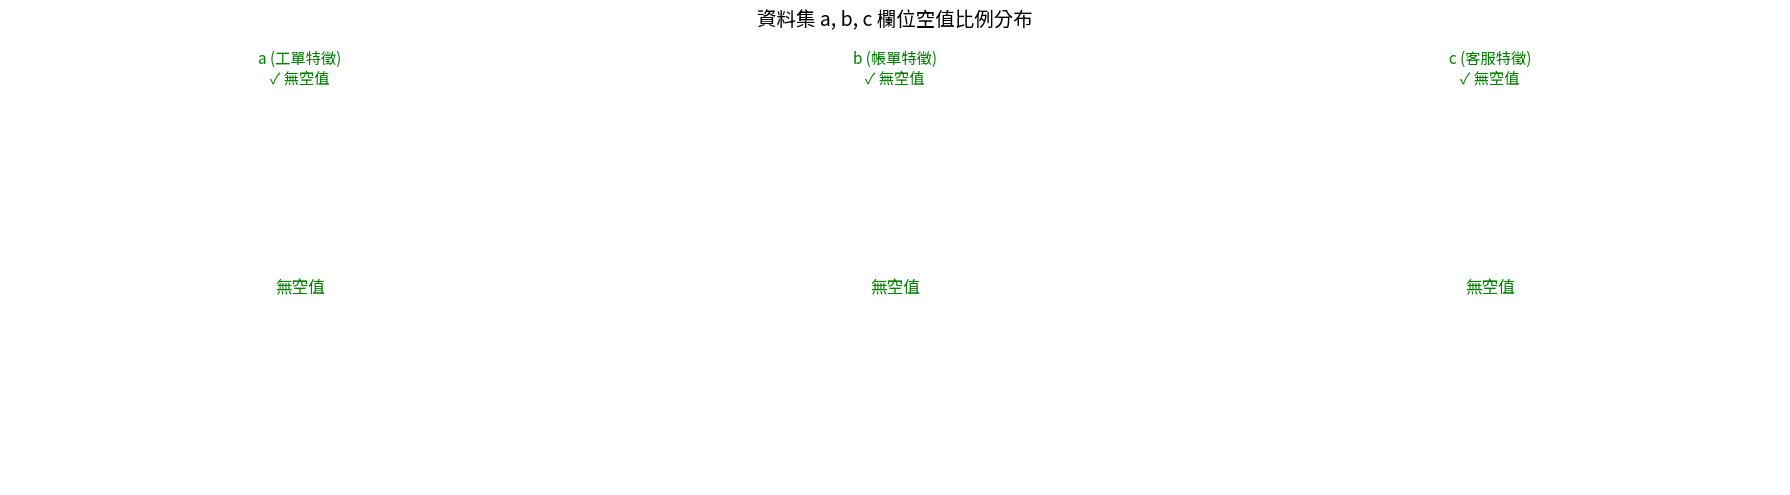

✓ 視覺化完成

█ 第6部分：空值模式與建議

【資料集 a】
  ✓ 無空值欄位：38 個
  ⚠ 輕微空值（<20%）：0 個
  ✗ 中等空值（20-80%）：0 個
  ✗ 極端空值（≥80%）：0 個

  建議：
    - ✓ 資料品質良好，無需空值處理

【資料集 b】
  ✓ 無空值欄位：16 個
  ⚠ 輕微空值（<20%）：0 個
  ✗ 中等空值（20-80%）：0 個
  ✗ 極端空值（≥80%）：0 個

  建議：
    - ✓ 資料品質良好，無需空值處理

【資料集 c】
  ✓ 無空值欄位：148 個
  ⚠ 輕微空值（<20%）：0 個
  ✗ 中等空值（20-80%）：0 個
  ✗ 極端空值（≥80%）：0 個

  建議：
    - ✓ 資料品質良好，無需空值處理

█ 第7部分：綜合報告總結

【空值狀態綜合分析】

1. 資料集 a (工單特徵)：
   - 形狀：(25361, 38)
   - 空值情況：0 個空值 (0.00%)
   - 有空值欄位：0 個

2. 資料集 b (帳單特徵)：
   - 形狀：(85118, 16)
   - 空值情況：0 個空值 (0.00%)
   - 有空值欄位：0 個

3. 資料集 c (客服特徵)：
   - 形狀：(37257, 148)
   - 空值情況：0 個空值 (0.00%)
   - 有空值欄位：0 個

【整體評估】
- 最乾淨資料集：a
- 空值最多資料集：a

✓ 分析完成


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*100)
print("【資料集 a, b, c 欄位空值狀態完整分析】")
print("="*100)

# ============================================================
# 1. 建立綜合空值統計表
# ============================================================
print("\n" + "="*100)
print("█ 第1部分：各資料集基本資訊")
print("="*100)

datasets_info = {
    'a (工單特徵)': a,
    'b (帳單特徵)': b,
    'c (客服特徵)': c
}

for name, df in datasets_info.items():
    print(f"\n【{name}】")
    print(f"  形狀：{df.shape}")
    print(f"  客戶數量：{df['CUST_NO'].nunique():,}")
    print(f"  總空值數：{df.isnull().sum().sum():,}")
    print(f"  空值比例（全表）：{df.isnull().sum().sum()/(df.shape[0]*df.shape[1])*100:.2f}%")

# ============================================================
# 2. 各資料集欄位空值詳細分析
# ============================================================
print("\n" + "="*100)
print("█ 第2部分：各資料集欄位級別空值分析")
print("="*100)

def analyze_nulls_by_dataset(df, dataset_name):
    """分析單一資料集的空值狀況"""
    print(f"\n【{dataset_name}】欄位空值詳細分析")
    print(f"{'欄位名稱':<40} {'空值數':<10} {'空值%':<10} {'資料型別':<15} {'唯一值':<10}")
    print("-" * 85)
    
    null_summary = []
    for col in df.columns:
        null_count = df[col].isnull().sum()
        null_pct = null_count / len(df) * 100
        dtype = str(df[col].dtype)
        unique = df[col].nunique()
        
        # 只顯示有空值的欄位，同時也顯示無空值欄位的摘要
        if null_count > 0 or col == df.columns[0]:  # 至少顯示第一個
            pct_str = f"{null_pct:.2f}%" if null_count > 0 else "0%"
            print(f"{col:<40} {null_count:<10} {pct_str:<10} {dtype:<15} {unique:<10}")
        
        null_summary.append({
            'Column': col,
            'Null_Count': null_count,
            'Null_Percentage': null_pct,
            'Data_Type': dtype,
            'Unique_Values': unique
        })
    
    return pd.DataFrame(null_summary)

null_stats_a = analyze_nulls_by_dataset(a, 'a (工單特徵)')
print("\n" + "-"*85)
print(f"✓ a 資料集空值欄位統計")

null_stats_b = analyze_nulls_by_dataset(b, 'b (帳單特徵)')
print("\n" + "-"*85)
print(f"✓ b 資料集空值欄位統計")

null_stats_c = analyze_nulls_by_dataset(c, 'c (客服特徵)')
print("\n" + "-"*85)
print(f"✓ c 資料集空值欄位統計")

# ============================================================
# 3. 空值嚴重程度分類
# ============================================================
print("\n" + "="*100)
print("█ 第3部分：空值嚴重程度分類")
print("="*100)

def classify_null_severity(null_pct):
    """根據空值比例分類"""
    if null_pct == 0:
        return "✓ 無空值"
    elif null_pct < 1:
        return "✓ 極少 (<1%)"
    elif null_pct < 5:
        return "⚠ 少量 (1-5%)"
    elif null_pct < 20:
        return "⚠ 中量 (5-20%)"
    elif null_pct < 50:
        return "✗ 較多 (20-50%)"
    else:
        return "✗ 極多 (≥50%)"

for name, stats in [('a', null_stats_a), ('b', null_stats_b), ('c', null_stats_c)]:
    print(f"\n【資料集 {name}】空值嚴重程度分類")
    
    severity_counts = {}
    for idx, row in stats.iterrows():
        if row['Null_Count'] > 0:
            severity = classify_null_severity(row['Null_Percentage'])
            severity_counts[severity] = severity_counts.get(severity, 0) + 1
            print(f"  {row['Column']:<40} {severity} ({row['Null_Percentage']:.2f}%)")
    
    if not severity_counts:
        print("  ✓ 所有欄位均無空值！")
    else:
        print(f"\n  小計：")
        for severity, count in sorted(severity_counts.items()):
            print(f"    {severity}: {count} 個欄位")

# ============================================================
# 4. 比較分析
# ============================================================
print("\n" + "="*100)
print("█ 第4部分：三個資料集的比較分析")
print("="*100)

comparison_data = []
for name, df, stats in [('a', a, null_stats_a), ('b', b, null_stats_b), ('c', c, null_stats_c)]:
    total_cells = df.shape[0] * df.shape[1]
    total_nulls = df.isnull().sum().sum()
    
    # 空值欄位數
    null_columns = len(stats[stats['Null_Count'] > 0])
    
    # 空值最多的欄位
    if null_columns > 0:
        max_null_col = stats[stats['Null_Count'] > 0].sort_values('Null_Count', ascending=False).iloc[0]
        max_null_info = f"{max_null_col['Column']} ({max_null_col['Null_Percentage']:.2f}%)"
    else:
        max_null_info = "無"
    
    comparison_data.append({
        '資料集': name,
        '樣本數': f"{df.shape[0]:,}",
        '欄位數': df.shape[1],
        '總空值': f"{total_nulls:,}",
        '空值%': f"{total_nulls/total_cells*100:.2f}%",
        '有空值欄位': null_columns,
        '空值最多欄位': max_null_info
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# ============================================================
# 5. 視覺化：空值分布
# ============================================================
print("\n" + "="*100)
print("█ 第5部分：空值比例視覺化")
print("="*100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('資料集 a, b, c 欄位空值比例分布', fontsize=14, fontweight='bold')

for idx, (name, stats, ax) in enumerate([
    ('a (工單特徵)', null_stats_a, axes[0]),
    ('b (帳單特徵)', null_stats_b, axes[1]),
    ('c (客服特徵)', null_stats_c, axes[2])
]):
    # 篩選有空值的欄位
    null_cols = stats[stats['Null_Count'] > 0].sort_values('Null_Percentage', ascending=False)
    
    if len(null_cols) > 0:
        # 只顯示前10個有最多空值的欄位
        top_nulls = null_cols.head(10)
        
        # 繪製橫向條形圖
        ax.barh(range(len(top_nulls)), top_nulls['Null_Percentage'].values, color='steelblue', alpha=0.7)
        ax.set_yticks(range(len(top_nulls)))
        ax.set_yticklabels([col[:35] + '...' if len(col) > 35 else col for col in top_nulls['Column'].values], fontsize=9)
        ax.set_xlabel('空值比例 (%)', fontsize=10)
        ax.set_title(f'{name}\n(共 {len(stats)} 個欄位)', fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        
        # 添加數值標籤
        for i, v in enumerate(top_nulls['Null_Percentage'].values):
            ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=8)
    else:
        ax.text(0.5, 0.5, '無空值', ha='center', va='center', fontsize=12, 
                transform=ax.transAxes, color='green', fontweight='bold')
        ax.set_title(f'{name}\n✓ 無空值', fontsize=11, fontweight='bold', color='green')
        ax.axis('off')

plt.tight_layout()
plt.show()

print("✓ 視覺化完成")

# ============================================================
# 6. 空值模式分析
# ============================================================
print("\n" + "="*100)
print("█ 第6部分：空值模式與建議")
print("="*100)

for name, df, stats in [('a', a, null_stats_a), ('b', b, null_stats_b), ('c', c, null_stats_c)]:
    print(f"\n【資料集 {name}】")
    
    # 分類空值程度
    no_null = len(stats[stats['Null_Count'] == 0])
    extreme_null = len(stats[stats['Null_Percentage'] >= 80])
    significant_null = len(stats[(stats['Null_Percentage'] >= 20) & (stats['Null_Percentage'] < 80)])
    minor_null = len(stats[(stats['Null_Count'] > 0) & (stats['Null_Percentage'] < 20)])
    
    print(f"  ✓ 無空值欄位：{no_null} 個")
    print(f"  ⚠ 輕微空值（<20%）：{minor_null} 個")
    print(f"  ✗ 中等空值（20-80%）：{significant_null} 個")
    print(f"  ✗ 極端空值（≥80%）：{extreme_null} 個")
    
    # 建議
    print(f"\n  建議：")
    if extreme_null > 0:
        print(f"    - 考慮刪除 {extreme_null} 個極端空值欄位")
    if significant_null > 0:
        print(f"    - 檢查 {significant_null} 個中等空值欄位，決定刪除或填補")
    if minor_null > 0:
        print(f"    - 使用中位數/眾數填補 {minor_null} 個輕微空值欄位")
    if no_null > 0 and extreme_null == 0 and significant_null == 0 and minor_null == 0:
        print(f"    - ✓ 資料品質良好，無需空值處理")

# ============================================================
# 7. 生成綜合報告
# ============================================================
print("\n" + "="*100)
print("█ 第7部分：綜合報告總結")
print("="*100)

print(f"""
【空值狀態綜合分析】

1. 資料集 a (工單特徵)：
   - 形狀：{a.shape}
   - 空值情況：{a.isnull().sum().sum():,} 個空值 ({a.isnull().sum().sum()/(a.shape[0]*a.shape[1])*100:.2f}%)
   - 有空值欄位：{len(null_stats_a[null_stats_a['Null_Count'] > 0])} 個

2. 資料集 b (帳單特徵)：
   - 形狀：{b.shape}
   - 空值情況：{b.isnull().sum().sum():,} 個空值 ({b.isnull().sum().sum()/(b.shape[0]*b.shape[1])*100:.2f}%)
   - 有空值欄位：{len(null_stats_b[null_stats_b['Null_Count'] > 0])} 個

3. 資料集 c (客服特徵)：
   - 形狀：{c.shape}
   - 空值情況：{c.isnull().sum().sum():,} 個空值 ({c.isnull().sum().sum()/(c.shape[0]*c.shape[1])*100:.2f}%)
   - 有空值欄位：{len(null_stats_c[null_stats_c['Null_Count'] > 0])} 個

【整體評估】
- 最乾淨資料集：{'a' if a.isnull().sum().sum()/(a.shape[0]*a.shape[1]) <= min(b.isnull().sum().sum()/(b.shape[0]*b.shape[1]), c.isnull().sum().sum()/(c.shape[0]*c.shape[1])) else 'b' if b.isnull().sum().sum()/(b.shape[0]*b.shape[1]) <= min(a.isnull().sum().sum()/(a.shape[0]*a.shape[1]), c.isnull().sum().sum()/(c.shape[0]*c.shape[1])) else 'c'}
- 空值最多資料集：{'a' if a.isnull().sum().sum()/(a.shape[0]*a.shape[1]) >= max(b.isnull().sum().sum()/(b.shape[0]*b.shape[1]), c.isnull().sum().sum()/(c.shape[0]*c.shape[1])) else 'b' if b.isnull().sum().sum()/(b.shape[0]*b.shape[1]) >= max(a.isnull().sum().sum()/(a.shape[0]*a.shape[1]), c.isnull().sum().sum()/(c.shape[0]*c.shape[1])) else 'c'}
""")

print("="*100)
print("✓ 分析完成")
print("="*100)

In [19]:
# 以b資料集為基礎進行資料合併
print("=== 以b資料集為基礎進行資料合併 ===")

# 顯示合併前各資料集的狀況
print("=== 合併前各資料集狀況 ===")
print(f"b資料集 (帳單): {b.shape}")
print(f"a資料集 (工單): {a.shape}")
print(f"c資料集 (來電): {c.shape}")

print(f"\nb資料集CUST_NO數量: {b['CUST_NO'].nunique()}")
print(f"a資料集CUST_NO數量: {a['CUST_NO'].nunique()}")
print(f"c資料集CUST_NO數量: {c['CUST_NO'].nunique()}")

# 檢查重疊的CUST_NO
b_cust_no = set(b['CUST_NO'])
a_cust_no = set(a['CUST_NO'])
c_cust_no = set(c['CUST_NO'])

a_overlap = a_cust_no & b_cust_no
c_overlap = c_cust_no & b_cust_no

print(f"\n=== CUST_NO重疊分析 ===")
print(f"a與b重疊的CUST_NO數量: {len(a_overlap)}")
print(f"c與b重疊的CUST_NO數量: {len(c_overlap)}")
print(f"a與b重疊比例: {len(a_overlap) / len(b_cust_no) * 100:.1f}%")
print(f"c與b重疊比例: {len(c_overlap) / len(b_cust_no) * 100:.1f}%")

=== 以b資料集為基礎進行資料合併 ===
=== 合併前各資料集狀況 ===
b資料集 (帳單): (85118, 16)
a資料集 (工單): (25361, 38)
c資料集 (來電): (37257, 148)

b資料集CUST_NO數量: 85118
a資料集CUST_NO數量: 25361
c資料集CUST_NO數量: 37257

=== CUST_NO重疊分析 ===
a與b重疊的CUST_NO數量: 18649
c與b重疊的CUST_NO數量: 27240
a與b重疊比例: 21.9%
c與b重疊比例: 32.0%


In [20]:
# 步驟1: 將a資料集中存在於b資料集的CUST_NO合併至b
print("\n=== 步驟1: 合併a資料集 ===")

# 篩選a資料集中存在於b資料集的客戶
a_to_merge = a[a['CUST_NO'].isin(b['CUST_NO'])].copy()
print(f"從a資料集中篩選出可合併的筆數: {len(a_to_merge)}")

# 執行左連接 (以b為主，保留b的所有記錄)
merged_step1 = b.merge(a_to_merge, on='CUST_NO', how='left')
print(f"合併a後的資料集形狀: {merged_step1.shape}")

# 檢查合併後的空值情況
a_columns = [col for col in a_to_merge.columns if col != 'CUST_NO']
print(f"來自a資料集的新欄位數: {len(a_columns)}")
print(f"新欄位中的空值統計:")
for col in a_columns[:5]:  # 顯示前5個欄位的空值情況
    null_count = merged_step1[col].isnull().sum()
    print(f"  {col}: {null_count} 個空值 ({null_count/len(merged_step1)*100:.1f}%)")
if len(a_columns) > 5:
    print(f"  ... 還有 {len(a_columns)-5} 個欄位")


=== 步驟1: 合併a資料集 ===
從a資料集中篩選出可合併的筆數: 18649
合併a後的資料集形狀: (85118, 53)
來自a資料集的新欄位數: 37
新欄位中的空值統計:
  工單原因_種類數: 66469 個空值 (78.1%)
  工單原因_重複率: 66469 個空值 (78.1%)
  工單嚴重程度_平均: 66469 個空值 (78.1%)
  工單嚴重程度_最高: 66469 個空值 (78.1%)
  工單升級趨勢: 66469 個空值 (78.1%)
  ... 還有 32 個欄位


In [21]:
# 步驟2: 將c資料集中存在於b資料集的CUST_NO合併至已合併的資料
print("\n=== 步驟2: 合併c資料集 ===")

# 篩選c資料集中存在於b資料集的客戶
c_to_merge = c[c['CUST_NO'].isin(b['CUST_NO'])].copy()
print(f"從c資料集中篩選出可合併的筆數: {len(c_to_merge)}")

# 執行左連接 (以step1結果為主)
final_merged = merged_step1.merge(c_to_merge, on='CUST_NO', how='left')
print(f"最終合併後的資料集形狀: {final_merged.shape}")

# 檢查合併後的空值情況
c_columns = [col for col in c_to_merge.columns if col != 'CUST_NO']
print(f"來自c資料集的新欄位數: {len(c_columns)}")
print(f"新欄位中的空值統計:")
for col in c_columns[:5]:  # 顯示前5個欄位的空值情況
    null_count = final_merged[col].isnull().sum()
    print(f"  {col}: {null_count} 個空值 ({null_count/len(final_merged)*100:.1f}%)")
if len(c_columns) > 5:
    print(f"  ... 還有 {len(c_columns)-5} 個欄位")


=== 步驟2: 合併c資料集 ===
從c資料集中篩選出可合併的筆數: 27240
最終合併後的資料集形狀: (85118, 200)
來自c資料集的新欄位數: 147
新欄位中的空值統計:
  TOTAL_CALLS: 57878 個空值 (68.0%)
  ACTIVE_MONTHS: 57878 個空值 (68.0%)
  ACTIVE_QUARTERS: 57878 個空值 (68.0%)
  AVG_MONTHLY_CALLS: 57878 個空值 (68.0%)
  MAX_MONTHLY_CALLS: 57878 個空值 (68.0%)
  ... 還有 142 個欄位


【final_merged 資料集空值狀況詳細分析】

█ 第1部分：final_merged 基本資訊

【基本統計】
  資料集形狀：(85118, 200)
  樣本數：85,118
  欄位數：200
  唯一客戶數：85,118
  重複客戶數：0

█ 第2部分：全面空值統計

【全表空值統計】
  總單元數：17,023,600
  空值總數：10,967,419
  空值比例：64.42%
  非空值數：6,056,181
  非空值比例：35.58%

█ 第3部分：欄位級別空值詳細分析

【欄位空值排名（Top 20）】
排名    欄位名稱                                     空值數        空值%        資料型別           
--------------------------------------------------------------------------------
17    工單原因_種類數                                 66469      78.09      float64        
18    工單原因_重複率                                 66469      78.09      float64        
19    工單嚴重程度_平均                                66469      78.09      float64        
20    工單嚴重程度_最高                                66469      78.09      float64        
21    工單升級趨勢                                   66469      78.09      float64        
22    工單原因_其他_測試正常_次數                          66469      78.09      float64        
23    工單原因_其他_測試正常_是否發生                        664

C:\Users\user\AppData\Local\Temp\ipykernel_23488\338645774.py:227: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Noto Sans TC.
  plt.tight_layout()
c:\Users\user\Documents\ExpertBook\2025\用戶資料集\TrainData\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Noto Sans TC.
  fig.canvas.print_figure(bytes_io, **kw)


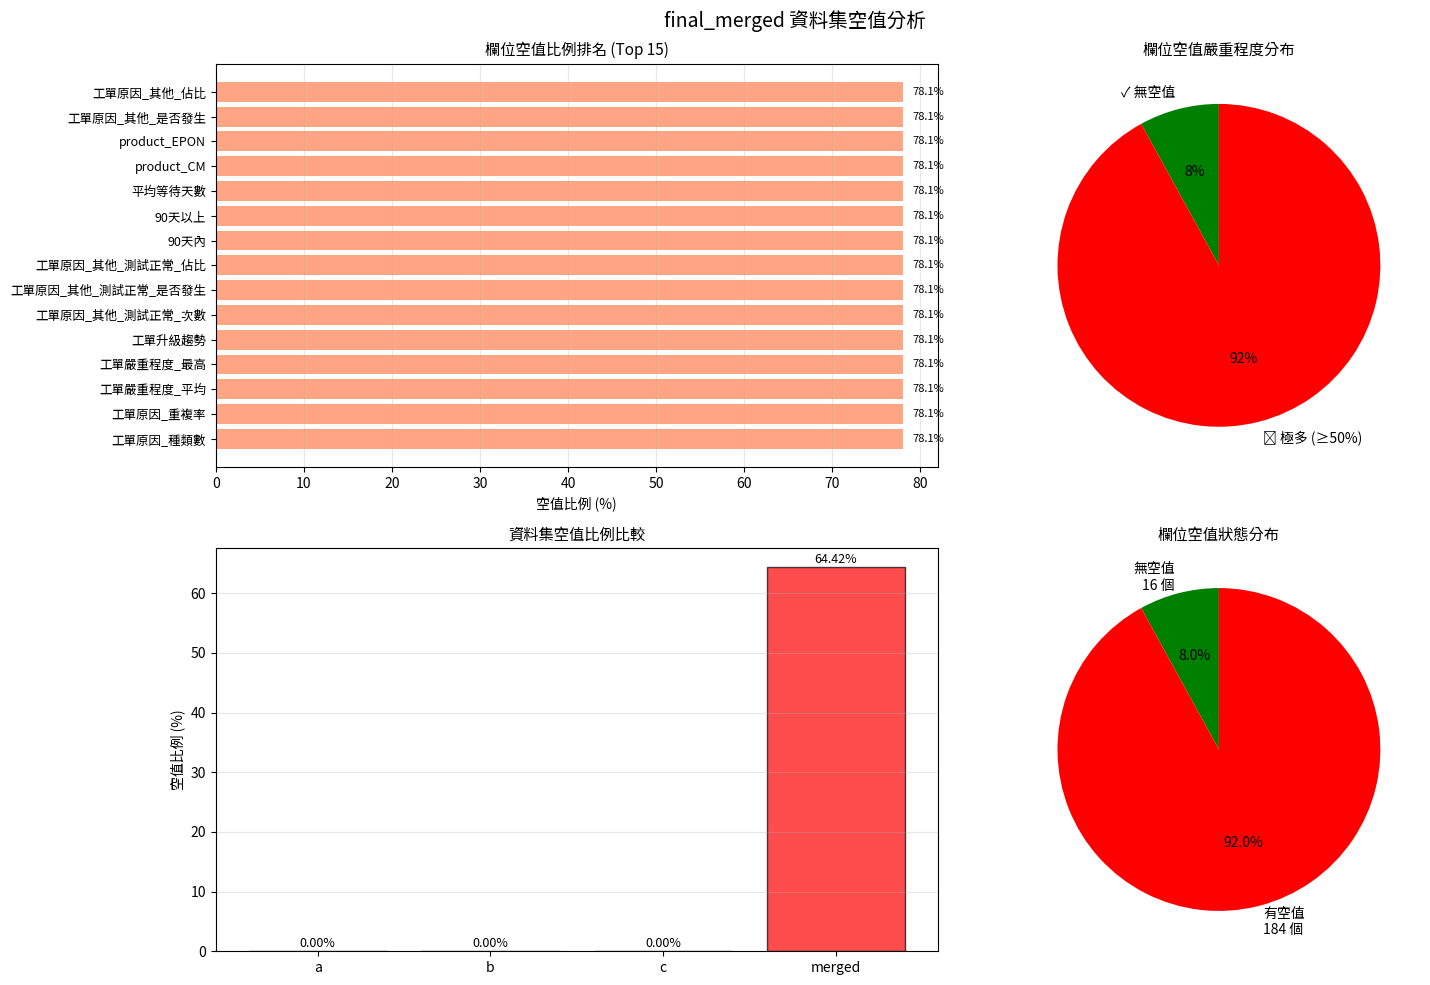

✓ 視覺化完成

█ 第7部分：有空值欄位的深度分析

【184 個有空值欄位的詳細資訊】

欄位：工單原因_種類數
  空值數量：66,469
  空值比例：78.09%
  非空值數：18,649
  資料型別：float64
  統計資訊：min=1.00, max=12.00, mean=2.01

欄位：工單原因_重複率
  空值數量：66,469
  空值比例：78.09%
  非空值數：18,649
  資料型別：float64
  統計資訊：min=0.00, max=1.00, mean=0.13

欄位：工單嚴重程度_平均
  空值數量：66,469
  空值比例：78.09%
  非空值數：18,649
  資料型別：float64
  統計資訊：min=2.00, max=2.00, mean=2.00

欄位：工單嚴重程度_最高
  空值數量：66,469
  空值比例：78.09%
  非空值數：18,649
  資料型別：float64
  統計資訊：min=2.00, max=2.00, mean=2.00

欄位：工單升級趨勢
  空值數量：66,469
  空值比例：78.09%
  非空值數：18,649
  資料型別：float64
  統計資訊：min=0.00, max=0.00, mean=0.00

欄位：工單原因_其他_測試正常_次數
  空值數量：66,469
  空值比例：78.09%
  非空值數：18,649
  資料型別：float64
  統計資訊：min=0.00, max=8.00, mean=0.38

欄位：工單原因_其他_測試正常_是否發生
  空值數量：66,469
  空值比例：78.09%
  非空值數：18,649
  資料型別：float64
  統計資訊：min=0.00, max=1.00, mean=0.29

欄位：工單原因_其他_測試正常_佔比
  空值數量：66,469
  空值比例：78.09%
  非空值數：18,649
  資料型別：float64
  統計資訊：min=0.00, max=1.00, mean=0.16

欄位：工單原因_用戶端問題_IP分享(集線)器,無線AP問題_次數
  空值數量：66,469
  空值比例：78.09%
  非空值數：18,6

In [22]:
# 合併後 final_merged 資料集空值狀況詳細分析
print("="*100)
print("【final_merged 資料集空值狀況詳細分析】")
print("="*100)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 基本資訊
# ============================================================
print("\n" + "="*100)
print("█ 第1部分：final_merged 基本資訊")
print("="*100)

print(f"\n【基本統計】")
print(f"  資料集形狀：{final_merged.shape}")
print(f"  樣本數：{final_merged.shape[0]:,}")
print(f"  欄位數：{final_merged.shape[1]}")
print(f"  唯一客戶數：{final_merged['CUST_NO'].nunique():,}")
print(f"  重複客戶數：{final_merged['CUST_NO'].duplicated().sum():,}")

# ============================================================
# 2. 全面空值統計
# ============================================================
print("\n" + "="*100)
print("█ 第2部分：全面空值統計")
print("="*100)

total_cells = final_merged.shape[0] * final_merged.shape[1]
total_nulls = final_merged.isnull().sum().sum()

print(f"\n【全表空值統計】")
print(f"  總單元數：{total_cells:,}")
print(f"  空值總數：{total_nulls:,}")
print(f"  空值比例：{total_nulls/total_cells*100:.2f}%")
print(f"  非空值數：{total_cells - total_nulls:,}")
print(f"  非空值比例：{(total_cells-total_nulls)/total_cells*100:.2f}%")

# ============================================================
# 3. 欄位級別空值分析
# ============================================================
print("\n" + "="*100)
print("█ 第3部分：欄位級別空值詳細分析")
print("="*100)

# 計算每個欄位的空值
null_by_column = final_merged.isnull().sum()
null_pct_by_column = null_by_column / len(final_merged) * 100

# 建立完整的欄位分析表
column_analysis = pd.DataFrame({
    'Column': final_merged.columns,
    'Null_Count': null_by_column.values,
    'Null_Percentage': null_pct_by_column.values,
    'Data_Type': [str(final_merged[col].dtype) for col in final_merged.columns],
    'Non_Null_Count': len(final_merged) - null_by_column.values
})

# 按空值數量排序
column_analysis_sorted = column_analysis.sort_values('Null_Count', ascending=False)

print(f"\n【欄位空值排名（Top 20）】")
print(f"{'排名':<5} {'欄位名稱':<40} {'空值數':<10} {'空值%':<10} {'資料型別':<15}")
print("-" * 80)

for idx, row in column_analysis_sorted.head(20).iterrows():
    rank = idx + 1
    col_name = row['Column'][:37] + '...' if len(row['Column']) > 37 else row['Column']
    print(f"{rank:<5} {col_name:<40} {int(row['Null_Count']):<10} {row['Null_Percentage']:<10.2f} {row['Data_Type']:<15}")

# 統計有空值的欄位
columns_with_nulls = len(column_analysis[column_analysis['Null_Count'] > 0])
columns_without_nulls = len(column_analysis[column_analysis['Null_Count'] == 0])

print(f"\n【欄位空值統計】")
print(f"  有空值的欄位：{columns_with_nulls} 個")
print(f"  無空值的欄位：{columns_without_nulls} 個")
print(f"  總欄位數：{len(column_analysis)} 個")

# ============================================================
# 4. 空值嚴重程度分類
# ============================================================
print("\n" + "="*100)
print("█ 第4部分：空值嚴重程度分類")
print("="*100)

def classify_severity(pct):
    if pct == 0:
        return "✓ 無空值"
    elif pct < 1:
        return "✓ 極少 (<1%)"
    elif pct < 5:
        return "⚠ 少量 (1-5%)"
    elif pct < 20:
        return "⚠ 中量 (5-20%)"
    elif pct < 50:
        return "✗ 較多 (20-50%)"
    else:
        return "✗ 極多 (≥50%)"

severity_categories = {
    '✓ 無空值': 0,
    '✓ 極少 (<1%)': 0,
    '⚠ 少量 (1-5%)': 0,
    '⚠ 中量 (5-20%)': 0,
    '✗ 較多 (20-50%)': 0,
    '✗ 極多 (≥50%)': 0
}

print("\n【各嚴重程度欄位分類】\n")
for idx, row in column_analysis.iterrows():
    severity = classify_severity(row['Null_Percentage'])
    severity_categories[severity] += 1

for severity, count in severity_categories.items():
    if count > 0:
        print(f"  {severity}: {count} 個欄位")
        if count <= 10 and '✗' in severity or '⚠ 中量' in severity or '⚠ 少量' in severity:
            # 顯示具體欄位
            cols_in_severity = column_analysis[column_analysis['Null_Percentage'].apply(lambda x: classify_severity(x) == severity)]
            for idx, row in cols_in_severity.iterrows():
                print(f"      - {row['Column'][:50]} ({row['Null_Percentage']:.2f}%)")

# ============================================================
# 5. 與原始 a,b,c 資料集的比較
# ============================================================
print("\n" + "="*100)
print("█ 第5部分：合併前後對比分析")
print("="*100)

comparison_data_merged = {
    '資料集': ['a (原始)', 'b (原始)', 'c (原始)', 'merged (合併後)'],
    '樣本數': [
        f"{a.shape[0]:,}",
        f"{b.shape[0]:,}",
        f"{c.shape[0]:,}",
        f"{final_merged.shape[0]:,}"
    ],
    '欄位數': [a.shape[1], b.shape[1], c.shape[1], final_merged.shape[1]],
    '空值數': [
        a.isnull().sum().sum(),
        b.isnull().sum().sum(),
        c.isnull().sum().sum(),
        total_nulls
    ],
    '空值%': [
        f"{a.isnull().sum().sum()/(a.shape[0]*a.shape[1])*100:.2f}%",
        f"{b.isnull().sum().sum()/(b.shape[0]*b.shape[1])*100:.2f}%",
        f"{c.isnull().sum().sum()/(c.shape[0]*c.shape[1])*100:.2f}%",
        f"{total_nulls/total_cells*100:.2f}%"
    ]
}

comparison_merged_df = pd.DataFrame(comparison_data_merged)
print("\n" + comparison_merged_df.to_string(index=False))

# ============================================================
# 6. 視覺化：空值分布熱力圖
# ============================================================
print("\n" + "="*100)
print("█ 第6部分：空值分布視覺化")
print("="*100)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('final_merged 資料集空值分析', fontsize=14, fontweight='bold')

# 圖1：有空值的欄位排名（前15個）
ax1 = axes[0, 0]
null_cols = column_analysis_sorted[column_analysis_sorted['Null_Count'] > 0].head(15)
if len(null_cols) > 0:
    ax1.barh(range(len(null_cols)), null_cols['Null_Percentage'].values, color='coral', alpha=0.7)
    ax1.set_yticks(range(len(null_cols)))
    ax1.set_yticklabels([col[:30] + '...' if len(col) > 30 else col for col in null_cols['Column'].values], fontsize=9)
    ax1.set_xlabel('空值比例 (%)', fontsize=10)
    ax1.set_title('欄位空值比例排名 (Top 15)', fontsize=11, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    for i, v in enumerate(null_cols['Null_Percentage'].values):
        ax1.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=8)
else:
    ax1.text(0.5, 0.5, '無空值', ha='center', va='center', fontsize=12, transform=ax1.transAxes)
    ax1.axis('off')

# 圖2：空值嚴重程度分布（圓餅圖）
ax2 = axes[0, 1]
severity_values = list(severity_categories.values())
severity_labels = list(severity_categories.keys())
severity_values_nonzero = [v for v in severity_values if v > 0]
severity_labels_nonzero = [severity_labels[i] for i, v in enumerate(severity_values) if v > 0]

if sum(severity_values_nonzero) > 0:
    colors = ['green' if '✓' in label else 'orange' if '⚠' in label else 'red' for label in severity_labels_nonzero]
    ax2.pie(severity_values_nonzero, labels=severity_labels_nonzero, autopct='%1.0f%%', 
            colors=colors, startangle=90)
    ax2.set_title('欄位空值嚴重程度分布', fontsize=11, fontweight='bold')
else:
    ax2.text(0.5, 0.5, '所有欄位無空值', ha='center', va='center', fontsize=12, 
             transform=ax2.transAxes, color='green', fontweight='bold')
    ax2.axis('off')

# 圖3：資料集比較（空值%）
ax3 = axes[1, 0]
datasets_names = ['a', 'b', 'c', 'merged']
nulls_pct = [
    a.isnull().sum().sum()/(a.shape[0]*a.shape[1])*100,
    b.isnull().sum().sum()/(b.shape[0]*b.shape[1])*100,
    c.isnull().sum().sum()/(c.shape[0]*c.shape[1])*100,
    total_nulls/total_cells*100
]
colors_bar = ['green' if x == 0 else 'orange' if x < 5 else 'red' for x in nulls_pct]
ax3.bar(datasets_names, nulls_pct, color=colors_bar, alpha=0.7, edgecolor='black')
ax3.set_ylabel('空值比例 (%)', fontsize=10)
ax3.set_title('資料集空值比例比較', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(nulls_pct):
    ax3.text(i, v + 0.2, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

# 圖4：欄位無空值 vs 有空值
ax4 = axes[1, 1]
null_status = [columns_without_nulls, columns_with_nulls]
status_labels = [f'無空值\n{columns_without_nulls} 個', f'有空值\n{columns_with_nulls} 個']
colors_pie = ['green', 'red']
ax4.pie(null_status, labels=status_labels, autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax4.set_title('欄位空值狀態分布', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ 視覺化完成")

# ============================================================
# 7. 特定欄位的深度分析（僅限有空值的欄位）
# ============================================================
print("\n" + "="*100)
print("█ 第7部分：有空值欄位的深度分析")
print("="*100)

if columns_with_nulls > 0:
    print(f"\n【{columns_with_nulls} 個有空值欄位的詳細資訊】\n")
    
    null_cols_detail = column_analysis[column_analysis['Null_Count'] > 0].sort_values('Null_Count', ascending=False)
    
    for idx, row in null_cols_detail.iterrows():
        print(f"欄位：{row['Column']}")
        print(f"  空值數量：{int(row['Null_Count']):,}")
        print(f"  空值比例：{row['Null_Percentage']:.2f}%")
        print(f"  非空值數：{int(row['Non_Null_Count']):,}")
        print(f"  資料型別：{row['Data_Type']}")
        
        # 額外資訊
        col_data = final_merged[row['Column']].dropna()
        if len(col_data) > 0:
            if pd.api.types.is_numeric_dtype(col_data):
                print(f"  統計資訊：min={col_data.min():.2f}, max={col_data.max():.2f}, mean={col_data.mean():.2f}")
            else:
                print(f"  唯一值數量：{final_merged[row['Column']].nunique()}")
        print()
else:
    print("\n✅ final_merged 資料集中所有欄位均無空值！")

# ============================================================
# 8. 建議與行動
# ============================================================
print("\n" + "="*100)
print("█ 第8部分：建議與行動")
print("="*100)

print(f"\n【空值處理建議】\n")

if total_nulls == 0:
    print("  ✅ 無需空值處理 - 資料集已完全清淨")
    print("  ✅ 可直接進行模型訓練")
    print("  ✅ 無需 fill_zero 或 auto 策略")
elif columns_with_nulls <= 5:
    print(f"  ⚠️ 僅 {columns_with_nulls} 個欄位有空值，建議：")
    for idx, row in null_cols_detail.head(5).iterrows():
        if row['Null_Percentage'] < 20:
            print(f"     - {row['Column'][:40]}: 使用中位數/眾數填補")
        elif row['Null_Percentage'] < 50:
            print(f"     - {row['Column'][:40]}: 考慮填補或刪除")
        else:
            print(f"     - {row['Column'][:40]}: 建議刪除欄位")
elif total_nulls / total_cells * 100 < 2:
    print(f"  ⚠️ 空值比例 < 2%，建議使用自動策略")
    print("     - 使用 'auto' 策略根據欄位特性自動處理")
    print("     - 或使用 'fill_zero' 一律填 0")
else:
    print(f"  ✗ 空值比例 > 2%，需要謹慎處理")
    print("     - 建議使用 'auto' 策略")
    print("     - 檢查是否有異常資料")

# ============================================================
# 9. 最終摘要
# ============================================================
print("\n" + "="*100)
print("█ 最終摘要")
print("="*100)

print(f"""
【final_merged 空值狀況摘要】

資料集形狀：{final_merged.shape}
樣本數：{final_merged.shape[0]:,}
欄位數：{final_merged.shape[1]}

空值統計：
  - 總空值：{total_nulls:,} 個
  - 空值比例：{total_nulls/total_cells*100:.2f}%
  - 有空值欄位：{columns_with_nulls} 個
  - 無空值欄位：{columns_without_nulls} 個

資料品質評級：{'⭐⭐⭐⭐⭐ (優秀)' if total_nulls == 0 else '⭐⭐⭐⭐ (良好)' if total_nulls / total_cells * 100 < 1 else '⭐⭐⭐ (中等)' if total_nulls / total_cells * 100 < 5 else '⭐⭐ (需改進)'}

建議行動：
  1. {'無需空值處理' if total_nulls == 0 else f'執行空值填補 ({columns_with_nulls} 個欄位)'}
  2. {'直接進行特徵工程' if total_nulls == 0 else '檢查特定欄位的空值模式'}
  3. {'準備進行模型訓練' if total_nulls == 0 else '應用選定的填補策略'}
""")

print("="*100)
print("✓ 分析完成")
print("="*100)

In [20]:
ds_alive = pd.read_csv("alive_20241231.csv", sep='^',encoding='big5')
ds_alive_final = pd.read_csv("alive_20250228.csv", sep='^',encoding='big5')

In [21]:
# 取得 ds_alive 中 CUST_NO 不存在 ds_alive_final 的資料
# ds_alive_missing = ds_alive[~ds_alive['CUST_NO'].astype(str).isin(ds_alive_final['CUST_NO'].astype(str))].copy()
from unittest import result
import pandas as pd

# 取差集：ds_alive 中不存在於 ds_alive_final 的客戶
ids_alive = set(ds_alive['CUST_NO'].astype(str))
ids_alive_final = set(ds_alive_final['CUST_NO'].astype(str))

not_in_final_ids = ids_alive - ids_alive_final

ds_alive_missing = ds_alive[ds_alive['CUST_NO'].astype(str).isin(not_in_final_ids)].copy()
ds_alive_missing = ds_alive_missing.reset_index(drop=True)

print("=" * 80)
print("📊 ds_alive 中不存在於 ds_alive_final 的資料")
print("=" * 80)
print(f"\nds_alive 筆數: {len(ds_alive):,}")
print(f"ds_alive_final 筆數: {len(ds_alive_final):,}")
print(f"\nds_alive 中的客戶數: {len(ids_alive):,}")
print(f"ds_alive_final 中的客戶數: {len(ids_alive_final):,}")
print(f"\n不存在於 ds_alive_final 的客戶數: {len(not_in_final_ids):,}")
print(f"不存在於 ds_alive_final 的記錄筆數: {len(ds_alive_missing):,}")
print(f"比例: {len(ds_alive_missing)/len(ds_alive)*100:.2f}%")
print("\n" + "=" * 80)

# 查看前幾筆
ds_alive_missing.head()

📊 ds_alive 中不存在於 ds_alive_final 的資料

ds_alive 筆數: 117,578
ds_alive_final 筆數: 118,762

ds_alive 中的客戶數: 117,155
ds_alive_final 中的客戶數: 118,344

不存在於 ds_alive_final 的客戶數: 1,857
不存在於 ds_alive_final 的記錄筆數: 1,857
比例: 1.58%



,REC_DATE,CCI_NO,WORK_NO,SYS_NO,V_TYPE,SPEED_NAME,CUST_NO
0,2024/12/31 上午 12:00:00,753885,(null),N,2,120000K/20000K,679815
1,2024/12/31 上午 12:00:00,760417,(null),T,1,100000K/10000K,686204
2,2024/12/31 上午 12:00:00,760428,(null),L,1,110000K/10000K,686215
3,2024/12/31 上午 12:00:00,761035,(null),T,1,55000K/5000K,686820
4,2024/12/31 上午 12:00:00,773271,(null),T,1,55000K/5000K,698980


# 狀態更新：CUST_NO 與 ds_alive 交集者，將原『停用』改為『使用中』

- 需求：在主資料集中，凡 `CUST_NO` 與 `ds_alive` 的 `CUST_NO` 有交集者，若其原來的使用狀態為「停用」，則改為「使用中」。
- 假設：
  - 主資料集變數名稱為 `df`（含欄位：`CUST_NO`、`使用狀態`）。
  - 活躍名單資料集變數名稱為 `ds_alive`（含欄位：`CUST_NO`）。
- 輸出：會顯示更新筆數與前後狀態分佈摘要。
- 可選：提供註解的存檔程式碼，視需要啟用。

In [22]:
# 將 CUST_NO 與 ds_alive 交集者（原為『停用』）更新為『使用中』
# 假設主資料集為 df，活躍名單為 ds_alive，兩者皆含欄位 CUST_NO；df 含欄位 使用狀態
df=d.copy()

# 安全檢查：確認必要欄位存在
required_df_cols = {"CUST_NO", "使用狀態"}
required_alive_cols = {"CUST_NO"}

missing_df = required_df_cols - set(df.columns)
missing_alive = required_alive_cols - set(ds_alive.columns)

if missing_df or missing_alive:
    raise ValueError(f"缺少必要欄位：df 缺 {missing_df}；ds_alive 缺 {missing_alive}")

# 交集名單（活躍者的 CUST_NO）
alive_customers = set(ds_alive["CUST_NO"].dropna().astype(str))

# 統計更新前分佈
before_dist = df["使用狀態"].value_counts(dropna=False)

# 篩選需更新的列：在活躍名單且目前狀態為停用
mask_update = df["CUST_NO"].astype(str).isin(alive_customers) & (df["使用狀態"] == "停用")
update_count = int(mask_update.sum())

# 執行更新
if update_count > 0:
    df.loc[mask_update, "使用狀態"] = "使用中"

# 統計更新後分佈
after_dist = df["使用狀態"].value_counts(dropna=False)

print("已更新筆數：", update_count)
print("更新前狀態分佈：\n", before_dist)
print("更新後狀態分佈：\n", after_dist)

# 可選：如需存檔，解除以下註解並設定路徑
# from datetime import datetime
# out_path = f"updated_dataset_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
# df.to_csv(out_path, index=False, encoding="utf-8-sig")
# print("已存檔：", out_path)

已更新筆數： 11088
更新前狀態分佈：
 使用狀態
停用     208460
使用中    106606
Name: count, dtype: int64
更新後狀態分佈：
 使用狀態
停用     197372
使用中    117694
Name: count, dtype: int64


# 狀態更新（停用）：CUST_NO 與 ds_alive_missing 交集者

- 需求：在主資料集 `df` 中，凡 `CUST_NO` 與 `ds_alive_missing` 的 `CUST_NO` 有交集者，將其「使用狀態」更新為「停用」。
- 假設：
  - 主資料集變數名稱為 `df`（含欄位：`CUST_NO`、`使用狀態`）。
  - 缺失活躍名單資料集變數名稱為 `ds_alive_missing`（含欄位：`CUST_NO`）。
- 輸出：顯示更新筆數與前後狀態分佈摘要。
- 可選：提供註解的存檔程式碼，視需要啟用。

In [23]:
# 將 CUST_NO 與 ds_alive_missing 交集者，更新使用狀態為『停用』
# 假設主資料集為 df（含 CUST_NO、使用狀態），名單為 ds_alive_missing（含 CUST_NO）

# 安全檢查：確認必要欄位存在
required_df_cols = {"CUST_NO", "使用狀態"}
required_missing_cols = {"CUST_NO"}

missing_df = required_df_cols - set(df.columns)
missing_missing = required_missing_cols - set(ds_alive_missing.columns)

if missing_df or missing_missing:
    raise ValueError(f"缺少必要欄位：df 缺 {missing_df}；ds_alive_missing 缺 {missing_missing}")

# 名單集合
off_customers = set(ds_alive_missing["CUST_NO"].dropna().astype(str))

# 統計更新前分佈
before_dist = df["使用狀態"].value_counts(dropna=False)

# 篩選需更新的列：在缺失活躍名單者
mask_update = df["CUST_NO"].astype(str).isin(off_customers)
update_count = int(mask_update.sum())

# 執行更新
if update_count > 0:
    df.loc[mask_update, "使用狀態"] = "停用"

# 統計更新後分佈
after_dist = df["使用狀態"].value_counts(dropna=False)

print("已更新筆數（停用）：", update_count)
print("更新前狀態分佈：\n", before_dist)
print("更新後狀態分佈：\n", after_dist)

# 可選：如需存檔，解除以下註解並設定路徑
# from datetime import datetime
# out_path = f"updated_dataset_set_off_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
# df.to_csv(out_path, index=False, encoding="utf-8-sig")
# print("已存檔：", out_path)

已更新筆數（停用）： 1781
更新前狀態分佈：
 使用狀態
停用     197372
使用中    117694
Name: count, dtype: int64
更新後狀態分佈：
 使用狀態
停用     199153
使用中    115913
Name: count, dtype: int64


In [24]:
d=df.copy()

In [25]:
# 依合併資料集中的CUST_NO 合併 d 資料集的'使用狀態'和'alive_month'欄位
print("=== 依CUST_NO合併d資料集的使用狀態和alive_month欄位 ===")

# 檢查合併前的狀況
print(f"final_merged資料集形狀: {final_merged.shape}")
print(f"final_merged客戶數: {final_merged['CUST_NO'].nunique()}")
print(f"d資料集形狀: {d.shape}")
print(f"d資料集客戶數: {d['CUST_NO'].nunique()}")

# 檢查CUST_NO重疊情況
final_cust_set = set(final_merged['CUST_NO'])
d_cust_set = set(d['CUST_NO'])
overlap_customers = final_cust_set & d_cust_set

print(f"\n=== CUST_NO重疊分析 ===")
print(f"final_merged與d重疊的客戶數: {len(overlap_customers)}")
print(f"重疊比例(相對於final_merged): {len(overlap_customers) / len(final_cust_set) * 100:.1f}%")
print(f"重疊比例(相對於d): {len(overlap_customers) / len(d_cust_set) * 100:.1f}%")

# 準備d資料集的狀態和alive_month對應資料
print(f"\n=== 準備d資料集的狀態和alive_month對應 ===")

# 檢查d資料集中需要合併的欄位
merge_cols = ['CUST_NO', '使用狀態']
if 'alive_month' in d.columns:
    merge_cols.append('alive_month')
    print(f"✅ d資料集包含 alive_month 欄位")
else:
    print(f"⚠️ d資料集不包含 alive_month 欄位")

print(f"準備合併的欄位: {merge_cols}")

# 檢查d資料集中是否有重複的CUST_NO
d_duplicates = d['CUST_NO'].duplicated().sum()
print(f"d資料集中重複CUST_NO數量: {d_duplicates}")

if d_duplicates > 0:
    print("處理d資料集中的重複CUST_NO...")
    
    # 對於重複的CUST_NO，對不同欄位採用不同策略
    agg_dict = {
        '使用狀態': lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]  # 取最常見值
    }
    
    if 'alive_month' in d.columns:
        agg_dict['alive_month'] = 'max'  # 取最大值（假設最新的記錄有最大的存活月數）
    
    d_mapping = d.groupby('CUST_NO').agg(agg_dict).reset_index()
else:
    print("d資料集中無重複CUST_NO，直接使用...")
    d_mapping = d[merge_cols].copy()

print(f"d資料集對應記錄數: {len(d_mapping)}")
print(f"d資料集使用狀態分布:")
print(d_mapping['使用狀態'].value_counts())

if 'alive_month' in d_mapping.columns:
    print(f"\nd資料集alive_month統計:")
    print(f"  最小值: {d_mapping['alive_month'].min()}")
    print(f"  最大值: {d_mapping['alive_month'].max()}")
    print(f"  平均值: {d_mapping['alive_month'].mean():.2f}")
    print(f"  空值數: {d_mapping['alive_month'].isnull().sum()}")

# 檢查final_merged中是否已有相關欄位
existing_cols = []
if '使用狀態' in final_merged.columns:
    existing_cols.append('使用狀態')
if 'alive_month' in final_merged.columns:
    existing_cols.append('alive_month')

if existing_cols:
    print(f"\n⚠️ final_merged中已存在欄位: {existing_cols}")
    
    for col in existing_cols:
        existing_nulls = final_merged[col].isnull().sum()
        print(f"{col} 現有空值數量: {existing_nulls}")
        if existing_nulls > 0:
            print(f"  將用d資料集填補 {col} 的空值")
        else:
            print(f"  將用d資料集覆蓋現有的 {col}")
    
    merge_strategy = 'update_existing'
else:
    print(f"\nfinal_merged中不存在目標欄位，將新增: {[col for col in merge_cols if col != 'CUST_NO']}")
    merge_strategy = 'add_new'

# 執行合併
print(f"\n=== 執行合併操作 ===")

if merge_strategy == 'update_existing':
    # 處理已存在的欄位
    for col in ['使用狀態', 'alive_month']:
        if col in d_mapping.columns:
            if col in final_merged.columns:
                # 建立對應字典
                col_dict = d_mapping.set_index('CUST_NO')[col].to_dict()
                
                # 填補空值或覆蓋全部
                null_mask = final_merged[col].isnull() if col in final_merged.columns else pd.Series([True] * len(final_merged))
                
                filled_count = 0
                for cust_no in final_merged['CUST_NO']:
                    if cust_no in col_dict:
                        if col in final_merged.columns:
                            # 只更新空值或全部覆蓋（依需求調整）
                            mask = (final_merged['CUST_NO'] == cust_no) & (final_merged[col].isnull())
                            if mask.any():
                                final_merged.loc[mask, col] = col_dict[cust_no]
                                filled_count += 1
                        else:
                            # 新增欄位
                            final_merged.loc[final_merged['CUST_NO'] == cust_no, col] = col_dict[cust_no]
                            filled_count += 1
                
                print(f"成功更新 {filled_count} 個客戶的 {col}")
            else:
                # 欄位不存在，直接合併
                temp_merge = final_merged.merge(
                    d_mapping[['CUST_NO', col]], 
                    on='CUST_NO', 
                    how='left'
                )
                final_merged[col] = temp_merge[col]
                print(f"成功新增 {col} 欄位")

else:  # add_new
    # 使用left join新增所有欄位
    final_merged = final_merged.merge(
        d_mapping, 
        on='CUST_NO', 
        how='left'
    )
    
    print(f"已新增欄位: {[col for col in merge_cols if col != 'CUST_NO']}")

# 檢查合併結果
print(f"\n=== 合併結果檢查 ===")
print(f"合併後final_merged形狀: {final_merged.shape}")

# 檢查使用狀態
if '使用狀態' in final_merged.columns:
    status_nulls = final_merged['使用狀態'].isnull().sum()
    print(f"\n使用狀態合併結果:")
    print(f"  空值數量: {status_nulls}")
    print(f"  空值比例: {status_nulls / len(final_merged) * 100:.2f}%")
    print(f"  分布情況:")
    print(final_merged['使用狀態'].value_counts(dropna=False))

# 檢查alive_month
if 'alive_month' in final_merged.columns:
    alive_nulls = final_merged['alive_month'].isnull().sum()
    print(f"\nalive_month合併結果:")
    print(f"  空值數量: {alive_nulls}")
    print(f"  空值比例: {alive_nulls / len(final_merged) * 100:.2f}%")
    print(f"  統計資訊:")
    print(f"    最小值: {final_merged['alive_month'].min()}")
    print(f"    最大值: {final_merged['alive_month'].max()}")
    print(f"    平均值: {final_merged['alive_month'].mean():.2f}")
    print(f"    中位數: {final_merged['alive_month'].median():.2f}")

# 統計成功匹配的客戶數
matched_customers_status = final_merged[final_merged['使用狀態'].notna()]['CUST_NO'].nunique() if '使用狀態' in final_merged.columns else 0
matched_customers_alive = final_merged[final_merged['alive_month'].notna()]['CUST_NO'].nunique() if 'alive_month' in final_merged.columns else 0
total_customers = final_merged['CUST_NO'].nunique()

print(f"\n=== 匹配成功率統計 ===")
print(f"總客戶數: {total_customers}")
print(f"使用狀態匹配成功的客戶數: {matched_customers_status} ({matched_customers_status / total_customers * 100:.1f}%)")
if 'alive_month' in final_merged.columns:
    print(f"alive_month匹配成功的客戶數: {matched_customers_alive} ({matched_customers_alive / total_customers * 100:.1f}%)")

# 分析未匹配的原因
if '使用狀態' in final_merged.columns:
    unmatched_status = final_merged[final_merged['使用狀態'].isnull()]['CUST_NO'].nunique()
    if unmatched_status > 0:
        print(f"\n未匹配使用狀態的客戶數: {unmatched_status}")
        unmatched_cust_set = set(final_merged[final_merged['使用狀態'].isnull()]['CUST_NO'])
        not_in_d = unmatched_cust_set - d_cust_set
        print(f"其中不在d資料集中的客戶數: {len(not_in_d)}")

if 'alive_month' in final_merged.columns:
    unmatched_alive = final_merged[final_merged['alive_month'].isnull()]['CUST_NO'].nunique()
    if unmatched_alive > 0:
        print(f"未匹配alive_month的客戶數: {unmatched_alive}")

print(f"\n✅ 使用狀態和alive_month欄位合併完成")

# 顯示最終資料集資訊
print(f"\n=== 最終資料集資訊 ===")
print(f"最終資料集形狀: {final_merged.shape}")
print(f"總客戶數: {final_merged['CUST_NO'].nunique()}")
print(f"總欄位數: {len(final_merged.columns)}")

# 顯示新增的欄位
new_cols = []
if '使用狀態' in final_merged.columns:
    new_cols.append('使用狀態')
if 'alive_month' in final_merged.columns:
    new_cols.append('alive_month')

if new_cols:
    print(f"成功合併的欄位: {new_cols}")
    
    # 顯示樣本資料
    print(f"\n=== 合併結果樣本 ===")
    sample_cols = ['CUST_NO'] + new_cols
    sample_data = final_merged[sample_cols].head(10)
    print(sample_data.to_string(index=False))

=== 依CUST_NO合併d資料集的使用狀態和alive_month欄位 ===
final_merged資料集形狀: (85118, 200)
final_merged客戶數: 85118
d資料集形狀: (315066, 10)
d資料集客戶數: 315066

=== CUST_NO重疊分析 ===
final_merged與d重疊的客戶數: 85118
重疊比例(相對於final_merged): 100.0%
重疊比例(相對於d): 27.0%

=== 準備d資料集的狀態和alive_month對應 ===
⚠️ d資料集不包含 alive_month 欄位
準備合併的欄位: ['CUST_NO', '使用狀態']
d資料集中重複CUST_NO數量: 0
d資料集中無重複CUST_NO，直接使用...
d資料集對應記錄數: 315066
d資料集使用狀態分布:
使用狀態
停用     199153
使用中    115913
Name: count, dtype: int64

final_merged中不存在目標欄位，將新增: ['使用狀態']

=== 執行合併操作 ===
已新增欄位: ['使用狀態']

=== 合併結果檢查 ===
合併後final_merged形狀: (85118, 201)

使用狀態合併結果:
  空值數量: 0
  空值比例: 0.00%
  分布情況:
使用狀態
使用中    79794
停用      5324
Name: count, dtype: int64

=== 匹配成功率統計 ===
總客戶數: 85118
使用狀態匹配成功的客戶數: 85118 (100.0%)

✅ 使用狀態和alive_month欄位合併完成

=== 最終資料集資訊 ===
最終資料集形狀: (85118, 201)
總客戶數: 85118
總欄位數: 201
成功合併的欄位: ['使用狀態']

=== 合併結果樣本 ===
 CUST_NO 使用狀態
 1107235  使用中
  950469  使用中
  734283  使用中
 1027561  使用中
 1028286  使用中
  942658  使用中
  959227   停用
 1028088  使用中
  293366  使用中
  951758  使用中

In [26]:
# 檢查 final_merged 中不同使用狀態的分佈情形
print("=== final_merged 中使用狀態分佈情形 ===")

# 檢查使用狀態欄位是否存在
if '使用狀態' in final_merged.columns:
    print(f"final_merged 資料集形狀: {final_merged.shape}")
    print(f"總記錄數: {len(final_merged):,}")
    
    # 基本分佈統計
    print(f"\n=== 使用狀態分佈 ===")
    status_counts = final_merged['使用狀態'].value_counts(dropna=False)
    print("絕對數量:")
    for status, count in status_counts.items():
        print(f"  {status}: {count:,} 筆")
    
    # 百分比分佈
    print(f"\n百分比分佈:")
    status_percent = final_merged['使用狀態'].value_counts(normalize=True, dropna=False) * 100
    for status, percent in status_percent.items():
        print(f"  {status}: {percent:.2f}%")
    
    # 檢查空值情況
    null_count = final_merged['使用狀態'].isnull().sum()
    print(f"\n=== 空值統計 ===")
    print(f"空值數量: {null_count:,}")
    print(f"空值比例: {null_count / len(final_merged) * 100:.2f}%")
    
    # 非空值統計
    non_null_count = final_merged['使用狀態'].notna().sum()
    print(f"非空值數量: {non_null_count:,}")
    print(f"非空值比例: {non_null_count / len(final_merged) * 100:.2f}%")
    
    # 詳細分析
    print(f"\n=== 詳細分析 ===")
    unique_statuses = final_merged['使用狀態'].unique()
    print(f"唯一狀態數量: {len(unique_statuses)}")
    print(f"所有狀態類型: {list(unique_statuses)}")
    
    # 如果有使用狀態_數值欄位，也一起顯示
    if '使用狀態_數值' in final_merged.columns:
        print(f"\n=== 使用狀態_數值分佈 ===")
        numeric_counts = final_merged['使用狀態_數值'].value_counts(dropna=False).sort_index()
        for value, count in numeric_counts.items():
            print(f"  {value}: {count:,} 筆 ({count/len(final_merged)*100:.2f}%)")
        
        # 交叉驗證
        print(f"\n=== 使用狀態與數值對應驗證 ===")
        cross_tab = pd.crosstab(final_merged['使用狀態'], final_merged['使用狀態_數值'], 
                               margins=True, dropna=False)
        print(cross_tab)
    
else:
    print("❌ final_merged 中找不到 '使用狀態' 欄位")
    print(f"available columns: {list(final_merged.columns)}")
    
    # 檢查是否有類似的欄位
    status_related_cols = [col for col in final_merged.columns if '狀態' in col or 'status' in col.lower()]
    if status_related_cols:
        print(f"找到相關欄位: {status_related_cols}")
        for col in status_related_cols:
            print(f"\n{col} 的分佈:")
            print(final_merged[col].value_counts(dropna=False))


=== final_merged 中使用狀態分佈情形 ===
final_merged 資料集形狀: (85118, 201)
總記錄數: 85,118

=== 使用狀態分佈 ===
絕對數量:
  使用中: 79,794 筆
  停用: 5,324 筆

百分比分佈:
  使用中: 93.75%
  停用: 6.25%

=== 空值統計 ===
空值數量: 0
空值比例: 0.00%
非空值數量: 85,118
非空值比例: 100.00%

=== 詳細分析 ===
唯一狀態數量: 2
所有狀態類型: ['使用中', '停用']


In [27]:
# 針對 final_merged 中的使用狀態進行 label encoding
print("=== 針對使用狀態進行 label encoding ===")

# 檢查使用狀態欄位是否存在
if '使用狀態' in final_merged.columns:
    # 顯示編碼前的使用狀態分布
    print("編碼前使用狀態分布:")
    print(final_merged['使用狀態'].value_counts(dropna=False))
    
    # 建立 label encoding 映射
    label_mapping = {'使用中': 0, '停用': 1}
    print(f"\nLabel encoding 映射規則:")
    for status, code in label_mapping.items():
        print(f"  {status} → {code}")
    
    # 執行 label encoding
    final_merged['使用狀態_編碼'] = final_merged['使用狀態'].map(label_mapping)
    
    print(f"\n=== 編碼結果 ===")
    
    # 顯示編碼後的分布
    print(f"使用狀態_編碼分布:")
    encoded_counts = final_merged['使用狀態_編碼'].value_counts().sort_index()
    for code, count in encoded_counts.items():
        print(f"  {code}: {count:,} 筆 ({count/len(final_merged)*100:.2f}%)")
    
    # 交叉驗證編碼結果
    print(f"\n=== 編碼驗證 ===")
    cross_tab = pd.crosstab(final_merged['使用狀態'], final_merged['使用狀態_編碼'], 
                           margins=True, dropna=False)
    print("使用狀態 vs 使用狀態_編碼 交叉表:")
    print(cross_tab)
    
    # 檢查是否有未能編碼的值
    null_encoded = final_merged['使用狀態_編碼'].isnull().sum()
    if null_encoded > 0:
        print(f"\n⚠️ 有 {null_encoded} 筆記錄無法編碼")
        # 顯示無法編碼的狀態值
        unmapped_values = final_merged[final_merged['使用狀態_編碼'].isnull()]['使用狀態'].unique()
        print(f"無法編碼的狀態值: {list(unmapped_values)}")
    else:
        print(f"\n✅ 所有狀態值都成功編碼")
    
    # 統計摘要
    print(f"\n=== 編碼摘要 ===")
    using_count = (final_merged['使用狀態_編碼'] == 0).sum()
    stopped_count = (final_merged['使用狀態_編碼'] == 1).sum()
    
    print(f"使用中 (0): {using_count:,} 筆 ({using_count/len(final_merged)*100:.1f}%)")
    print(f"停用 (1): {stopped_count:,} 筆 ({stopped_count/len(final_merged)*100:.1f}%)")
    
    print(f"\n✅ 使用狀態 label encoding 完成")
    print(f"新增欄位: 使用狀態_編碼")
    print(f"資料集形狀: {final_merged.shape}")
    
else:
    print("❌ final_merged 中找不到 '使用狀態' 欄位")
    print(f"可用欄位: {list(final_merged.columns)}")
    
    # 檢查是否有類似的狀態欄位
    status_related_cols = [col for col in final_merged.columns if '狀態' in col or 'status' in col.lower()]
    if status_related_cols:
        print(f"找到相關欄位: {status_related_cols}")
        for col in status_related_cols:
            print(f"\n{col} 的分佈:")
            print(final_merged[col].value_counts(dropna=False))

=== 針對使用狀態進行 label encoding ===
編碼前使用狀態分布:
使用狀態
使用中    79794
停用      5324
Name: count, dtype: int64

Label encoding 映射規則:
  使用中 → 0
  停用 → 1

=== 編碼結果 ===
使用狀態_編碼分布:
  0: 79,794 筆 (93.75%)
  1: 5,324 筆 (6.25%)

=== 編碼驗證 ===
使用狀態 vs 使用狀態_編碼 交叉表:
使用狀態_編碼      0     1    All
使用狀態                       
使用中      79794     0  79794
停用           0  5324   5324
All      79794  5324  85118

✅ 所有狀態值都成功編碼

=== 編碼摘要 ===
使用中 (0): 79,794 筆 (93.7%)
停用 (1): 5,324 筆 (6.3%)

✅ 使用狀態 label encoding 完成
新增欄位: 使用狀態_編碼
資料集形狀: (85118, 202)


In [28]:
def comprehensive_null_handling_for_sfss(final_merged, target_col='使用狀態_編碼', fill_strategy='auto'):
    """
    針對 final_merged 在 SFSS 前進行全面的空值處理
    
    Parameters:
    -----------
    final_merged : pd.DataFrame
        要處理的資料集
    target_col : str
        目標變數欄位名稱
    fill_strategy : str, default='auto'
        空值填補策略：
        - 'auto': 自動根據資料屬性選擇填補方法
        - 'fill_zero': 不論資料屬性，一律填0
        
    Returns:
    --------
    pd.DataFrame: 處理後的資料集
    dict: 處理報告
    """
    
    print(f"=== SFSS 前全面空值處理策略 (策略: {fill_strategy}) ===")
    
    # 建立處理報告
    processing_report = {
        'original_shape': final_merged.shape,
        'fill_strategy': fill_strategy,
        'column_analysis': {},
        'processing_actions': [],
        'final_shape': None,
        'removal_summary': {}
    }
    
    # 步驟1: 基本資料概覽
    print(f"原始資料集形狀: {final_merged.shape}")
    print(f"目標變數: {target_col}")
    print(f"填補策略: {fill_strategy}")
    
    # 複製資料避免修改原始資料
    df_processed = final_merged.copy()
    
    # 步驟2: 目標變數處理（最高優先級）
    print(f"\n=== 步驟1: 目標變數處理 ===")
    
    if target_col not in df_processed.columns:
        print(f"❌ 目標變數 '{target_col}' 不存在！")
        return final_merged, processing_report
    
    target_nulls_before = df_processed[target_col].isnull().sum()
    print(f"目標變數空值數量: {target_nulls_before}")
    
    if target_nulls_before > 0:
        print(f"⚠️ 刪除 {target_nulls_before} 筆目標變數為空值的記錄")
        df_processed = df_processed.dropna(subset=[target_col])
        processing_report['processing_actions'].append(f"刪除目標變數空值: {target_nulls_before} 筆")
    
    print(f"目標變數處理後資料集形狀: {df_processed.shape}")
    
    # 步驟3: 識別特徵欄位
    exclude_cols = ['CUST_NO', '使用狀態', target_col]
    feature_cols = [col for col in df_processed.columns if col not in exclude_cols]
    
    print(f"\n=== 步驟2: 特徵欄位識別 ===")
    print(f"需要處理的特徵欄位數量: {len(feature_cols)}")
    
    # 根據填補策略進行處理
    if fill_strategy == 'fill_zero':
        # ==========================================
        # 一律填0策略
        # ==========================================
        print(f"\n=== 步驟3: 執行一律填0策略 ===")
        
        total_nulls_before = 0
        filled_columns = []
        
        for col in feature_cols:
            null_count = df_processed[col].isnull().sum()
            total_nulls_before += null_count
            
            if null_count > 0:
                # 記錄欄位資訊
                col_info = {
                    'dtype': str(df_processed[col].dtype),
                    'null_count': null_count,
                    'null_percentage': null_count / len(df_processed) * 100,
                    'unique_count': df_processed[col].nunique(),
                    'fill_method': 'fill_zero'
                }
                processing_report['column_analysis'][col] = col_info
                
                # 填0
                df_processed[col] = df_processed[col].fillna(0)
                filled_columns.append(col)
                
                print(f"  ✅ {col}: 填充了 {null_count} 個空值 (空值率: {null_count/len(df_processed)*100:.1f}%)")
        
        print(f"\n一律填0策略執行結果:")
        print(f"  處理的欄位數: {len(filled_columns)}")
        print(f"  填充的空值總數: {total_nulls_before}")
        
        processing_report['processing_actions'].append(f"一律填0: {len(filled_columns)} 個欄位, {total_nulls_before} 個空值")
        
        # 確保所有特徵都是數值型
        print(f"\n=== 步驟4: 數值化處理 ===")
        for col in feature_cols:
            if not pd.api.types.is_numeric_dtype(df_processed[col]):
                original_dtype = df_processed[col].dtype
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                
                # 如果轉換後產生新的空值，用0填充
                new_nulls = df_processed[col].isnull().sum()
                if new_nulls > 0:
                    df_processed[col] = df_processed[col].fillna(0)
                    print(f"  - {col}: {original_dtype} → 數值型，填充了 {new_nulls} 個轉換失敗的值")
        
    else:
        # ==========================================
        # 自動策略（原有邏輯）
        # ==========================================
        print(f"\n=== 步驟3: 自動策略 - 欄位分析和處理策略制定 ===")
        
        # 分析每個欄位的空值情況和資料特性
        column_stats = {}
        
        for col in feature_cols:
            col_data = df_processed[col]
            
            stats = {
                'dtype': str(col_data.dtype),
                'null_count': col_data.isnull().sum(),
                'null_percentage': col_data.isnull().mean() * 100,
                'unique_count': col_data.nunique(),
                'zero_count': (col_data == 0).sum() if pd.api.types.is_numeric_dtype(col_data) else 0,
                'total_count': len(col_data)
            }
            
            # 判斷欄位特性
            if pd.api.types.is_numeric_dtype(col_data):
                stats['is_numeric'] = True
                stats['min_val'] = col_data.min() if not col_data.isnull().all() else None
                stats['max_val'] = col_data.max() if not col_data.isnull().all() else None
                stats['mean_val'] = col_data.mean() if not col_data.isnull().all() else None
                stats['std_val'] = col_data.std() if not col_data.isnull().all() else None
            else:
                stats['is_numeric'] = False
                stats['sample_values'] = list(col_data.dropna().unique()[:3])
            
            column_stats[col] = stats
            processing_report['column_analysis'][col] = stats
        
        # 制定處理策略
        print(f"\n=== 步驟4: 制定處理策略 ===")
        
        columns_to_drop = []
        columns_fill_zero = []
        columns_fill_median = []
        columns_fill_mode = []
        columns_special_handling = []
        
        for col, stats in column_stats.items():
            null_pct = stats['null_percentage']
            
            print(f"\n分析欄位: {col}")
            print(f"  空值比例: {null_pct:.2f}%")
            print(f"  唯一值數量: {stats['unique_count']}")
            print(f"  資料型別: {stats['dtype']}")
            
            # 決策邏輯
            if null_pct >= 80:
                columns_to_drop.append(col)
                print(f"  📌 策略: 刪除欄位 (空值比例過高: {null_pct:.1f}%)")
                
            elif stats['unique_count'] <= 1:
                columns_to_drop.append(col)
                print(f"  📌 策略: 刪除欄位 (無變異性)")
                
            elif not stats['is_numeric']:
                if null_pct <= 50:
                    columns_fill_mode.append(col)
                    print(f"  📌 策略: 填充眾數 (非數值型)")
                else:
                    columns_to_drop.append(col)
                    print(f"  📌 策略: 刪除欄位 (非數值型且空值過多)")
                    
            else:
                if null_pct == 0:
                    print(f"  📌 策略: 保持不變 (無空值)")
                    continue
                    
                zero_pct = stats['zero_count'] / stats['total_count'] * 100 if stats['total_count'] > 0 else 0
                
                if zero_pct > 50 or 'count' in col.lower() or 'num' in col.lower() or 'total' in col.lower():
                    columns_fill_zero.append(col)
                    print(f"  📌 策略: 填充0 (計數型特徵)")
                elif null_pct <= 30:
                    columns_fill_median.append(col)
                    print(f"  📌 策略: 填充中位數 (數值型)")
                elif null_pct <= 50:
                    columns_special_handling.append(col)
                    print(f"  📌 策略: 特殊處理 (空值較多但可保留)")
                else:
                    columns_to_drop.append(col)
                    print(f"  📌 策略: 刪除欄位 (空值過多: {null_pct:.1f}%)")
        
        # 執行自動策略的各種處理方法
        print(f"\n=== 步驟5: 執行自動處理策略 ===")
        
        # 刪除欄位
        if columns_to_drop:
            print(f"\n🗑️ 刪除 {len(columns_to_drop)} 個欄位:")
            for col in columns_to_drop:
                print(f"  - {col} (空值: {column_stats[col]['null_percentage']:.1f}%)")
            
            df_processed = df_processed.drop(columns=columns_to_drop)
            processing_report['processing_actions'].append(f"刪除欄位: {len(columns_to_drop)} 個")
            processing_report['removal_summary']['dropped_columns'] = columns_to_drop
        
        # 填充0
        if columns_fill_zero:
            print(f"\n🔢 填充0: {len(columns_fill_zero)} 個欄位")
            for col in columns_fill_zero:
                null_count_before = df_processed[col].isnull().sum()
                df_processed[col] = df_processed[col].fillna(0)
                print(f"  - {col}: 填充了 {null_count_before} 個空值")
            
            processing_report['processing_actions'].append(f"填充0: {len(columns_fill_zero)} 個欄位")
        
        # 填充中位數
        if columns_fill_median:
            print(f"\n📊 填充中位數: {len(columns_fill_median)} 個欄位")
            for col in columns_fill_median:
                null_count_before = df_processed[col].isnull().sum()
                median_val = df_processed[col].median()
                df_processed[col] = df_processed[col].fillna(median_val)
                print(f"  - {col}: 填充了 {null_count_before} 個空值 (中位數: {median_val:.2f})")
            
            processing_report['processing_actions'].append(f"填充中位數: {len(columns_fill_median)} 個欄位")
        
        # 填充眾數
        if columns_fill_mode:
            print(f"\n📈 填充眾數: {len(columns_fill_mode)} 個欄位")
            for col in columns_fill_mode:
                null_count_before = df_processed[col].isnull().sum()
                mode_val = df_processed[col].mode()
                if len(mode_val) > 0:
                    df_processed[col] = df_processed[col].fillna(mode_val.iloc[0])
                    print(f"  - {col}: 填充了 {null_count_before} 個空值 (眾數: {mode_val.iloc[0]})")
                else:
                    df_processed = df_processed.drop(columns=[col])
                    print(f"  - {col}: 無法確定眾數，已刪除欄位")
            
            processing_report['processing_actions'].append(f"填充眾數: {len(columns_fill_mode)} 個欄位")
        
        # 特殊處理
        if columns_special_handling:
            print(f"\n🔧 特殊處理: {len(columns_special_handling)} 個欄位")
            for col in columns_special_handling:
                null_count_before = df_processed[col].isnull().sum()
                
                if 'month' in col.lower() or 'day' in col.lower() or 'time' in col.lower():
                    df_processed[col] = df_processed[col].fillna(0)
                    print(f"  - {col}: 時間特徵填充0 ({null_count_before} 個空值)")
                elif 'ratio' in col.lower() or 'rate' in col.lower() or '%' in col:
                    median_val = df_processed[col].median()
                    df_processed[col] = df_processed[col].fillna(median_val)
                    print(f"  - {col}: 比例特徵填充中位數 ({null_count_before} 個空值)")
                else:
                    median_val = df_processed[col].median()
                    df_processed[col] = df_processed[col].fillna(median_val)
                    print(f"  - {col}: 預設填充中位數 ({null_count_before} 個空值)")
            
            processing_report['processing_actions'].append(f"特殊處理: {len(columns_special_handling)} 個欄位")
        
        # 數值化處理
        final_feature_cols = [col for col in df_processed.columns if col not in exclude_cols]
        
        print(f"\n=== 步驟6: 數值化處理 ===")
        for col in final_feature_cols:
            if not pd.api.types.is_numeric_dtype(df_processed[col]):
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                
                new_nulls = df_processed[col].isnull().sum()
                if new_nulls > 0:
                    df_processed[col] = df_processed[col].fillna(0)
                    print(f"  - {col}: 數值化後填充了 {new_nulls} 個空值")
    
    # 最終驗證和清理
    print(f"\n=== 最終驗證和清理 ===")
    
    remaining_nulls = df_processed.isnull().sum().sum()
    if remaining_nulls > 0:
        print(f"⚠️ 仍有 {remaining_nulls} 個空值，進行最終清理...")
        
        null_cols = df_processed.columns[df_processed.isnull().any()].tolist()
        for col in null_cols:
            null_count = df_processed[col].isnull().sum()
            print(f"  - {col}: {null_count} 個空值")
            df_processed[col] = df_processed[col].fillna(0)
        
        print(f"✅ 已用0填充所有剩餘空值")
    
    # 生成處理報告
    processing_report['final_shape'] = df_processed.shape
    final_feature_cols = [col for col in df_processed.columns if col not in exclude_cols]
    
    print(f"\n=== 處理完成報告 ===")
    print(f"填補策略: {fill_strategy}")
    print(f"原始資料集形狀: {processing_report['original_shape']}")
    print(f"最終資料集形狀: {processing_report['final_shape']}")
    print(f"保留樣本比例: {processing_report['final_shape'][0] / processing_report['original_shape'][0] * 100:.1f}%")
    
    if fill_strategy == 'auto':
        original_features = len([col for col in final_merged.columns if col not in exclude_cols])
        print(f"保留特徵比例: {len(final_feature_cols) / original_features * 100:.1f}%")
    else:
        print(f"最終特徵數量: {len(final_feature_cols)}")
    
    print(f"\n執行的處理動作:")
    for action in processing_report['processing_actions']:
        print(f"  - {action}")
    
    # 驗證最終資料品質
    final_nulls = df_processed.isnull().sum().sum()
    print(f"\n最終驗證:")
    print(f"  總空值數: {final_nulls}")
    print(f"  目標變數分布: {df_processed[target_col].value_counts().to_dict()}")
    print(f"  最終特徵數量: {len(final_feature_cols)}")
    
    if final_nulls == 0:
        print(f"✅ 空值處理完成，資料品質良好")
    else:
        print(f"⚠️ 仍有少量空值，建議進一步檢查")
    
    return df_processed, processing_report

# ==========================================
# 使用範例
# ==========================================

# 使用一律填0策略
print("=== 使用一律填0策略進行空值處理 ===")
final_merged_fill_zero, fill_zero_report = comprehensive_null_handling_for_sfss(
    final_merged, 
    target_col='使用狀態_編碼',
    fill_strategy='fill_zero'
)

print(f"\n🎯 一律填0策略處理完成！")
print(f"處理後的資料集已儲存在變數 'final_merged_fill_zero'")
print(f"處理報告已儲存在變數 'fill_zero_report'")

# 顯示處理前後對比
print(f"\n=== 處理前後對比 ===")
print(f"樣本數量: {final_merged.shape[0]:,} → {final_merged_fill_zero.shape[0]:,}")
print(f"特徵數量: {final_merged.shape[1]-3:,} → {final_merged_fill_zero.shape[1]-3:,}")
print(f"空值總數: {final_merged.isnull().sum().sum():,} → {final_merged_fill_zero.isnull().sum().sum():,}")

# 如果想要使用原有的自動策略，可以這樣調用：
# final_merged_auto, auto_report = comprehensive_null_handling_for_sfss(
#     final_merged, 
#     target_col='使用狀態_編碼',
#     fill_strategy='auto'
# )

=== 使用一律填0策略進行空值處理 ===
=== SFSS 前全面空值處理策略 (策略: fill_zero) ===
原始資料集形狀: (85118, 202)
目標變數: 使用狀態_編碼
填補策略: fill_zero

=== 步驟1: 目標變數處理 ===
目標變數空值數量: 0
目標變數處理後資料集形狀: (85118, 202)

=== 步驟2: 特徵欄位識別 ===
需要處理的特徵欄位數量: 199

=== 步驟3: 執行一律填0策略 ===
  ✅ 工單原因_種類數: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單原因_重複率: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單嚴重程度_平均: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單嚴重程度_最高: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單升級趨勢: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單原因_其他_測試正常_次數: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單原因_其他_測試正常_是否發生: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單原因_其他_測試正常_佔比: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_次數: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_佔比: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單原因_Epon實體問題_光纖斷裂_次數: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單原因_Epon實體問題_光纖斷裂_是否發生: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單原因_Epon實體問題_光纖斷裂_佔比: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工單原因_用戶端問題_數據機故,更換_次數: 填充了 66469 個空值 (空值率: 78.1%)
  ✅ 工

In [ ]:
final_merged.to_csv("forTrain_final_merged_noSYS.csv", sep='^', index=False)

In [31]:
final_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85118 entries, 0 to 85117
Columns: 202 entries, CUST_NO to 使用狀態_編碼
dtypes: datetime64[ns](1), float64(184), int64(16), object(1)
memory usage: 131.2+ MB


## 額外但可能過時的處理程序

In [33]:
d.to_csv("dataset_20241231_ahead2m.csv", sep='^', index=False)

In [ ]:
import pandas as pd

d_path = 'dataset_20241231_ahead2m.csv'                    # customer final status @2024/12/31
d = pd.read_csv(d_path, sep='^')

final_merged = pd.read_csv("forTrain_final_merged.csv", sep='^')

In [34]:
d.head()

,CUST_NO,產品名稱,用戶種類,相關編號,起日,迄日,系統台,地區,繳別,使用狀態
0,4,EPON,一般收視戶,2434278,2021-10-29 19:10:30,NaN,大屯,太平區,1,使用中
1,35,EPON,一般收視戶,2623958,2023-09-13 11:53:01,NaN,大屯,大里區,1,使用中
2,47,EPON,一般收視戶,2486478,2022-06-08 11:10:05,NaN,大屯,大里區,12,使用中
3,96,EPON,一般收視戶,2215186,2019-06-21 10:56:15,NaN,大屯,大里區,6,停用
4,110,EPON,一般收視戶,2637783,2023-11-06 13:53:11,NaN,大屯,大里區,1,使用中


In [35]:
import pandas as pd

def remove_columns_from_final_merged():
    """
    從 final_merged 中刪除指定的欄位
    """
    
    # 要刪除的欄位列表
    columns_to_remove = [
        'Unnamed: 0',
        '工單升級趨勢', 
        'PROBLEM_SEVERITY_TREND',
        'ESCALATION_RISK'
    ]
    
    print("🗑️ 從 final_merged 中刪除指定欄位")
    print("=" * 50)
    
    try:
        # 使用 global 關鍵字聲明全域變數
        global final_merged
        
        # 檢查 final_merged 是否存在
        if 'final_merged' not in globals():
            print("❌ 找不到 final_merged 變數")
            return None
        
        # 取得原始資料的資訊
        original_shape = final_merged.shape
        original_columns = set(final_merged.columns)
        
        print(f"📊 原始資料資訊:")
        print(f"  形狀: {original_shape}")
        print(f"  欄位數: {len(original_columns)}")
        
        # 檢查哪些欄位實際存在
        existing_columns = []
        missing_columns = []
        
        for col in columns_to_remove:
            if col in original_columns:
                existing_columns.append(col)
            else:
                missing_columns.append(col)
        
        print(f"\n🔍 欄位檢查結果:")
        print(f"  要刪除的欄位: {len(columns_to_remove)} 個")
        print(f"  實際存在的欄位: {len(existing_columns)} 個")
        print(f"  不存在的欄位: {len(missing_columns)} 個")
        
        # 顯示存在的欄位
        if existing_columns:
            print(f"\n✅ 將要刪除的欄位:")
            for i, col in enumerate(existing_columns, 1):
                print(f"  {i}. {col}")
        
        # 顯示不存在的欄位
        if missing_columns:
            print(f"\n⚠️ 不存在的欄位 (將跳過):")
            for i, col in enumerate(missing_columns, 1):
                print(f"  {i}. {col}")
        
        # 執行刪除操作
        if existing_columns:
            print(f"\n🗑️ 執行刪除操作...")
            
            # 刪除指定欄位
            final_merged = final_merged.drop(columns=existing_columns)
            
            # 取得更新後的資訊
            new_shape = final_merged.shape
            new_columns = set(final_merged.columns)
            
            print(f"✅ 刪除完成!")
            print(f"\n📊 更新後資料資訊:")
            print(f"  新形狀: {new_shape}")
            print(f"  新欄位數: {len(new_columns)}")
            print(f"  刪除的欄位數: {len(existing_columns)}")
            
            # 驗證刪除結果
            verification_passed = True
            remaining_unwanted = []
            
            for col in existing_columns:
                if col in new_columns:
                    remaining_unwanted.append(col)
                    verification_passed = False
            
            if verification_passed:
                print(f"✅ 驗證通過: 所有指定欄位已成功刪除")
            else:
                print(f"❌ 驗證失敗: 以下欄位仍然存在:")
                for col in remaining_unwanted:
                    print(f"  - {col}")
            
            # 顯示資料變化摘要
            print(f"\n📈 變化摘要:")
            print(f"  原始欄位數: {original_shape[1]}")
            print(f"  刪除欄位數: {len(existing_columns)}")
            print(f"  剩餘欄位數: {new_shape[1]}")
            print(f"  資料筆數: {new_shape[0]} (無變化)")
            
            return final_merged
            
        else:
            print(f"⚠️ 沒有需要刪除的欄位")
            return final_merged
            
    except Exception as e:
        print(f"❌ 刪除過程中發生錯誤: {str(e)}")
        import traceback
        traceback.print_exc()
        return None


def verify_column_removal():
    """
    驗證欄位刪除結果
    """
    columns_to_check = [
        'Unnamed: 0',
        '工單升級趨勢', 
        'PROBLEM_SEVERITY_TREND',
        'ESCALATION_RISK'
    ]
    
    print(f"\n🔍 驗證欄位刪除結果:")
    print("-" * 40)
    
    if 'final_merged' in globals():
        current_columns = set(final_merged.columns)
        
        all_removed = True
        for col in columns_to_check:
            is_removed = col not in current_columns
            status = "✅ 已刪除" if is_removed else "❌ 仍存在"
            print(f"  {col:<25}: {status}")
            
            if not is_removed:
                all_removed = False
        
        print(f"\n📊 最終結果:")
        if all_removed:
            print(f"✅ 所有指定欄位已成功刪除")
            print(f"📈 當前資料形狀: {final_merged.shape}")
        else:
            print(f"❌ 部分欄位未成功刪除，請檢查")
            
    else:
        print(f"❌ 找不到 final_merged 變數")


# 執行刪除操作
print("開始執行欄位刪除操作...")

# 執行刪除
updated_final_merged = remove_columns_from_final_merged()

# 驗證結果
if updated_final_merged is not None:
    verify_column_removal()
    
    # 顯示一些基本統計
    print(f"\n📋 更新後的 final_merged 基本資訊:")
    print(f"  資料形狀: {final_merged.shape}")
    print(f"  記憶體使用: {final_merged.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # 顯示前10個欄位名稱作為確認
    print(f"\n📝 前10個欄位名稱:")
    for i, col in enumerate(final_merged.columns[:10], 1):
        print(f"  {i:2d}. {col}")
    
    if len(final_merged.columns) > 10:
        print(f"  ... 還有 {len(final_merged.columns) - 10} 個欄位")

else:
    print("❌ 刪除操作失敗")

print(f"\n✅ 欄位刪除操作完成!")

開始執行欄位刪除操作...
🗑️ 從 final_merged 中刪除指定欄位
📊 原始資料資訊:
  形狀: (85118, 202)
  欄位數: 202

🔍 欄位檢查結果:
  要刪除的欄位: 4 個
  實際存在的欄位: 3 個
  不存在的欄位: 1 個

✅ 將要刪除的欄位:
  1. 工單升級趨勢
  2. PROBLEM_SEVERITY_TREND
  3. ESCALATION_RISK

⚠️ 不存在的欄位 (將跳過):
  1. Unnamed: 0

🗑️ 執行刪除操作...
✅ 刪除完成!

📊 更新後資料資訊:
  新形狀: (85118, 199)
  新欄位數: 199
  刪除的欄位數: 3
✅ 驗證通過: 所有指定欄位已成功刪除

📈 變化摘要:
  原始欄位數: 202
  刪除欄位數: 3
  剩餘欄位數: 199
  資料筆數: 85118 (無變化)

🔍 驗證欄位刪除結果:
----------------------------------------
  Unnamed: 0               : ✅ 已刪除
  工單升級趨勢                   : ✅ 已刪除
  PROBLEM_SEVERITY_TREND   : ✅ 已刪除
  ESCALATION_RISK          : ✅ 已刪除

📊 最終結果:
✅ 所有指定欄位已成功刪除
📈 當前資料形狀: (85118, 199)

📋 更新後的 final_merged 基本資訊:
  資料形狀: (85118, 199)
  記憶體使用: 136.51 MB

📝 前10個欄位名稱:
   1. CUST_NO
   2. 平均繳款延遲日數
   3. paytype_1
   4. paytype_3
   5. paytype_6
   6. paytype_12
   7. paytype_15
   8. paytype_99
   9. paymethod_APP臨櫃代收(7-11)
  10. paymethod_CVS臨櫃代收(7-11)
  ... 還有 189 個欄位

✅ 欄位刪除操作完成!


In [36]:
final_merged.to_csv("forTrain_final_merged.csv", sep='^', index=False)

## 將系統台欄位放到訓練資料集時使用

In [3]:
import pandas as pd, numpy as np
final_merged = pd.read_csv("forTrain_final_merged.csv", sep='^')

In [30]:
final_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85118 entries, 0 to 85117
Columns: 199 entries, CUST_NO to 使用狀態_編碼
dtypes: float64(181), int64(16), object(2)
memory usage: 129.2+ MB


In [37]:
# 檢查 final_merged 和 d 資料集的基本資訊
print("=== final_merged 基本資訊 ===")
print(f"Shape: {final_merged.shape}")
print(f"Columns: {list(final_merged.columns)}")
print(f"客戶編號欄位: {'CUST_NO' if 'CUST_NO' in final_merged.columns else '需確認欄位名稱'}")

print("\n=== d 資料集基本資訊 ===")
print(f"Shape: {d.shape}")
print(f"Columns: {list(d.columns)}")
print(f"客戶編號欄位: {'CUST_NO' if 'CUST_NO' in d.columns else '需確認欄位名稱'}")

# 檢查系統台相關欄位
system_related_cols = [col for col in d.columns if '系統台' in str(col)]
print(f"\n系統台相關欄位: {system_related_cols}")

# 檢查資料樣本
print("\n=== d 資料集前5筆資料 ===")
print(d.head())

=== final_merged 基本資訊 ===
Shape: (85118, 199)
Columns: ['CUST_NO', '平均繳款延遲日數', 'paytype_1', 'paytype_3', 'paytype_6', 'paytype_12', 'paytype_15', 'paytype_99', 'paymethod_APP臨櫃代收(7-11)', 'paymethod_CVS臨櫃代收(7-11)', 'paymethod_信用卡扣款', 'paymethod_其他繳款方式', 'paymethod_廠商代收', 'paymethod_當月繳帳單', 'paymethod_簡訊帳單臨櫃代收(7-11)', 'paymethod_金融機構轉帳', '工單原因_種類數', '工單原因_重複率', '工單嚴重程度_平均', '工單嚴重程度_最高', '工單原因_其他_測試正常_次數', '工單原因_其他_測試正常_是否發生', '工單原因_其他_測試正常_佔比', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_次數', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_佔比', '工單原因_Epon實體問題_光纖斷裂_次數', '工單原因_Epon實體問題_光纖斷裂_是否發生', '工單原因_Epon實體問題_光纖斷裂_佔比', '工單原因_用戶端問題_數據機故,更換_次數', '工單原因_用戶端問題_數據機故,更換_是否發生', '工單原因_用戶端問題_數據機故,更換_佔比', '工單原因_RF線路問題_改良線路_次數', '工單原因_RF線路問題_改良線路_是否發生', '工單原因_RF線路問題_改良線路_佔比', '工單原因_其他_次數', '工單原因_其他_是否發生', '工單原因_其他_佔比', '工單原因_RF線路問題_調整訊號_次數', '工單原因_RF線路問題_調整訊號_是否發生', '工單原因_RF線路問題_調整訊號_佔比', '工單原因_用戶端問題_用戶不善操作_次數', '工單原因_用戶端問題_用戶不善操作_是否發生', '工單原因_用戶端問題_用戶不善操作_佔比', '工單日期', '30天內', '60天內', '90天內', '90

In [38]:
# 檢查兩個資料集的客戶編號重疊情況
final_merged_custs = set(final_merged['CUST_NO']) if 'CUST_NO' in final_merged.columns else set()
d_custs = set(d['CUST_NO']) if 'CUST_NO' in d.columns else set()

print(f"final_merged 客戶數: {len(final_merged_custs)}")
print(f"d 資料集客戶數: {len(d_custs)}")
print(f"重疊客戶數: {len(final_merged_custs & d_custs)}")
print(f"d 中獨有客戶數: {len(d_custs - final_merged_custs)}")

final_merged 客戶數: 85118
d 資料集客戶數: 315066
重疊客戶數: 85118
d 中獨有客戶數: 229948


In [39]:
# 準備系統台相關資料進行合併
def merge_system_data_to_final(final_merged, d_data, merge_key='CUST_NO'):
    """
    將 d 資料集中的系統台資料合併至 final_merged
    """
    
    print("🚀 開始合併系統台資料")
    
    # 1. 備份原始資料
    final_merged_backup = final_merged.copy()
    
    # 2. 確認合併鍵存在
    if merge_key not in final_merged.columns:
        print(f"❌ final_merged 中沒有 {merge_key} 欄位")
        return final_merged
    
    if merge_key not in d_data.columns:
        print(f"❌ d 資料集中沒有 {merge_key} 欄位")
        return final_merged
    
    # 3. 檢查系統台相關欄位
    system_cols = [col for col in d_data.columns if '系統台' in str(col)]
    if not system_cols:
        print("⚠️ d 資料集中沒有找到系統台相關欄位，將合併所有欄位（除了客戶編號）")
        system_cols = [col for col in d_data.columns if col != merge_key]
    
    print(f"📊 準備合併的系統台欄位數量: {len(system_cols)}")
    print(f"欄位清單: {system_cols[:10]}{'...' if len(system_cols) > 10 else ''}")
    
    # 4. 準備要合併的資料
    merge_data = d_data[[merge_key] + system_cols].copy()
    
    # 5. 檢查重複的客戶編號
    duplicated_custs = merge_data[merge_data[merge_key].duplicated(keep=False)]
    if not duplicated_custs.empty:
        print(f"⚠️ d 資料集中發現 {len(duplicated_custs)} 筆重複的客戶編號")
        print("將對重複客戶進行聚合處理...")
        
        # 對數值欄位取平均，對文字欄位取第一個非空值
        numeric_cols = merge_data.select_dtypes(include=[np.number]).columns
        numeric_cols = [col for col in numeric_cols if col != merge_key]
        
        agg_dict = {}
        for col in system_cols:
            if col in numeric_cols:
                agg_dict[col] = 'mean'  # 數值欄位取平均
            else:
                agg_dict[col] = 'first'  # 非數值欄位取第一個
        
        if agg_dict:
            merge_data = merge_data.groupby(merge_key).agg(agg_dict).reset_index()
    
    # 6. 執行左連接合併
    print(f"\n🔄 執行合併操作...")
    print(f"合併前 final_merged 形狀: {final_merged.shape}")
    
    # 檢查欄位名稱衝突
    overlapping_cols = set(final_merged.columns) & set(system_cols)
    if overlapping_cols:
        print(f"⚠️ 發現重疊欄位: {list(overlapping_cols)}")
        print("將為 d 資料集的重疊欄位添加後綴 '_系統台'")
        
        # 為重疊欄位重命名
        rename_dict = {col: f"{col}_系統台" for col in overlapping_cols}
        merge_data = merge_data.rename(columns=rename_dict)
        
        # 更新系統台欄位清單
        system_cols = [rename_dict.get(col, col) for col in system_cols]
    
    # 執行合併
    final_merged_new = final_merged.merge(
        merge_data, 
        on=merge_key, 
        how='left', 
        suffixes=('', '_系統台')
    )
    
    print(f"合併後 final_merged 形狀: {final_merged_new.shape}")
    
    # 7. 合併結果統計
    successful_merges = final_merged_new[system_cols[0]].notna().sum() if system_cols else 0
    total_records = len(final_merged_new)
    
    print(f"\n📈 合併結果統計:")
    print(f"  • 總記錄數: {total_records}")
    print(f"  • 成功合併系統台資料的記錄數: {successful_merges}")
    print(f"  • 合併成功率: {successful_merges/total_records*100:.1f}%")
    print(f"  • 新增欄位數: {len(system_cols)}")
    
    # 8. 檢查新增欄位的空值情況
    print(f"\n🔍 新增欄位空值情況:")
    for col in system_cols[:5]:  # 只顯示前5個欄位
        null_count = final_merged_new[col].isnull().sum()
        null_rate = null_count / len(final_merged_new) * 100
        print(f"  • {col}: {null_count} 個空值 ({null_rate:.1f}%)")
    
    if len(system_cols) > 5:
        print(f"  ... 還有 {len(system_cols) - 5} 個欄位")
    
    return final_merged_new

# 執行合併
final_merged_with_system = merge_system_data_to_final(final_merged, d, 'CUST_NO')

🚀 開始合併系統台資料
📊 準備合併的系統台欄位數量: 1
欄位清單: ['系統台']

🔄 執行合併操作...
合併前 final_merged 形狀: (85118, 199)
合併後 final_merged 形狀: (85118, 200)

📈 合併結果統計:
  • 總記錄數: 85118
  • 成功合併系統台資料的記錄數: 85118
  • 合併成功率: 100.0%
  • 新增欄位數: 1

🔍 新增欄位空值情況:
  • 系統台: 0 個空值 (0.0%)


In [40]:
# 更新 final_merged 變數
final_merged = final_merged_with_system.copy()

print("✅ 系統台資料合併完成！")
print(f"📊 最終 final_merged 形狀: {final_merged.shape}")
print(f"🎯 資料已更新，可以繼續後續分析")


✅ 系統台資料合併完成！
📊 最終 final_merged 形狀: (85118, 200)
🎯 資料已更新，可以繼續後續分析


In [41]:
# 檢查 '系統台' 欄位的資料分布
print("=== 系統台欄位分析 ===")
print(f"總筆數: {len(final_merged)}")
print(f"系統台欄位型態: {final_merged['系統台'].dtype}")
print(f"缺失值數量: {final_merged['系統台'].isnull().sum()}")
print(f"唯一值數量: {final_merged['系統台'].nunique()}")

print("\n=== 系統台值分布 ===")
system_counts = final_merged['系統台'].value_counts(dropna=False)
print(system_counts)

print(f"\n=== 系統台唯一值 ===")
print(final_merged['系統台'].unique())

=== 系統台欄位分析 ===
總筆數: 85118
系統台欄位型態: object
缺失值數量: 0
唯一值數量: 8

=== 系統台值分布 ===
系統台
大屯       20264
台灣佳光     19636
中投       18479
佳聯       16881
北港        6309
台灣佳光二     3193
台基科二       346
台灣佳光三       10
Name: count, dtype: int64

=== 系統台唯一值 ===
['台灣佳光' '台灣佳光二' '大屯' '中投' '佳聯' '北港' '台基科二' '台灣佳光三']


In [42]:
# 篩選系統台 - 保留指定的5個系統台，其餘刪除
print("=" * 80)
print("🔍 篩選系統台 - 保留指定的系統台")
print("=" * 80)

# 定義要保留的系統台
systems_to_keep = ['台灣佳光', '大屯', '中投', '佳聯', '北港']

print(f"\n📋 要保留的系統台: {systems_to_keep}")
print(f"   共 {len(systems_to_keep)} 個系統台")

# 篩選前的統計
print(f"\n📊 篩選前:")
print(f"  總筆數: {len(final_merged)}")
print(f"  總客戶數: {final_merged['CUST_NO'].nunique()}")
print(f"  系統台分布:\n{final_merged['系統台'].value_counts(dropna=False)}")

# 執行篩選
final_merged = final_merged[final_merged['系統台'].isin(systems_to_keep)].copy()

# 篩選後的統計
print(f"\n✅ 篩選後:")
print(f"  總筆數: {len(final_merged)}")
print(f"  總客戶數: {final_merged['CUST_NO'].nunique()}")
print(f"  系統台分布:\n{final_merged['系統台'].value_counts(dropna=False)}")

# 驗證所有系統台都在保留列表中
remaining_systems = final_merged['系統台'].unique()
print(f"\n🔍 驗證結果:")
print(f"  保留的系統台: {list(remaining_systems)}")
print(f"  是否都在指定列表中: {all(sys in systems_to_keep for sys in remaining_systems if pd.notna(sys))}")

🔍 篩選系統台 - 保留指定的系統台

📋 要保留的系統台: ['台灣佳光', '大屯', '中投', '佳聯', '北港']
   共 5 個系統台

📊 篩選前:
  總筆數: 85118
  總客戶數: 85118
  系統台分布:
系統台
大屯       20264
台灣佳光     19636
中投       18479
佳聯       16881
北港        6309
台灣佳光二     3193
台基科二       346
台灣佳光三       10
Name: count, dtype: int64

✅ 篩選後:
  總筆數: 81569
  總客戶數: 81569
  系統台分布:
系統台
大屯      20264
台灣佳光    19636
中投      18479
佳聯      16881
北港       6309
Name: count, dtype: int64

🔍 驗證結果:
  保留的系統台: ['台灣佳光', '大屯', '中投', '佳聯', '北港']
  是否都在指定列表中: True


In [43]:
# 進階版本 - 使用 sklearn OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
import numpy as np

def advanced_onehot_encode_system(df, column_name='系統台', handle_unknown='ignore'):
    """
    使用 sklearn OneHotEncoder 進行更進階的 one-hot 編碼
    
    Parameters:
    df: DataFrame
    column_name: 要編碼的欄位名稱  
    handle_unknown: 處理未知類別的方式 ('error', 'ignore', 'infrequent_if_exist')
    
    Returns:
    tuple: (編碼後的DataFrame, OneHotEncoder物件)
    """
    print(f"🚀 使用 sklearn OneHotEncoder 進行編碼...")
    
    df_work = df.copy()
    
    # 處理缺失值
    missing_count = df_work[column_name].isnull().sum()
    if missing_count > 0:
        print(f"⚠️  發現 {missing_count} 個缺失值，將填入 'Unknown'")
        df_work[column_name] = df_work[column_name].fillna('Unknown')
    
    # 建立 OneHotEncoder
    encoder = OneHotEncoder(
        sparse_output=False,        # 輸出密集矩陣而非稀疏矩陣
        handle_unknown=handle_unknown,  # 處理未知類別
        drop=None,                  # 不刪除任何類別
        dtype=np.int32             # 資料型態
    )
    
    # 擬合並轉換資料
    onehot_array = encoder.fit_transform(df_work[[column_name]])
    
    # 取得特徵名稱
    feature_names = encoder.get_feature_names_out([column_name])
    
    # 轉換為 DataFrame
    onehot_df = pd.DataFrame(
        onehot_array, 
        columns=feature_names,
        index=df_work.index
    )
    
    # 移除原始欄位並合併新欄位
    df_result = df_work.drop(column_name, axis=1)
    df_result = pd.concat([df_result, onehot_df], axis=1)
    
    print(f"✅ sklearn OneHotEncoder 編碼完成！")
    print(f"📊 類別數量: {len(encoder.categories_[0])}")
    print(f"📊 編碼後特徵: {list(feature_names)}")
    
    return df_result, encoder

# 如果需要使用 sklearn 版本，取消註解下面這行：
final_merged_sklearn, system_encoder = advanced_onehot_encode_system(final_merged, '系統台')

🚀 使用 sklearn OneHotEncoder 進行編碼...
✅ sklearn OneHotEncoder 編碼完成！
📊 類別數量: 5
📊 編碼後特徵: ['系統台_中投', '系統台_佳聯', '系統台_北港', '系統台_台灣佳光', '系統台_大屯']


In [44]:
final_merged = final_merged_sklearn.copy()

In [45]:
# 檢查 one-hot 編碼結果
print("=== One-hot 編碼結果檢查 ===")

# 找出系統台相關的新欄位
system_columns = [col for col in final_merged.columns if col.startswith('系統台_')]
print(f"📊 系統台 one-hot 欄位 ({len(system_columns)} 個):")
for col in system_columns:
    count = final_merged[col].sum()
    print(f"   {col}: {count} 筆")

# 驗證 one-hot 編碼的正確性 (每一列的系統台欄位加總應該為1)
if system_columns:
    row_sums = final_merged[system_columns].sum(axis=1)
    print(f"\n✅ 驗證結果:")
    print(f"   - 每列加總為1的筆數: {(row_sums == 1).sum()}")
    print(f"   - 總筆數: {len(final_merged)}")
    print(f"   - 編碼正確率: {(row_sums == 1).sum() / len(final_merged) * 100:.2f}%")

print(f"\n📏 最終資料形狀: {final_merged.shape}")

=== One-hot 編碼結果檢查 ===
📊 系統台 one-hot 欄位 (5 個):
   系統台_中投: 18479 筆
   系統台_佳聯: 16881 筆
   系統台_北港: 6309 筆
   系統台_台灣佳光: 19636 筆
   系統台_大屯: 20264 筆

✅ 驗證結果:
   - 每列加總為1的筆數: 81569
   - 總筆數: 81569
   - 編碼正確率: 100.00%

📏 最終資料形狀: (81569, 204)


In [46]:
# 檢查 final_merged 中的物件型態欄位
import pandas as pd
import numpy as np

def analyze_dataframe_dtypes(df, df_name="DataFrame"):
    """
    詳細分析 DataFrame 的資料型態
    
    Parameters:
    df: DataFrame 要分析的資料框
    df_name: str 資料框名稱
    """
    print(f"=== {df_name} 資料型態分析 ===")
    print(f"📊 總形狀: {df.shape}")
    print(f"📊 總欄位數: {len(df.columns)}")
    
    # 按資料型態分組
    dtype_summary = df.dtypes.value_counts()
    print(f"\n📈 資料型態分布:")
    for dtype, count in dtype_summary.items():
        print(f"   {dtype}: {count} 個欄位")
    
    # 詳細分析每種型態
    print(f"\n" + "="*80)
    
    # 1. 物件型態 (object) 欄位
    object_cols = df.select_dtypes(include=['object']).columns.tolist()
    if object_cols:
        print(f"🔍 物件型態欄位 ({len(object_cols)} 個):")
        for i, col in enumerate(object_cols, 1):
            unique_count = df[col].nunique()
            null_count = df[col].isnull().sum()
            total_count = len(df)
            null_pct = (null_count / total_count) * 100
            
            print(f"   {i:2d}. {col}")
            print(f"       - 唯一值: {unique_count}")
            print(f"       - 缺失值: {null_count} ({null_pct:.2f}%)")
            
            # 顯示前幾個值的樣本
            sample_values = df[col].dropna().unique()[:5]
            print(f"       - 樣本值: {list(sample_values)}")
            
            # 判斷是否可能是類別型資料
            if unique_count <= 50 and unique_count > 1:
                print(f"       - 🏷️  可能是類別型資料 (建議考慮轉換)")
            elif unique_count == 1:
                print(f"       - ⚠️  只有一個唯一值 (考慮刪除)")
            elif unique_count > total_count * 0.9:
                print(f"       - 🆔 可能是ID類型 (唯一值比例高)")
            
            print()
    else:
        print("✅ 沒有物件型態欄位")
    
    # 2. 數值型態欄位
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        print(f"🔢 數值型態欄位 ({len(numeric_cols)} 個):")
        numeric_dtypes = df[numeric_cols].dtypes.value_counts()
        for dtype, count in numeric_dtypes.items():
            cols_of_type = df.select_dtypes(include=[dtype]).columns.tolist()
            print(f"   {dtype}: {count} 個")
            # 顯示前5個該類型的欄位名稱
            sample_cols = cols_of_type[:5]
            if len(cols_of_type) > 5:
                print(f"      樣本: {sample_cols} ... (還有 {len(cols_of_type)-5} 個)")
            else:
                print(f"      欄位: {sample_cols}")
    
    # 3. 日期時間型態
    datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
    if datetime_cols:
        print(f"\n📅 日期時間型態欄位 ({len(datetime_cols)} 個):")
        for col in datetime_cols:
            print(f"   - {col}: {df[col].dtype}")
    
    # 4. 布林型態
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
    if bool_cols:
        print(f"\n✅ 布林型態欄位 ({len(bool_cols)} 個):")
        for col in bool_cols:
            true_count = df[col].sum() if not df[col].isnull().all() else 0
            false_count = len(df) - true_count - df[col].isnull().sum()
            print(f"   - {col}: True={true_count}, False={false_count}")
    
    return {
        'object_cols': object_cols,
        'numeric_cols': numeric_cols, 
        'datetime_cols': datetime_cols,
        'bool_cols': bool_cols,
        'dtype_summary': dtype_summary
    }

# 執行分析
dtype_analysis = analyze_dataframe_dtypes(final_merged, "final_merged")

=== final_merged 資料型態分析 ===
📊 總形狀: (81569, 204)
📊 總欄位數: 204

📈 資料型態分布:
   float64: 181 個欄位
   int64: 16 個欄位
   int32: 5 個欄位
   datetime64[ns]: 1 個欄位
   object: 1 個欄位

🔍 物件型態欄位 (1 個):
    1. 使用狀態
       - 唯一值: 2
       - 缺失值: 0 (0.00%)
       - 樣本值: ['使用中', '停用']
       - 🏷️  可能是類別型資料 (建議考慮轉換)

🔢 數值型態欄位 (202 個):
   float64: 181 個
      樣本: ['平均繳款延遲日數', '工單原因_種類數', '工單原因_重複率', '工單嚴重程度_平均', '工單嚴重程度_最高'] ... (還有 176 個)
   int64: 16 個
      樣本: ['CUST_NO', 'paytype_1', 'paytype_3', 'paytype_6', 'paytype_12'] ... (還有 11 個)
   int32: 5 個
      欄位: ['系統台_中投', '系統台_佳聯', '系統台_北港', '系統台_台灣佳光', '系統台_大屯']

📅 日期時間型態欄位 (1 個):
   - 工單日期: datetime64[ns]


In [47]:
import pandas as pd

def remove_columns_from_final_merged():
    """
    從 final_merged 中刪除指定的欄位
    """
    
    # 要刪除的欄位列表
    columns_to_remove = [
        'Unnamed: 0',
        '工單日期', 
    ]
    
    print("🗑️ 從 final_merged 中刪除指定欄位")
    print("=" * 50)
    
    try:
        # 使用 global 關鍵字聲明全域變數
        global final_merged
        
        # 檢查 final_merged 是否存在
        if 'final_merged' not in globals():
            print("❌ 找不到 final_merged 變數")
            return None
        
        # 取得原始資料的資訊
        original_shape = final_merged.shape
        original_columns = set(final_merged.columns)
        
        print(f"📊 原始資料資訊:")
        print(f"  形狀: {original_shape}")
        print(f"  欄位數: {len(original_columns)}")
        
        # 檢查哪些欄位實際存在
        existing_columns = []
        missing_columns = []
        
        for col in columns_to_remove:
            if col in original_columns:
                existing_columns.append(col)
            else:
                missing_columns.append(col)
        
        print(f"\n🔍 欄位檢查結果:")
        print(f"  要刪除的欄位: {len(columns_to_remove)} 個")
        print(f"  實際存在的欄位: {len(existing_columns)} 個")
        print(f"  不存在的欄位: {len(missing_columns)} 個")
        
        # 顯示存在的欄位
        if existing_columns:
            print(f"\n✅ 將要刪除的欄位:")
            for i, col in enumerate(existing_columns, 1):
                print(f"  {i}. {col}")
        
        # 顯示不存在的欄位
        if missing_columns:
            print(f"\n⚠️ 不存在的欄位 (將跳過):")
            for i, col in enumerate(missing_columns, 1):
                print(f"  {i}. {col}")
        
        # 執行刪除操作
        if existing_columns:
            print(f"\n🗑️ 執行刪除操作...")
            
            # 刪除指定欄位
            final_merged = final_merged.drop(columns=existing_columns)
            
            # 取得更新後的資訊
            new_shape = final_merged.shape
            new_columns = set(final_merged.columns)
            
            print(f"✅ 刪除完成!")
            print(f"\n📊 更新後資料資訊:")
            print(f"  新形狀: {new_shape}")
            print(f"  新欄位數: {len(new_columns)}")
            print(f"  刪除的欄位數: {len(existing_columns)}")
            
            # 驗證刪除結果
            verification_passed = True
            remaining_unwanted = []
            
            for col in existing_columns:
                if col in new_columns:
                    remaining_unwanted.append(col)
                    verification_passed = False
            
            if verification_passed:
                print(f"✅ 驗證通過: 所有指定欄位已成功刪除")
            else:
                print(f"❌ 驗證失敗: 以下欄位仍然存在:")
                for col in remaining_unwanted:
                    print(f"  - {col}")
            
            # 顯示資料變化摘要
            print(f"\n📈 變化摘要:")
            print(f"  原始欄位數: {original_shape[1]}")
            print(f"  刪除欄位數: {len(existing_columns)}")
            print(f"  剩餘欄位數: {new_shape[1]}")
            print(f"  資料筆數: {new_shape[0]} (無變化)")
            
            return final_merged
            
        else:
            print(f"⚠️ 沒有需要刪除的欄位")
            return final_merged
            
    except Exception as e:
        print(f"❌ 刪除過程中發生錯誤: {str(e)}")
        import traceback
        traceback.print_exc()
        return None


def verify_column_removal():
    """
    驗證欄位刪除結果
    """
    columns_to_check = [
        'Unnamed: 0',
        '工單升級趨勢', 
        'PROBLEM_SEVERITY_TREND',
        'ESCALATION_RISK'
    ]
    
    print(f"\n🔍 驗證欄位刪除結果:")
    print("-" * 40)
    
    if 'final_merged' in globals():
        current_columns = set(final_merged.columns)
        
        all_removed = True
        for col in columns_to_check:
            is_removed = col not in current_columns
            status = "✅ 已刪除" if is_removed else "❌ 仍存在"
            print(f"  {col:<25}: {status}")
            
            if not is_removed:
                all_removed = False
        
        print(f"\n📊 最終結果:")
        if all_removed:
            print(f"✅ 所有指定欄位已成功刪除")
            print(f"📈 當前資料形狀: {final_merged.shape}")
        else:
            print(f"❌ 部分欄位未成功刪除，請檢查")
            
    else:
        print(f"❌ 找不到 final_merged 變數")


# 執行刪除操作
print("開始執行欄位刪除操作...")

# 執行刪除
updated_final_merged = remove_columns_from_final_merged()

# 驗證結果
if updated_final_merged is not None:
    verify_column_removal()
    
    # 顯示一些基本統計
    print(f"\n📋 更新後的 final_merged 基本資訊:")
    print(f"  資料形狀: {final_merged.shape}")
    print(f"  記憶體使用: {final_merged.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # 顯示前10個欄位名稱作為確認
    print(f"\n📝 前10個欄位名稱:")
    for i, col in enumerate(final_merged.columns[:10], 1):
        print(f"  {i:2d}. {col}")
    
    if len(final_merged.columns) > 10:
        print(f"  ... 還有 {len(final_merged.columns) - 10} 個欄位")

else:
    print("❌ 刪除操作失敗")

print(f"\n✅ 欄位刪除操作完成!")

開始執行欄位刪除操作...
🗑️ 從 final_merged 中刪除指定欄位
📊 原始資料資訊:
  形狀: (81569, 204)
  欄位數: 204

🔍 欄位檢查結果:
  要刪除的欄位: 2 個
  實際存在的欄位: 1 個
  不存在的欄位: 1 個

✅ 將要刪除的欄位:
  1. 工單日期

⚠️ 不存在的欄位 (將跳過):
  1. Unnamed: 0

🗑️ 執行刪除操作...
✅ 刪除完成!

📊 更新後資料資訊:
  新形狀: (81569, 203)
  新欄位數: 203
  刪除的欄位數: 1
✅ 驗證通過: 所有指定欄位已成功刪除

📈 變化摘要:
  原始欄位數: 204
  刪除欄位數: 1
  剩餘欄位數: 203
  資料筆數: 81569 (無變化)

🔍 驗證欄位刪除結果:
----------------------------------------
  Unnamed: 0               : ✅ 已刪除
  工單升級趨勢                   : ✅ 已刪除
  PROBLEM_SEVERITY_TREND   : ✅ 已刪除
  ESCALATION_RISK          : ✅ 已刪除

📊 最終結果:
✅ 所有指定欄位已成功刪除
📈 當前資料形狀: (81569, 203)

📋 更新後的 final_merged 基本資訊:
  資料形狀: (81569, 203)
  記憶體使用: 132.38 MB

📝 前10個欄位名稱:
   1. CUST_NO
   2. 平均繳款延遲日數
   3. paytype_1
   4. paytype_3
   5. paytype_6
   6. paytype_12
   7. paytype_15
   8. paytype_99
   9. paymethod_APP臨櫃代收(7-11)
  10. paymethod_CVS臨櫃代收(7-11)
  ... 還有 193 個欄位

✅ 欄位刪除操作完成!


In [48]:
# 快速空值檢查
def quick_null_check(df):
    """快速檢查空值情況"""
    print("🔍 快速空值檢查:")
    print(f"   總空值: {df.isnull().sum().sum():,}")
    print(f"   有空值的欄位: {df.isnull().any().sum()}")
    print(f"   空值比例: {df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%")
    
    # 顯示有空值的欄位
    null_cols = df.columns[df.isnull().any()].tolist()
    if null_cols:
        print(f"   空值欄位: {null_cols}")
    else:
        print("   ✅ 無空值欄位")

# 執行快速檢查
quick_null_check(final_merged)

🔍 快速空值檢查:
   總空值: 10,249,280
   有空值的欄位: 180
   空值比例: 61.90%
   空值欄位: ['工單原因_種類數', '工單原因_重複率', '工單嚴重程度_平均', '工單嚴重程度_最高', '工單原因_其他_測試正常_次數', '工單原因_其他_測試正常_是否發生', '工單原因_其他_測試正常_佔比', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_次數', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_佔比', '工單原因_Epon實體問題_光纖斷裂_次數', '工單原因_Epon實體問題_光纖斷裂_是否發生', '工單原因_Epon實體問題_光纖斷裂_佔比', '工單原因_用戶端問題_數據機故,更換_次數', '工單原因_用戶端問題_數據機故,更換_是否發生', '工單原因_用戶端問題_數據機故,更換_佔比', '工單原因_RF線路問題_改良線路_次數', '工單原因_RF線路問題_改良線路_是否發生', '工單原因_RF線路問題_改良線路_佔比', '工單原因_其他_次數', '工單原因_其他_是否發生', '工單原因_其他_佔比', '工單原因_RF線路問題_調整訊號_次數', '工單原因_RF線路問題_調整訊號_是否發生', '工單原因_RF線路問題_調整訊號_佔比', '工單原因_用戶端問題_用戶不善操作_次數', '工單原因_用戶端問題_用戶不善操作_是否發生', '工單原因_用戶端問題_用戶不善操作_佔比', '30天內', '60天內', '90天內', '90天以上', '平均等待天數', 'product_CM', 'product_EPON', 'TOTAL_CALLS', 'ACTIVE_MONTHS', 'ACTIVE_QUARTERS', 'AVG_MONTHLY_CALLS', 'MAX_MONTHLY_CALLS', 'STD_MONTHLY_CALLS', 'AVG_CALL_INTERVAL_DAYS', 'STD_CALL_INTERVAL_DAYS', 'MIN_CALL_INTERVAL_DAYS', 'CALL_CONCENTRATION', 'RECENT_3M_CALLS

In [49]:
# 更安全的空值處理方式 (含備份)
print("🔒 安全模式：先備份再處理...")

# 備份原始資料
final_merged_backup = final_merged.copy()
print(f"✅ 已備份原始資料 (形狀: {final_merged_backup.shape})")

# 檢查並記錄空值情況
null_info = final_merged.isnull().sum()
null_cols = null_info[null_info > 0]

if len(null_cols) > 0:
    print(f"\n📋 將要處理的空值欄位:")
    for col, count in null_cols.items():
        dtype = final_merged[col].dtype
        print(f"   - {col} ({dtype}): {count:,} 個空值")
    
    # 執行填充
    final_merged = final_merged.fillna(0)
    
    print(f"\n✅ 空值處理完成！")
    print(f"📊 處理結果:")
    print(f"   - 原始空值: {null_info.sum():,}")
    print(f"   - 處理後空值: {final_merged.isnull().sum().sum()}")
    print(f"   - 資料形狀: {final_merged.shape}")
    
    # 如果需要還原，可以使用：
    print(f"\n💡 如需還原原始資料，請執行:")
    print(f"   final_merged = final_merged_backup.copy()")
    
else:
    print("✅ 資料中沒有空值")

🔒 安全模式：先備份再處理...
✅ 已備份原始資料 (形狀: (81569, 203))

📋 將要處理的空值欄位:
   - 工單原因_種類數 (float64): 63,691 個空值
   - 工單原因_重複率 (float64): 63,691 個空值
   - 工單嚴重程度_平均 (float64): 63,691 個空值
   - 工單嚴重程度_最高 (float64): 63,691 個空值
   - 工單原因_其他_測試正常_次數 (float64): 63,691 個空值
   - 工單原因_其他_測試正常_是否發生 (float64): 63,691 個空值
   - 工單原因_其他_測試正常_佔比 (float64): 63,691 個空值
   - 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_次數 (float64): 63,691 個空值
   - 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生 (float64): 63,691 個空值
   - 工單原因_用戶端問題_IP分享(集線)器,無線AP問題_佔比 (float64): 63,691 個空值
   - 工單原因_Epon實體問題_光纖斷裂_次數 (float64): 63,691 個空值
   - 工單原因_Epon實體問題_光纖斷裂_是否發生 (float64): 63,691 個空值
   - 工單原因_Epon實體問題_光纖斷裂_佔比 (float64): 63,691 個空值
   - 工單原因_用戶端問題_數據機故,更換_次數 (float64): 63,691 個空值
   - 工單原因_用戶端問題_數據機故,更換_是否發生 (float64): 63,691 個空值
   - 工單原因_用戶端問題_數據機故,更換_佔比 (float64): 63,691 個空值
   - 工單原因_RF線路問題_改良線路_次數 (float64): 63,691 個空值
   - 工單原因_RF線路問題_改良線路_是否發生 (float64): 63,691 個空值
   - 工單原因_RF線路問題_改良線路_佔比 (float64): 63,691 個空值
   - 工單原因_其他_次數 (float64): 63,691 個空值
   - 工單原

In [50]:
final_merged.to_csv("forTrain_final_merged.csv", sep='^', index=False)

In [51]:
final_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81569 entries, 0 to 85117
Columns: 203 entries, CUST_NO to 系統台_大屯
dtypes: float64(181), int32(5), int64(16), object(1)
memory usage: 125.4+ MB


## Make same shape to last SFSS

In [46]:
original_train = pd.read_csv('sfss_selected_features_dataset_fixed_v1_20251206_070359.csv',sep='^')
print(f'shape={original_train.shape}')

shape=(105291, 89)


In [48]:
# 取得欄位集合
cols_original = set(original_train.columns)
cols_merged = set(final_merged.columns)

# 只在 original_train 有的欄位
only_in_original = cols_original - cols_merged
# 只在 merged 有的欄位
only_in_merged = cols_merged - cols_original

print("只在 original_train 有的欄位：", only_in_original)
print("只在 final_dataset 有的欄位：", only_in_merged)

只在 original_train 有的欄位： {'系統台_台基科二', '系統台_台灣佳光二'}
只在 final_dataset 有的欄位： {'SUB_CAT_固定Ip問題_RATIO', 'MAX_SENTIMENT_SCORE', '工單原因_RF線路問題_調整訊號_佔比', 'SUB_CAT_無法收、發信件_COUNT', 'SUB_CAT_用戶移機_COUNT', '工單原因_其他_佔比', 'SUB_CAT_遠傳電信-電訪約裝_COUNT', 'SUB_CAT_查詢用戶編號密碼_COUNT', '工單原因_其他_次數', 'SUB_CAT_退回中獎發票通知_RATIO', 'SUB_CAT_網路郵局webmail_RATIO', '工單原因_用戶端問題_IP分享(集線)器,無線AP問題_是否發生', 'SUB_CAT_用戶變更基本資料_RATIO', 'SUB_CAT_用戶軟／硬體設備問題_RATIO', '工單原因_RF線路問題_改良線路_次數', 'SUB_CAT_帳單金額/帳單週期問題_COUNT', '工單原因_RF線路問題_改良線路_是否發生', 'SUB_CAT_無法註冊成功_COUNT', '使用狀態', 'RECURRING_ISSUES_COUNT', '60天內', 'SUB_CAT_查詢用戶編號密碼_RATIO', 'SUB_CAT_固定Ip問題_COUNT', 'SUB_CAT_建議_COUNT', 'SUB_CAT_無法註冊成功_RATIO', '工單原因_RF線路問題_調整訊號_次數', 'SUB_CAT_用戶軟／硬體設備問題_COUNT', 'RECENT_SEVERITY_AVG', 'SUB_CAT_高頻寬_COUNT', 'SUB_CAT_台灣之星-人員進電_COUNT', 'SUB_CAT_連線某些網站問題_RATIO', 'SUB_CAT_台哥大-人員進電_COUNT', 'paymethod_當月繳帳單', 'SUB_CAT_升級換CM_COUNT', 'SUB_CAT_方案異動CM轉EOC_RATIO', 'MAIN_CAT_非連線問題_COUNT', 'STD_CALL_INTERVAL_DAYS', 'SUB_CAT_自動轉帳扣款_RATIO', '工單原因_用戶端問題_用戶不善操作_是否發生', 'S

In [49]:
# final_dataset 中加上 original_train 獨有的欄位並填入0，然後刪除 final_dataset 獨有的欄位

print("=== 調整 final_dataset 使其與 original_train 欄位完全一致 ===")
final_dataset = final_merged.copy()
# 取得欄位集合
original_cols = set(original_train.columns)
final_cols = set(final_dataset.columns)

# 找出差異欄位
only_in_original = original_cols - final_cols
only_in_final = final_cols - original_cols

print(f"original_train 欄位數: {len(original_cols)}")
print(f"final_dataset 欄位數: {len(final_cols)}")
print(f"只在 original_train 中的欄位: {len(only_in_original)}")
print(f"只在 final_dataset 中的欄位: {len(only_in_final)}")

# 步驟1: 顯示要新增和刪除的欄位
if only_in_original:
    print(f"\n=== 需要新增的欄位 ({len(only_in_original)} 個) ===")
    for i, col in enumerate(sorted(only_in_original), 1):
        print(f"  {i:2d}. {col}")

if only_in_final:
    print(f"\n=== 需要刪除的欄位 ({len(only_in_final)} 個) ===")
    for i, col in enumerate(sorted(only_in_final), 1):
        print(f"  {i:2d}. {col}")

# 步驟2: 新增 original_train 獨有的欄位並填入0
print(f"\n=== 步驟1: 新增 original_train 獨有的欄位 ===")
original_shape = final_dataset.shape

if only_in_original:
    for col in only_in_original:
        final_dataset[col] = 0
        print(f"已新增欄位: {col} (值填入0)")
    
    print(f"新增後 final_dataset 形狀: {final_dataset.shape}")
    print(f"新增欄位數: {len(only_in_original)}")
else:
    print("✅ 無需新增欄位")

# 步驟3: 刪除 final_dataset 獨有的欄位
print(f"\n=== 步驟2: 刪除 final_dataset 獨有的欄位 ===")

if only_in_final:
    print(f"準備刪除 {len(only_in_final)} 個獨有欄位...")
    
    # 顯示要刪除的欄位詳情
    print("要刪除的欄位:")
    for i, col in enumerate(sorted(only_in_final), 1):
        if col in final_dataset.columns:
            unique_vals = final_dataset[col].nunique()
            null_count = final_dataset[col].isnull().sum()
            print(f"  {i:2d}. {col} (唯一值: {unique_vals}, 空值: {null_count})")
    
    # 執行刪除
    final_dataset_cleaned = final_dataset.drop(columns=list(only_in_final))
    
    print(f"\n刪除結果:")
    print(f"刪除前形狀: {final_dataset.shape}")
    print(f"刪除後形狀: {final_dataset_cleaned.shape}")
    print(f"刪除欄位數: {len(only_in_final)}")
    
    # 更新 final_dataset
    final_dataset = final_dataset_cleaned.copy()
else:
    print("✅ 無需刪除欄位")

# 步驟4: 按照 original_train 的欄位順序重新排列
print(f"\n=== 步驟3: 重新排列欄位順序 ===")

# 確保所有 original_train 的欄位都存在於 final_dataset 中
available_original_cols = [col for col in original_train.columns if col in final_dataset.columns]
missing_cols = [col for col in original_train.columns if col not in final_dataset.columns]

print(f"可用的 original_train 欄位: {len(available_original_cols)}")
print(f"仍缺失的欄位: {len(missing_cols)}")

if missing_cols:
    print(f"⚠️ 仍缺失的欄位:")
    for i, col in enumerate(missing_cols, 1):
        print(f"  {i:2d}. {col}")

# 按照 original_train 的順序重新排列
final_dataset_reordered = final_dataset[available_original_cols].copy()

print(f"\n重新排列後形狀: {final_dataset_reordered.shape}")

# 步驟5: 最終驗證
print(f"\n=== 最終驗證 ===")

final_cols_after = set(final_dataset_reordered.columns)
original_cols_set = set(original_train.columns)

# 檢查欄位完全一致性
missing_in_final = original_cols_set - final_cols_after
extra_in_final = final_cols_after - original_cols_set

print(f"調整後 final_dataset 欄位數: {len(final_cols_after)}")
print(f"original_train 欄位數: {len(original_cols_set)}")

if len(missing_in_final) == 0 and len(extra_in_final) == 0:
    print("✅ 欄位完全一致")
else:
    if missing_in_final:
        print(f"❌ 仍缺少欄位: {missing_in_final}")
    if extra_in_final:
        print(f"❌ 仍有多餘欄位: {extra_in_final}")

# 檢查欄位順序一致性
original_order = list(original_train.columns)
final_order = list(final_dataset_reordered.columns)

if len(available_original_cols) == len(original_order):
    order_matches = all(orig == final for orig, final in zip(original_order, final_order))
    if order_matches:
        print("✅ 欄位順序完全一致")
    else:
        print("⚠️ 欄位順序不一致")
        # 找出順序不一致的位置
        for i, (orig, final) in enumerate(zip(original_order, final_order)):
            if orig != final:
                print(f"  位置 {i}: original[{orig}] vs final[{final}]")
                break
else:
    print(f"⚠️ 可用欄位數 ({len(available_original_cols)}) 少於 original_train 欄位數 ({len(original_order)})")

# 步驟6: 檢查資料完整性
print(f"\n=== 資料完整性檢查 ===")
print(f"最終資料形狀: {final_dataset_reordered.shape}")
print(f"空值總數: {final_dataset_reordered.isnull().sum().sum()}")
print(f"資料類型數: {len(final_dataset_reordered.dtypes.unique())}")

# 檢查新增欄位的值
if only_in_original:
    print(f"\n新增欄位的值檢查:")
    for col in list(only_in_original)[:5]:  # 顯示前5個新增欄位
        if col in final_dataset_reordered.columns:
            unique_vals = final_dataset_reordered[col].unique()
            print(f"  {col}: 唯一值 = {unique_vals}, 數量 = {len(unique_vals)}")

# 步驟7: 顯示調整前後對比
print(f"\n=== 調整前後對比 ===")
print(f"原始 final_dataset: {original_shape} -> 新增欄位 -> 刪除欄位 -> 重排序")
print(f"最終 final_dataset: {final_dataset_reordered.shape}")
print(f"淨變化: 欄位數 {original_shape[1]} -> {final_dataset_reordered.shape[1]} (變化: {final_dataset_reordered.shape[1] - original_shape[1]})")

# 更新 final_dataset
final_dataset = final_dataset_reordered.copy()

# 步驟8: 顯示最終結果摘要
print(f"\n=== 最終結果摘要 ===")
print(f"✅ final_dataset 已調整完成")
print(f"📊 最終形狀: {final_dataset.shape}")
print(f"📋 欄位數與 original_train 一致: {len(final_dataset.columns) == len(available_original_cols)}")
print(f"🔢 客戶數保持不變: {final_dataset.shape[0]} 筆記錄")

if len(missing_cols) == 0:
    print(f"🎯 所有 original_train 欄位都已包含")
else:
    print(f"⚠️ 仍有 {len(missing_cols)} 個 original_train 欄位無法獲得")

# 顯示前後欄位列表對比
print(f"\n=== 欄位列表對比 (前10個) ===")
print("original_train 前10個欄位:")
for i, col in enumerate(original_train.columns[:10], 1):
    print(f"  {i:2d}. {col}")

print("\nfinal_dataset 前10個欄位:")
for i, col in enumerate(final_dataset.columns[:10], 1):
    print(f"  {i:2d}. {col}")

print("\n" + "="*80)
print("final_dataset 欄位調整作業完成")

=== 調整 final_dataset 使其與 original_train 欄位完全一致 ===
original_train 欄位數: 89
final_dataset 欄位數: 203
只在 original_train 中的欄位: 2
只在 final_dataset 中的欄位: 116

=== 需要新增的欄位 (2 個) ===
   1. 系統台_台基科二
   2. 系統台_台灣佳光二

=== 需要刪除的欄位 (116 個) ===
   1. 60天內
   2. 90天內
   3. AVG_CALL_INTERVAL_DAYS
   4. AVG_SENTIMENT_SCORE
   5. ESCALATION_TREND
   6. INTERVAL_TREND
   7. MAIN_CAT_E Mail_COUNT
   8. MAIN_CAT_E Mail_RATIO
   9. MAIN_CAT_新產品_COUNT
  10. MAIN_CAT_新產品_RATIO
  11. MAIN_CAT_註冊問題_COUNT
  12. MAIN_CAT_註冊問題_RATIO
  13. MAIN_CAT_非連線問題_COUNT
  14. MAIN_CAT_非連線問題_RATIO
  15. MAX_SENTIMENT_SCORE
  16. MIN_CALL_INTERVAL_DAYS
  17. MIN_SENTIMENT_SCORE
  18. RECENT_SEVERITY_AVG
  19. RECURRING_ISSUES_COUNT
  20. RESOLUTION_EFFECTIVENESS
  21. STD_CALL_INTERVAL_DAYS
  22. STD_MONTHLY_CALLS
  23. STD_SENTIMENT_SCORE
  24. SUB_CAT_mac 己被註冊_COUNT
  25. SUB_CAT_mac 己被註冊_RATIO
  26. SUB_CAT_升級換CM_COUNT
  27. SUB_CAT_升級換CM_RATIO
  28. SUB_CAT_台哥大-人員進電_COUNT
  29. SUB_CAT_台數科服務區_COUNT
  30. SUB_CAT_台數科服務區_RATIO

In [50]:
final_dataset.to_csv("forTrain_sameShape_to_SFSS.csv", sep='^', index=False)

## Supervised Feature Selection Strategy (SFSS) 方案

In [ ]:
# Jump Next cell to avoid early version running
def supervised_feature_selection_strategy(X, y, feature_names, top_n=15, cv_folds=3, random_state=42):
    """
    Supervised Feature Selection Strategy (SFSS) - 整合多種監督學習特徵篩選方法
    
    結合6種不同的監督學習特徵篩選方法：
    1. 單變量統計檢驗 (F-test)
    2. 互訊息 (Mutual Information)  
    3. 隨機森林特徵重要性
    4. Extra Trees 特徵重要性
    5. L1正則化 (Lasso)
    6. 遞迴特徵消除 (RFE)
    
    Parameters:
    -----------
    X : array-like, shape = [n_samples, n_features]
        特徵矩陣
    y : array-like, shape = [n_samples]
        目標變數
    feature_names : list
        特徵名稱列表
    top_n : int, default=15
        選擇的特徵數量
    cv_folds : int, default=3
        交叉驗證折數
    random_state : int, default=42
        隨機種子
        
    Returns:
    --------
    dict: 包含所有方法結果的字典
    """
    
    import numpy as np
    import pandas as pd
    from sklearn.feature_selection import (
        SelectKBest, f_classif, mutual_info_classif, 
        RFE, SelectFromModel
    )
    from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.model_selection import cross_val_score
    from collections import Counter
    import warnings
    warnings.filterwarnings('ignore')
    
    print("=== Supervised Feature Selection Strategy (SFSS) ===")
    print(f"資料維度: {X.shape}")
    print(f"目標特徵數: {top_n}")
    print(f"交叉驗證折數: {cv_folds}")
    
    # 確保feature_names長度匹配
    if len(feature_names) != X.shape[1]:
        feature_names = [f'feature_{i}' for i in range(X.shape[1])]
        print(f"⚠️ 重新生成特徵名稱，共 {len(feature_names)} 個")
    
    # 處理目標變數編碼
    if y.dtype == 'object' or isinstance(y[0], str):
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        print(f"目標變數編碼完成: {dict(zip(le.classes_, range(len(le.classes_))))}")
    else:
        y_encoded = y.copy()
    
    # 標準化特徵（某些方法需要）
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 儲存各方法結果
    method_results = {}
    method_scores = {}
    
    print(f"\n=== 執行 6 種特徵篩選方法 ===")
    
    # ==========================================
    # 方法 1: 單變量統計檢驗 (F-test)
    # ==========================================
    try:
        print("1️⃣ 執行單變量統計檢驗 (F-test)...")
        
        selector_f = SelectKBest(score_func=f_classif, k=min(top_n, len(feature_names)))
        selector_f.fit(X, y_encoded)
        
        f_scores = selector_f.scores_
        f_indices = selector_f.get_support(indices=True)
        f_selected = [feature_names[i] for i in f_indices]
        
        method_results['F_test'] = f_selected
        method_scores['F_test'] = dict(zip(feature_names, f_scores))
        
        print(f"   ✅ 完成，選中 {len(f_selected)} 個特徵")
        
    except Exception as e:
        print(f"   ❌ F-test 失敗: {e}")
        method_results['F_test'] = []
        method_scores['F_test'] = {}
    
    # ==========================================
    # 方法 2: 互訊息 (Mutual Information)
    # ==========================================
    try:
        print("2️⃣ 執行互訊息特徵篩選...")
        
        mi_scores = mutual_info_classif(X, y_encoded, random_state=random_state)
        mi_indices = np.argsort(mi_scores)[::-1][:top_n]
        mi_selected = [feature_names[i] for i in mi_indices]
        
        method_results['Mutual_Info'] = mi_selected
        method_scores['Mutual_Info'] = dict(zip(feature_names, mi_scores))
        
        print(f"   ✅ 完成，選中 {len(mi_selected)} 個特徵")
        
    except Exception as e:
        print(f"   ❌ 互訊息 失敗: {e}")
        method_results['Mutual_Info'] = []
        method_scores['Mutual_Info'] = {}
    
    # ==========================================
    # 方法 3: 隨機森林特徵重要性
    # ==========================================
    try:
        print("3️⃣ 執行隨機森林特徵重要性...")
        
        rf = RandomForestClassifier(
            n_estimators=100, 
            random_state=random_state,
            n_jobs=-1,
            max_depth=10
        )
        rf.fit(X, y_encoded)
        
        rf_importance = rf.feature_importances_
        rf_indices = np.argsort(rf_importance)[::-1][:top_n]
        rf_selected = [feature_names[i] for i in rf_indices]
        
        method_results['RandomForest'] = rf_selected
        method_scores['RandomForest'] = dict(zip(feature_names, rf_importance))
        
        print(f"   ✅ 完成，選中 {len(rf_selected)} 個特徵")
        
    except Exception as e:
        print(f"   ❌ 隨機森林 失敗: {e}")
        method_results['RandomForest'] = []
        method_scores['RandomForest'] = {}
    
    # ==========================================
    # 方法 4: Extra Trees 特徵重要性
    # ==========================================
    try:
        print("4️⃣ 執行 Extra Trees 特徵重要性...")
        
        et = ExtraTreesClassifier(
            n_estimators=100,
            random_state=random_state,
            n_jobs=-1,
            max_depth=10
        )
        et.fit(X, y_encoded)
        
        et_importance = et.feature_importances_
        et_indices = np.argsort(et_importance)[::-1][:top_n]
        et_selected = [feature_names[i] for i in et_indices]
        
        method_results['ExtraTrees'] = et_selected
        method_scores['ExtraTrees'] = dict(zip(feature_names, et_importance))
        
        print(f"   ✅ 完成，選中 {len(et_selected)} 個特徵")
        
    except Exception as e:
        print(f"   ❌ Extra Trees 失敗: {e}")
        method_results['ExtraTrees'] = []
        method_scores['ExtraTrees'] = {}
    
    # ==========================================
    # 方法 5: L1正則化 (Lasso)
    # ==========================================
    try:
        print("5️⃣ 執行 L1正則化 (Lasso)...")
        
        # 使用不同的C值嘗試
        for C_val in [1.0, 0.1, 0.01]:
            try:
                lasso = LogisticRegression(
                    penalty='l1',
                    solver='liblinear',
                    C=C_val,
                    random_state=random_state,
                    max_iter=1000
                )
                
                selector_lasso = SelectFromModel(lasso, max_features=top_n)
                selector_lasso.fit(X_scaled, y_encoded)
                
                lasso_indices = selector_lasso.get_support(indices=True)
                if len(lasso_indices) > 0:
                    lasso_selected = [feature_names[i] for i in lasso_indices]
                    
                    # 取得係數作為分數
                    lasso.fit(X_scaled, y_encoded)
                    lasso_coefs = np.abs(lasso.coef_.flatten())
                    
                    method_results['Lasso'] = lasso_selected
                    method_scores['Lasso'] = dict(zip(feature_names, lasso_coefs))
                    
                    print(f"   ✅ 完成 (C={C_val})，選中 {len(lasso_selected)} 個特徵")
                    break
                    
            except Exception as inner_e:
                continue
        else:
            raise Exception("所有C值都失敗")
            
    except Exception as e:
        print(f"   ❌ L1正則化 失敗: {e}")
        method_results['Lasso'] = []
        method_scores['Lasso'] = {}
    
    # ==========================================
    # 方法 6: 遞迴特徵消除 (RFE)
    # ==========================================
    try:
        print("6️⃣ 執行遞迴特徵消除 (RFE)...")
        
        rf_for_rfe = RandomForestClassifier(
            n_estimators=50,
            random_state=random_state,
            n_jobs=-1,
            max_depth=8
        )
        
        rfe = RFE(
            estimator=rf_for_rfe,
            n_features_to_select=min(top_n, X.shape[1]),
            step=max(1, X.shape[1] // 20)  # 動態調整步長
        )
        rfe.fit(X, y_encoded)
        
        rfe_indices = rfe.get_support(indices=True)
        rfe_selected = [feature_names[i] for i in rfe_indices]
        
        # 使用排名的倒數作為分數
        rfe_rankings = rfe.ranking_
        rfe_scores = [1.0 / rank for rank in rfe_rankings]
        
        method_results['RFE'] = rfe_selected
        method_scores['RFE'] = dict(zip(feature_names, rfe_scores))
        
        print(f"   ✅ 完成，選中 {len(rfe_selected)} 個特徵")
        
    except Exception as e:
        print(f"   ❌ RFE 失敗: {e}")
        method_results['RFE'] = []
        method_scores['RFE'] = {}
    
    # ==========================================
    # 整合所有方法的結果
    # ==========================================
    print(f"\n=== 整合多方法結果 ===")
    
    # 計算投票統計
    all_selected_features = []
    for method_name, features in method_results.items():
        all_selected_features.extend(features)
        print(f"{method_name}: {len(features)} 個特徵")
    
    vote_counts = Counter(all_selected_features)
    total_methods = len([m for m in method_results.values() if m])
    
    print(f"\n成功執行的方法數: {total_methods}")
    print(f"獲得投票的特徵數: {len(vote_counts)}")
    
    # 計算綜合分數
    final_scores = {}
    
    for feature in feature_names:
        votes = vote_counts.get(feature, 0)
        
        # 收集該特徵在各方法中的標準化分數
        method_scores_list = []
        
        for method_name, scores_dict in method_scores.items():
            if scores_dict and feature in scores_dict:
                # 標準化分數到 0-1 範圍
                all_scores = list(scores_dict.values())
                if len(all_scores) > 0:
                    max_score = max(all_scores)
                    min_score = min(all_scores)
                    
                    if max_score > min_score:
                        normalized_score = (scores_dict[feature] - min_score) / (max_score - min_score)
                    else:
                        normalized_score = 1.0 if scores_dict[feature] > 0 else 0.0
                    
                    method_scores_list.append(normalized_score)
        
        # 計算平均標準化分數
        avg_score = np.mean(method_scores_list) if method_scores_list else 0.0
        
        # 計算投票權重
        vote_weight = votes / total_methods if total_methods > 0 else 0
        
        # 綜合分數 = 投票權重 * 0.6 + 平均標準化分數 * 0.4
        final_score = vote_weight * 0.6 + avg_score * 0.4
        final_scores[feature] = final_score
    
    # 選擇最終特徵
    sorted_features = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
    selected_features = [feature for feature, _ in sorted_features[:top_n]]
    
    # ==========================================
    # 結果分析和報告
    # ==========================================
    print(f"\n=== SFSS 最終結果 ===")
    print(f"選中的前 {top_n} 個特徵:")
    
    for i, (feature, score) in enumerate(sorted_features[:top_n], 1):
        votes = vote_counts.get(feature, 0)
        print(f"{i:2d}. {feature:<40} (分數: {score:.4f}, 投票: {votes}/{total_methods})")
    
    # 投票分布統計
    print(f"\n=== 投票分布統計 ===")
    vote_distribution = Counter(vote_counts.values())
    for vote_num in sorted(vote_distribution.keys(), reverse=True):
        feature_count = vote_distribution[vote_num]
        if vote_num > 0:
            print(f"獲得 {vote_num} 票的特徵: {feature_count} 個")
    
    # 方法一致性分析
    print(f"\n=== 方法一致性分析 ===")
    high_consensus_features = [f for f, v in vote_counts.items() if v >= total_methods * 0.6]
    medium_consensus_features = [f for f, v in vote_counts.items() if total_methods * 0.3 <= v < total_methods * 0.6]
    
    print(f"高一致性特徵 (≥60%方法選中): {len(high_consensus_features)} 個")
    print(f"中等一致性特徵 (30-60%方法選中): {len(medium_consensus_features)} 個")
    
    if high_consensus_features:
        print("高一致性特徵列表:")
        for feature in high_consensus_features[:5]:
            print(f"  - {feature}")
    
    # 準備返回結果
    results = {
        'selected_features': selected_features,
        'feature_scores': final_scores,
        'method_results': method_results,
        'method_scores': method_scores,
        'vote_counts': dict(vote_counts),
        'consensus_analysis': {
            'high_consensus': high_consensus_features,
            'medium_consensus': medium_consensus_features,
            'total_methods': total_methods
        }
    }
    
    print(f"\n✅ SFSS 特徵篩選完成！")
    
    return results

# ==========================================
# SFSS 應用函數
# ==========================================

def apply_sfss_to_final_merged(final_merged, target_col='使用狀態_編碼', top_n=15):
    """
    將 SFSS 應用到 final_merged 資料集
    
    Parameters:
    -----------
    final_merged : pd.DataFrame
        要進行特徵篩選的資料集
    target_col : str
        目標變數欄位名稱
    top_n : int
        選擇的特徵數量
        
    Returns:
    --------
    tuple: (篩選後的資料集, SFSS結果字典)
    """
    
    print("=== 對 final_merged 應用 SFSS 特徵篩選 ===")
    
    # 檢查目標變數
    if target_col not in final_merged.columns:
        print(f"❌ 目標變數 '{target_col}' 不存在")
        available_cols = [col for col in final_merged.columns if '狀態' in col or 'status' in col.lower()]
        if available_cols:
            print(f"可用的狀態相關欄位: {available_cols}")
        return final_merged, {}
    
    # 準備特徵和目標變數
    exclude_cols = ['CUST_NO', '使用狀態', '使用狀態_編碼']
    feature_cols = [col for col in final_merged.columns if col not in exclude_cols]
    
    print(f"總欄位數: {len(final_merged.columns)}")
    print(f"特徵欄位數: {len(feature_cols)}")
    print(f"目標變數: {target_col}")
    
    # 處理空值和準備資料
    df_clean = final_merged.dropna(subset=[target_col])
    X = df_clean[feature_cols].copy()
    y = df_clean[target_col].copy()
    
    # 處理特徵矩陣的空值
    print(f"\n=== 資料預處理 ===")
    print(f"清理前樣本數: {len(final_merged)}")
    print(f"清理後樣本數: {len(df_clean)}")
    
    # 數值化所有特徵
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    
    # 填補空值
    X = X.fillna(X.median())
    
    print(f"特徵矩陣形狀: {X.shape}")
    print(f"目標變數分布:")
    print(y.value_counts().sort_index())
    
    # 執行 SFSS
    sfss_results = supervised_feature_selection_strategy(
        X=X.values,
        y=y.values, 
        feature_names=feature_cols,
        top_n=top_n,
        cv_folds=3,
        random_state=42
    )
    
    # 建立篩選後的資料集
    selected_features = sfss_results['selected_features']
    keep_cols = ['CUST_NO'] + selected_features + [target_col]
    
    # 確保所有欄位都存在於原始資料中
    available_keep_cols = [col for col in keep_cols if col in final_merged.columns]
    final_dataset = df_clean[available_keep_cols].copy()
    
    print(f"\n=== 篩選結果摘要 ===")
    print(f"原始特徵數: {len(feature_cols)}")
    print(f"篩選後特徵數: {len(selected_features)}")
    print(f"最終資料集形狀: {final_dataset.shape}")
    print(f"特徵壓縮率: {len(selected_features)/len(feature_cols)*100:.1f}%")
    
    return final_dataset, sfss_results

# ==========================================
# 執行 SFSS
# ==========================================

# 對 final_merged 執行 SFSS 特徵篩選
final_dataset_sfss, sfss_results = apply_sfss_to_final_merged(
    final_merged, 
    target_col='使用狀態_編碼', 
    top_n=68
)

print(f"\n🎯 SFSS 特徵篩選完成！")
print(f"最終資料集已儲存在變數 'final_dataset_sfss'")
print(f"SFSS 詳細結果已儲存在變數 'sfss_results'")

=== 對 final_merged 應用 SFSS 特徵篩選 ===
總欄位數: 201
特徵欄位數: 198
目標變數: 使用狀態_編碼

=== 資料預處理 ===
清理前樣本數: 133879
清理後樣本數: 133879
特徵矩陣形狀: (133879, 198)
目標變數分布:
使用狀態_編碼
0    105100
1     28779
Name: count, dtype: int64
=== Supervised Feature Selection Strategy (SFSS) ===
資料維度: (133879, 198)
目標特徵數: 68
交叉驗證折數: 3

=== 執行 6 種特徵篩選方法 ===
1️⃣ 執行單變量統計檢驗 (F-test)...
   ✅ 完成，選中 68 個特徵
2️⃣ 執行互訊息特徵篩選...
   ✅ 完成，選中 68 個特徵
3️⃣ 執行隨機森林特徵重要性...
   ✅ 完成，選中 68 個特徵
4️⃣ 執行 Extra Trees 特徵重要性...
   ✅ 完成，選中 68 個特徵
5️⃣ 執行 L1正則化 (Lasso)...
   ✅ 完成 (C=1.0)，選中 68 個特徵
6️⃣ 執行遞迴特徵消除 (RFE)...
   ✅ 完成，選中 68 個特徵

=== 整合多方法結果 ===
F_test: 68 個特徵
Mutual_Info: 68 個特徵
RandomForest: 68 個特徵
ExtraTrees: 68 個特徵
Lasso: 68 個特徵
RFE: 68 個特徵

成功執行的方法數: 6
獲得投票的特徵數: 111

=== SFSS 最終結果 ===
選中的前 68 個特徵:
 1. 工單升級趨勢                                   (分數: nan, 投票: 0/6)
 2. SUB_CAT_拆機挽回_RATIO                       (分數: 0.8990, 投票: 6/6)
 3. MAIN_CAT_帳務相關_RATIO                      (分數: 0.8740, 投票: 6/6)
 4. paymethod_廠商代收                           (分數: 0.84

In [29]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, SelectFromModel
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

def safe_feature_scoring(X, y, method_name, **kwargs):
    """
    安全的特徵評分函數，處理各種異常情況
    支援6種特徵篩選方法：F-test, Mutual Info, Random Forest, Extra Trees, L1 Regularization, RFE
    
    Parameters:
    -----------
    X : pd.DataFrame
        特徵矩陣
    y : pd.Series
        目標變數
    method_name : str
        方法名稱
    **kwargs : dict
        方法參數
    
    Returns:
    --------
    dict : 特徵分數字典，確保不包含NaN
    """
    
    print(f"  執行方法: {method_name}")
    
    try:
        # 預處理：移除全為NaN或無變異性的特徵
        valid_features = []
        feature_scores = {}
        
        for col in X.columns:
            col_data = X[col]
            
            # 檢查資料品質
            if col_data.isnull().all():
                print(f"    ⚠️ {col}: 全為空值，跳過")
                feature_scores[col] = 0.0
                continue
                
            if col_data.nunique() <= 1:
                print(f"    ⚠️ {col}: 無變異性，跳過")
                feature_scores[col] = 0.0
                continue
                
            # 對於數值型特徵，檢查是否有足夠的有效值
            if pd.api.types.is_numeric_dtype(col_data):
                valid_ratio = col_data.notna().sum() / len(col_data)
                if valid_ratio < 0.1:  # 有效值少於10%
                    print(f"    ⚠️ {col}: 有效值比例過低 ({valid_ratio*100:.1f}%)，跳過")
                    feature_scores[col] = 0.0
                    continue
            
            valid_features.append(col)
        
        if not valid_features:
            print(f"    ❌ {method_name}: 沒有有效特徵")
            return {col: 0.0 for col in X.columns}
        
        # 準備有效資料
        X_valid = X[valid_features].copy()
        
        # 針對不同方法進行特殊處理
        if method_name == 'f_classif':
            # F檢驗：處理數值型特徵
            numeric_features = []
            for col in valid_features:
                if pd.api.types.is_numeric_dtype(X_valid[col]):
                    # 填補缺失值
                    X_valid[col] = X_valid[col].fillna(X_valid[col].median())
                    numeric_features.append(col)
            
            if numeric_features:
                X_numeric = X_valid[numeric_features]
                selector = SelectKBest(score_func=f_classif, k='all')
                selector.fit(X_numeric, y)
                
                scores = selector.scores_
                for i, feature in enumerate(numeric_features):
                    score = scores[i] if not np.isnan(scores[i]) else 0.0
                    feature_scores[feature] = max(0.0, score)  # 確保非負
            
            # 非數值特徵設為0
            for col in valid_features:
                if col not in feature_scores:
                    feature_scores[col] = 0.0
                    
        elif method_name == 'mutual_info':
            # 互資訊：可處理分類和數值特徵
            X_processed = X_valid.copy()
            
            # 處理缺失值
            for col in X_processed.columns:
                if pd.api.types.is_numeric_dtype(X_processed[col]):
                    X_processed[col] = X_processed[col].fillna(X_processed[col].median())
                else:
                    X_processed[col] = X_processed[col].fillna('missing')
                    # 轉換為數值型
                    X_processed[col] = pd.Categorical(X_processed[col]).codes
            
            mi_scores = mutual_info_classif(X_processed, y, random_state=42)
            
            for i, feature in enumerate(valid_features):
                score = mi_scores[i] if not np.isnan(mi_scores[i]) else 0.0
                feature_scores[feature] = max(0.0, score)
                
        elif method_name == 'random_forest':
            # 隨機森林重要性
            X_processed = X_valid.copy()
            
            # 處理缺失值和分類變數
            for col in X_processed.columns:
                if pd.api.types.is_numeric_dtype(X_processed[col]):
                    X_processed[col] = X_processed[col].fillna(X_processed[col].median())
                else:
                    X_processed[col] = X_processed[col].fillna('missing')
                    X_processed[col] = pd.Categorical(X_processed[col]).codes
            
            rf = RandomForestClassifier(
                n_estimators=100, 
                random_state=42, 
                n_jobs=-1,
                max_depth=10  # 限制深度避免過擬合
            )
            rf.fit(X_processed, y)
            
            importances = rf.feature_importances_
            for i, feature in enumerate(valid_features):
                score = importances[i] if not np.isnan(importances[i]) else 0.0
                feature_scores[feature] = max(0.0, score)
                
        elif method_name == 'extra_trees':
            # Extra Trees 重要性
            X_processed = X_valid.copy()
            
            # 處理缺失值和分類變數
            for col in X_processed.columns:
                if pd.api.types.is_numeric_dtype(X_processed[col]):
                    X_processed[col] = X_processed[col].fillna(X_processed[col].median())
                else:
                    X_processed[col] = X_processed[col].fillna('missing')
                    X_processed[col] = pd.Categorical(X_processed[col]).codes
            
            et = ExtraTreesClassifier(
                n_estimators=100,
                random_state=42, 
                n_jobs=-1,
                max_depth=10  # 限制深度避免過擬合
            )
            et.fit(X_processed, y)
            
            importances = et.feature_importances_
            for i, feature in enumerate(valid_features):
                score = importances[i] if not np.isnan(importances[i]) else 0.0
                feature_scores[feature] = max(0.0, score)
                
        elif method_name == 'l1_regularization':
            # L1 正則化 (Lasso)
            X_processed = X_valid.copy()
            
            # 處理缺失值和分類變數
            for col in X_processed.columns:
                if pd.api.types.is_numeric_dtype(X_processed[col]):
                    X_processed[col] = X_processed[col].fillna(X_processed[col].median())
                else:
                    X_processed[col] = X_processed[col].fillna('missing')
                    X_processed[col] = pd.Categorical(X_processed[col]).codes
            
            # 標準化特徵
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_processed)
            
            # 使用不同的C值嘗試
            best_selector = None
            best_coefs = None
            
            for C_val in [1.0, 0.1, 0.01, 0.001]:
                try:
                    lasso = LogisticRegression(
                        penalty='l1',
                        solver='liblinear',
                        C=C_val,
                        random_state=42,
                        max_iter=1000
                    )
                    
                    # 使用 SelectFromModel 進行特徵選擇
                    selector = SelectFromModel(lasso, prefit=False)
                    selector.fit(X_scaled, y)
                    
                    if selector.get_support().sum() > 0:
                        best_selector = selector
                        lasso.fit(X_scaled, y)
                        best_coefs = np.abs(lasso.coef_.flatten())
                        print(f"    ✅ L1正則化 (C={C_val}) 成功")
                        break
                        
                except Exception as inner_e:
                    continue
            
            if best_coefs is not None:
                for i, feature in enumerate(valid_features):
                    score = best_coefs[i] if not np.isnan(best_coefs[i]) else 0.0
                    feature_scores[feature] = max(0.0, score)
            else:
                print(f"    ⚠️ L1正則化所有C值都失敗，設為0分")
                for feature in valid_features:
                    feature_scores[feature] = 0.0
                    
        elif method_name == 'rfe':
            # 遞歸特徵消除
            X_processed = X_valid.copy()
            
            # 處理缺失值和分類變數
            for col in X_processed.columns:
                if pd.api.types.is_numeric_dtype(X_processed[col]):
                    X_processed[col] = X_processed[col].fillna(X_processed[col].median())
                else:
                    X_processed[col] = X_processed[col].fillna('missing')
                    X_processed[col] = pd.Categorical(X_processed[col]).codes
            
            # 使用邏輯回歸作為基礎估計器
            estimator = LogisticRegression(random_state=42, max_iter=1000)
            
            # 動態調整選擇的特徵數量
            n_features_to_select = min(len(valid_features), max(1, len(valid_features) // 2))
            
            rfe = RFE(
                estimator=estimator, 
                n_features_to_select=n_features_to_select,
                step=max(1, len(valid_features) // 10)  # 動態調整步長
            )
            rfe.fit(X_processed, y)
            
            rankings = rfe.ranking_
            for i, feature in enumerate(valid_features):
                # 將排名轉換為分數（排名越小分數越高）
                score = 1.0 / rankings[i] if rankings[i] > 0 else 0.0
                feature_scores[feature] = score
        
        # 確保所有原始特徵都有分數
        for col in X.columns:
            if col not in feature_scores:
                feature_scores[col] = 0.0
        
        # 最後檢查：移除任何剩餘的NaN
        for feature, score in feature_scores.items():
            if pd.isna(score) or np.isinf(score):
                print(f"    ⚠️ {method_name}: {feature} 產生異常分數，設為0")
                feature_scores[feature] = 0.0
        
        valid_scores = [s for s in feature_scores.values() if s > 0]
        print(f"    ✅ {method_name}: 完成，{len(valid_scores)}/{len(feature_scores)} 個特徵獲得正分數")
        
        return feature_scores
        
    except Exception as e:
        print(f"    ❌ {method_name} 執行失敗: {str(e)}")
        # 返回全零分數
        return {col: 0.0 for col in X.columns}


def improved_sfss_with_nan_handling(X, y, target_num_features=20, 
                                   vote_weight=0.4, score_weight=0.6,
                                   min_vote_threshold=0.1):
    """
    改進的SFSS特徵選擇，包含完整的NaN處理邏輯
    支援6種特徵篩選方法：F-test, Mutual Info, Random Forest, Extra Trees, L1 Regularization, RFE
    
    Parameters:
    -----------
    X : pd.DataFrame
        特徵矩陣
    y : pd.Series  
        目標變數
    target_num_features : int
        目標特徵數量
    vote_weight : float
        投票權重
    score_weight : float
        分數權重
    min_vote_threshold : float
        最小投票率閾值
    
    Returns:
    --------
    dict : 包含詳細結果的字典
    """
    
    print("=== 改進的SFSS特徵選擇 (含NaN處理，6種方法) ===")
    print(f"輸入特徵數: {X.shape[1]}")
    print(f"目標特徵數: {target_num_features}")
    
    # 定義6種特徵選擇方法
    methods = {
        'f_classif': {},
        'mutual_info': {},
        'random_forest': {},
        'extra_trees': {},
        'l1_regularization': {},
        'rfe': {}
    }
    
    # 1. 執行各種特徵選擇方法
    method_scores = {}
    method_results = {}
    successful_methods = 0
    
    for method_name, params in methods.items():
        print(f"\n📊 執行 {method_name}")
        
        scores = safe_feature_scoring(X, y, method_name, **params)
        
        if scores and any(score > 0 for score in scores.values()):
            method_scores[method_name] = scores
            
            # 標準化分數到0-1範圍
            valid_scores = [s for s in scores.values() if s > 0]
            if valid_scores:
                max_score = max(valid_scores)
                min_score = min(valid_scores)
                
                if max_score > min_score:
                    normalized_scores = {}
                    for feature, score in scores.items():
                        if score > 0:
                            normalized_scores[feature] = (score - min_score) / (max_score - min_score)
                        else:
                            normalized_scores[feature] = 0.0
                    method_scores[method_name] = normalized_scores
                else:
                    # 所有有效分數相同的情況
                    method_scores[method_name] = {f: 1.0 if s > 0 else 0.0 for f, s in scores.items()}
            
            # 選出該方法的top特徵
            sorted_features = sorted(method_scores[method_name].items(), 
                                   key=lambda x: x[1], reverse=True)
            top_features = [f for f, s in sorted_features[:target_num_features] if s > 0]
            method_results[method_name] = top_features
            
            successful_methods += 1
            print(f"  ✅ 成功選出 {len(top_features)} 個特徵")
        else:
            print(f"  ❌ 方法失敗")
    
    if successful_methods == 0:
        print("❌ 所有方法都失敗了")
        return None
    
    # 2. 計算投票統計
    print(f"\n🗳️ 計算投票統計")
    vote_counts = {}
    all_features = set(X.columns)
    
    for feature in all_features:
        votes = 0
        for method_features in method_results.values():
            if feature in method_features:
                votes += 1
        vote_counts[feature] = votes
    
    # 3. 計算最終分數 (改進版，確保無NaN)
    print(f"\n🎯 計算最終分數")
    final_scores = {}
    
    for feature in all_features:
        votes = vote_counts[feature]
        vote_rate = votes / successful_methods
        
        # 收集該特徵在各方法中的有效分數
        feature_method_scores = []
        for method_name, scores in method_scores.items():
            if feature in scores:
                score = scores[feature]
                if not pd.isna(score) and not np.isinf(score) and score >= 0:
                    feature_method_scores.append(score)
        
        # 計算平均分數
        if feature_method_scores:
            avg_score = np.mean(feature_method_scores)
        else:
            avg_score = 0.0
        
        # 業務重要性權重
        business_weight = 1.0
        feature_lower = feature.lower()
        '''
        # 根據特徵名稱調整權重
        if any(keyword in feature_lower for keyword in ['alive', 'month', 'tenure', 'duration']):
            business_weight = 1.2  # 時間相關特徵
        elif any(keyword in feature_lower for keyword in ['upgrade', '升級', 'trend', '趨勢']):
            business_weight = 1.15  # 行為趨勢特徵
        elif any(keyword in feature_lower for keyword in ['amount', 'value', 'price', '金額']):
            business_weight = 1.1   # 金額相關特徵
        '''
        # 最終分數計算
        '''
        if vote_rate >= min_vote_threshold:
            final_score = (vote_rate * vote_weight + avg_score * score_weight) * business_weight
        else:
            # 投票率過低的特徵，僅使用分數權重
            final_score = avg_score * score_weight * business_weight
        '''
        final_score = (vote_rate * vote_weight + avg_score * score_weight) * business_weight

        # 確保分數為有效值
        if pd.isna(final_score) or np.isinf(final_score):
            final_score = 0.0
        
        final_scores[feature] = final_score
    
    # 4. 選擇最終特徵
    print(f"\n🏆 選擇最終特徵")
    
    # 按分數排序並選擇top特徵
    sorted_features = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
    
    # 確保至少有一些特徵被選中
    min_features = min(target_num_features, len([f for f, s in sorted_features if s > 0]))
    selected_features = [feature for feature, score in sorted_features[:min_features]]
    
    print(f"最終選中 {len(selected_features)} 個特徵")
    
    # 5. 結果總結
    results = {
        'selected_features': selected_features,
        'feature_scores': final_scores,
        'method_scores': method_scores,
        'method_results': method_results,
        'vote_counts': vote_counts,
        'successful_methods': successful_methods,
        'summary': {
            'input_features': X.shape[1],
            'target_features': target_num_features,
            'selected_features': len(selected_features),
            'successful_methods': successful_methods,
            'vote_weight': vote_weight,
            'score_weight': score_weight
        }
    }
    
    # 6. 詳細分析報告
    print(f"\n📋 結果詳情:")
    print(f"  成功執行方法數: {successful_methods}/6")
    print(f"  有效特徵數: {len([f for f, s in final_scores.items() if s > 0])}")
    print(f"  平均投票數: {np.mean(list(vote_counts.values())):.2f}")
    
    # 顯示所有挑選特徵的最後分數與投票數
    print(f"\n🏅 所有挑選特徵的最後分數與投票數:")
    print(f"{'排名':>4} {'特徵名稱':<40} {'最終分數':>10} {'投票數':>8} {'投票率':>8}")
    print("="*75)
    
    for i, (feature, score) in enumerate(sorted_features[:target_num_features], 1):
        votes = vote_counts[feature]
        vote_rate = votes / successful_methods * 100
        selected_mark = "✅" if feature in selected_features else "  "
        
        print(f"{i:2d}. {selected_mark} {feature:<40} {score:8.6f} {votes:4d}/{successful_methods} {vote_rate:6.1f}%")
    
    # 7. 各方法貢獻度分析
    print(f"\n📊 各方法貢獻度分析:")
    method_contributions = {}
    
    for method_name, selected_list in method_results.items():
        contribution = len(set(selected_list) & set(selected_features))
        overlap_rate = contribution / len(selected_features) * 100 if selected_features else 0
        method_contributions[method_name] = {
            'contribution': contribution,
            'overlap_rate': overlap_rate,
            'selected_count': len(selected_list)
        }
        
        print(f"  {method_name:20}: 貢獻 {contribution:2d} 個特徵 ({overlap_rate:5.1f}%), 總選中 {len(selected_list):2d} 個")
    
    results['method_contributions'] = method_contributions
    
    # 8. 投票分布統計
    print(f"\n📈 投票分布統計:")
    vote_distribution = {}
    for vote_num in range(successful_methods + 1):
        count = sum(1 for v in vote_counts.values() if v == vote_num)
        if count > 0:
            vote_distribution[vote_num] = count
            if vote_num > 0:
                print(f"  獲得 {vote_num} 票的特徵: {count} 個")
    
    results['vote_distribution'] = vote_distribution
    
    return results


# 使用範例和測試
def test_improved_sfss_6_methods():
    """
    測試改進的SFSS功能（6種方法）
    """
    print("=== 測試改進的SFSS功能（6種方法） ===")
    target = '使用狀態_編碼'
    
    # 如果有現有的資料，直接使用
    try:
        # 假設已經載入了 final_merged 和 target
        if len(final_merged) and len(target):
            print("使用現有資料進行測試")
            
            # 準備特徵和目標變數
            exclude_cols = ['CUST_NO', '使用狀態', '使用狀態_編碼']
            feature_columns = [col for col in final_merged.columns if col not in exclude_cols]
            X = final_merged[feature_columns]
            y = final_merged[target]
            
            # 執行改進的SFSS（6種方法）
            improved_results = improved_sfss_with_nan_handling(
                X, y, 
                target_num_features=68,
                vote_weight=0.6,
                score_weight=0.4,
                min_vote_threshold=0.1
            )
            
            if improved_results:
                print("\n✅ 改進的SFSS（6種方法）執行成功")
                
                # 保存結果以供進一步分析
                return improved_results
            else:
                print("❌ 改進的SFSS執行失敗")
                return None
        else:
            print("❌ 找不到測試資料 (final_merged, target)")
            return None
            
    except Exception as e:
        print(f"❌ 測試過程中發生錯誤: {str(e)}")
        return None


'''
# 執行測試
if __name__ == "__main__":
    improved_sfss_results_6_methods = test_improved_sfss_6_methods()
    
    if improved_sfss_results_6_methods:
        print(f"\n🎯 改進的SFSS（6種方法）完成！")
        print(f"結果已儲存在變數 'improved_sfss_results_6_methods'")
        
        # 簡要摘要
        selected_count = len(improved_sfss_results_6_methods['selected_features'])
        successful_methods = improved_sfss_results_6_methods['successful_methods']
        
        print(f"\n📊 執行摘要:")
        print(f"  成功執行方法數: {successful_methods}/6")
        print(f"  最終選中特徵數: {selected_count}")
        print(f"  平均每個特徵獲得投票: {np.mean(list(improved_sfss_results_6_methods['vote_counts'].values())):.2f}")
        
        # 顯示最高分的前10個特徵
        print(f"\n🏆 最高分前10個特徵:")
        sorted_features = sorted(improved_sfss_results_6_methods['feature_scores'].items(), 
                               key=lambda x: x[1], reverse=True)
        for i, (feature, score) in enumerate(sorted_features[:10], 1):
            votes = improved_sfss_results_6_methods['vote_counts'][feature]
            print(f"  {i:2d}. {feature:<35} 分數: {score:.6f} 投票: {votes}/6")
'''

'\n# 執行測試\nif __name__ == "__main__":\n    improved_sfss_results_6_methods = test_improved_sfss_6_methods()\n\n    if improved_sfss_results_6_methods:\n        print(f"\n🎯 改進的SFSS（6種方法）完成！")\n        print(f"結果已儲存在變數 \'improved_sfss_results_6_methods\'")\n\n        # 簡要摘要\n        selected_count = len(improved_sfss_results_6_methods[\'selected_features\'])\n        successful_methods = improved_sfss_results_6_methods[\'successful_methods\']\n\n        print(f"\n📊 執行摘要:")\n        print(f"  成功執行方法數: {successful_methods}/6")\n        print(f"  最終選中特徵數: {selected_count}")\n        print(f"  平均每個特徵獲得投票: {np.mean(list(improved_sfss_results_6_methods[\'vote_counts\'].values())):.2f}")\n\n        # 顯示最高分的前10個特徵\n        print(f"\n🏆 最高分前10個特徵:")\n        sorted_features = sorted(improved_sfss_results_6_methods[\'feature_scores\'].items(), \n                               key=lambda x: x[1], reverse=True)\n        for i, (feature, score) in enumerate(sorted_features[:10], 1):\n            votes

In [27]:
# Jump Next cell to avoid early version running
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def check_column_distributions(df, columns_to_check):
    """
    檢查指定欄位的值分佈
    
    Parameters:
    -----------
    df : pd.DataFrame
        要檢查的資料框
    columns_to_check : list
        要檢查的欄位列表
    """
    
    print("=" * 80)
    print("📊 欄位值分佈檢查報告")
    print("=" * 80)
    
    for col in columns_to_check:
        print(f"\n🔍 欄位: {col}")
        print("-" * 60)
        
        if col not in df.columns:
            print(f"❌ 欄位 '{col}' 不存在於資料中")
            print(f"可用欄位: {list(df.columns)}")
            continue
        
        # 基本資訊
        col_data = df[col]
        total_count = len(col_data)
        null_count = col_data.isnull().sum()
        null_percentage = (null_count / total_count) * 100
        
        print(f"📈 基本統計:")
        print(f"  總筆數: {total_count:,}")
        print(f"  空值數: {null_count:,} ({null_percentage:.2f}%)")
        print(f"  非空值數: {total_count - null_count:,}")
        print(f"  資料型態: {col_data.dtype}")
        
        # 非空值分析
        if null_count < total_count:
            non_null_data = col_data.dropna()
            unique_count = non_null_data.nunique()
            
            print(f"\n📊 值分佈統計:")
            print(f"  唯一值數量: {unique_count:,}")
            
            # 數值型資料的統計
            if pd.api.types.is_numeric_dtype(non_null_data):
                print(f"\n🔢 數值統計:")
                desc_stats = non_null_data.describe()
                for stat_name, stat_value in desc_stats.items():
                    if stat_name == 'count':
                        print(f"  {stat_name}: {int(stat_value):,}")
                    else:
                        print(f"  {stat_name}: {stat_value:.4f}")
                
                # 檢查特殊值
                inf_count = np.isinf(non_null_data).sum()
                if inf_count > 0:
                    print(f"  無限值數量: {inf_count}")
                
                zero_count = (non_null_data == 0).sum()
                zero_percentage = (zero_count / len(non_null_data)) * 100
                print(f"  零值數量: {zero_count} ({zero_percentage:.2f}%)")
                
            # 值分佈 (前20個最常見的值)
            print(f"\n📋 值分佈 (前20個):")
            value_counts = non_null_data.value_counts().head(20)
            
            for i, (value, count) in enumerate(value_counts.items(), 1):
                percentage = (count / len(non_null_data)) * 100
                
                # 格式化顯示值
                if pd.api.types.is_numeric_dtype(type(value)):
                    if isinstance(value, float):
                        display_value = f"{value:.6f}"
                    else:
                        display_value = str(value)
                else:
                    display_value = str(value)
                
                print(f"  {i:2d}. {display_value:<20} : {count:>8,} ({percentage:>6.2f}%)")
            
            # 如果有超過20個唯一值，顯示其餘統計
            if unique_count > 20:
                remaining_values = unique_count - 20
                remaining_count = len(non_null_data) - value_counts.sum()
                remaining_percentage = (remaining_count / len(non_null_data)) * 100
                print(f"  ... 其餘 {remaining_values} 個值: {remaining_count:>8,} ({remaining_percentage:>6.2f}%)")
            
            # 數值型資料的分佈區間分析
            if pd.api.types.is_numeric_dtype(non_null_data) and unique_count > 10:
                print(f"\n📊 數值區間分佈:")
                try:
                    # 使用十分位數分析
                    percentiles = [0, 10, 25, 50, 75, 90, 95, 99, 100]
                    quantiles = non_null_data.quantile([p/100 for p in percentiles])
                    
                    for p in percentiles:
                        value = quantiles[p/100]
                        print(f"  {p:3d}%: {value:>12.6f}")
                        
                except Exception as e:
                    print(f"  無法計算分位數: {e}")
        
        else:
            print("⚠️  所有值都是空值")
        
        print("\n" + "="*60)


# 檢查指定的欄位
columns_to_check = [
    'Unnamed: 0',
    '工單升級趨勢', 
    'PROBLEM_SEVERITY_TREND',
    'ESCALATION_RISK'
]

# 執行檢查
try:
    # 檢查 final_merged 是否存在
    if 'final_merged' in globals():
        print(f"✅ 找到 final_merged 資料，形狀: {final_merged.shape}")
        check_column_distributions(final_merged, columns_to_check)
        
        # 額外檢查：這些欄位是否在資料中存在
        print(f"\n🔍 欄位存在性檢查:")
        all_columns = set(final_merged.columns)
        for col in columns_to_check:
            exists = col in all_columns
            status = "✅ 存在" if exists else "❌ 不存在"
            print(f"  {col:<30}: {status}")
        
        # 如果有欄位不存在，嘗試找相似的欄位名稱
        missing_columns = [col for col in columns_to_check if col not in all_columns]
        if missing_columns:
            print(f"\n🔎 尋找相似欄位名稱:")
            for missing_col in missing_columns:
                similar_cols = []
                missing_lower = missing_col.lower()
                
                for actual_col in all_columns:
                    actual_lower = actual_col.lower()
                    
                    # 檢查包含關係
                    if missing_lower in actual_lower or actual_lower in missing_lower:
                        similar_cols.append(actual_col)
                    
                    # 檢查關鍵字匹配
                    elif missing_col in ['工單升級趨勢', 'PROBLEM_SEVERITY_TREND', 'ESCALATION_RISK']:
                        keywords = ['trend', '趨勢', 'escalation', 'severity', 'problem', '工單', '升級']
                        if any(keyword.lower() in actual_lower for keyword in keywords):
                            similar_cols.append(actual_col)
                
                if similar_cols:
                    print(f"  {missing_col} 可能的相似欄位:")
                    for sim_col in similar_cols[:5]:  # 只顯示前5個
                        print(f"    - {sim_col}")
                else:
                    print(f"  {missing_col}: 未找到相似欄位")
    
    else:
        print("❌ 找不到 final_merged 變數")
        print("請確認資料已正確載入")
        
        # 嘗試查看當前工作空間中的 DataFrame
        dataframes = []
        for var_name in globals():
            var_obj = globals()[var_name]
            if isinstance(var_obj, pd.DataFrame):
                dataframes.append((var_name, var_obj.shape))
        
        if dataframes:
            print(f"\n💡 發現以下 DataFrame:")
            for df_name, df_shape in dataframes:
                print(f"  {df_name}: {df_shape}")
            print("您可能想要使用其中之一進行檢查")

except Exception as e:
    print(f"❌ 執行過程中發生錯誤: {str(e)}")
    import traceback
    traceback.print_exc()


# 如果需要，也可以檢查其他可能相關的欄位
def find_trend_escalation_columns(df):
    """
    尋找可能與趨勢、升級相關的欄位
    """
    if not isinstance(df, pd.DataFrame):
        return []
    
    trend_keywords = ['trend', '趨勢', 'escalation', '升級', 'severity', 'problem', '工單', 'risk', '風險']
    related_columns = []
    
    for col in df.columns:
        col_lower = str(col).lower()
        if any(keyword.lower() in col_lower for keyword in trend_keywords):
            related_columns.append(col)
    
    return related_columns

# 尋找相關欄位
if 'final_merged' in globals():
    related_cols = find_trend_escalation_columns(final_merged)
    if related_cols:
        print(f"\n🎯 發現可能相關的欄位 ({len(related_cols)} 個):")
        for i, col in enumerate(related_cols, 1):
            print(f"  {i:2d}. {col}")
        
        # 如果發現相關欄位，詢問是否要檢查
        print(f"\n💡 提示: 可以使用以下程式碼檢查這些相關欄位:")
        print(f"check_column_distributions(final_merged, {related_cols[:5]})")  # 只顯示前5個作為範例

KeyboardInterrupt: 

In [ ]:
# do SFSS with 6 methods and NaN handling
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, SelectFromModel
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

def improved_sfss_with_nan_handling(X, y, target_num_features=20, 
                                   vote_weight=0.6, score_weight=0.4,
                                   min_vote_threshold=0.1,
                                   return_dataset=True,
                                   original_df=None,
                                   target_col='使用狀態_編碼'):
    """
    改進的SFSS特徵選擇，包含完整的NaN處理邏輯
    支援6種特徵篩選方法：F-test, Mutual Info, Random Forest, Extra Trees, L1 Regularization, RFE
    
    Parameters:
    -----------
    X : pd.DataFrame
        特徵矩陣
    y : pd.Series  
        目標變數
    target_num_features : int
        目標特徵數量
    vote_weight : float
        投票權重
    score_weight : float
        分數權重
    min_vote_threshold : float
        最小投票率閾值
    return_dataset : bool
        是否回傳篩選後的資料集
    original_df : pd.DataFrame, optional
        原始完整資料集，用於建立最終資料集
    target_col : str
        目標變數欄位名稱
    
    Returns:
    --------
    如果 return_dataset=True:
        tuple: (SFSS結果字典, 篩選後的資料集)
    如果 return_dataset=False:
        dict: SFSS結果字典
    """
    
    print("=== 改進的SFSS特徵選擇 (含NaN處理，6種方法) ===")
    print(f"輸入特徵數: {X.shape[1]}")
    print(f"目標特徵數: {target_num_features}")
    print(f"回傳資料集: {return_dataset}")
    
    # 定義6種特徵選擇方法
    methods = {
        'f_classif': {},
        'mutual_info': {},
        'random_forest': {},
        'extra_trees': {},
        'l1_regularization': {},
        'rfe': {}
    }
    
    # 1. 執行各種特徵選擇方法
    method_scores = {}
    method_results = {}
    successful_methods = 0
    
    for method_name, params in methods.items():
        print(f"\n📊 執行 {method_name}")
        
        scores = safe_feature_scoring(X, y, method_name, **params)
        
        if scores and any(score > 0 for score in scores.values()):
            method_scores[method_name] = scores
            
            # 標準化分數到0-1範圍
            valid_scores = [s for s in scores.values() if s > 0]
            if valid_scores:
                max_score = max(valid_scores)
                min_score = min(valid_scores)
                
                if max_score > min_score:
                    normalized_scores = {}
                    for feature, score in scores.items():
                        if score > 0:
                            normalized_scores[feature] = (score - min_score) / (max_score - min_score)
                        else:
                            normalized_scores[feature] = 0.0
                    method_scores[method_name] = normalized_scores
                else:
                    # 所有有效分數相同的情況
                    method_scores[method_name] = {f: 1.0 if s > 0 else 0.0 for f, s in scores.items()}
            
            # 選出該方法的top特徵
            sorted_features = sorted(method_scores[method_name].items(), 
                                   key=lambda x: x[1], reverse=True)
            top_features = [f for f, s in sorted_features[:target_num_features] if s > 0]
            method_results[method_name] = top_features
            
            successful_methods += 1
            print(f"  ✅ 成功選出 {len(top_features)} 個特徵")
        else:
            print(f"  ❌ 方法失敗")
    
    if successful_methods == 0:
        print("❌ 所有方法都失敗了")
        if return_dataset:
            return None, None
        else:
            return None
    
    # 2. 計算投票統計
    print(f"\n🗳️ 計算投票統計")
    vote_counts = {}
    all_features = set(X.columns)
    
    for feature in all_features:
        votes = 0
        for method_features in method_results.values():
            if feature in method_features:
                votes += 1
        vote_counts[feature] = votes
    
    # 3. 計算最終分數 (改進版，確保無NaN)
    print(f"\n🎯 計算最終分數")
    final_scores = {}
    
    for feature in all_features:
        votes = vote_counts[feature]
        vote_rate = votes / successful_methods
        
        # 收集該特徵在各方法中的有效分數
        feature_method_scores = []
        for method_name, scores in method_scores.items():
            if feature in scores:
                score = scores[feature]
                if not pd.isna(score) and not np.isinf(score) and score >= 0:
                    feature_method_scores.append(score)
        
        # 計算平均分數
        if feature_method_scores:
            avg_score = np.mean(feature_method_scores)
        else:
            avg_score = 0.0
        
        # 業務重要性權重
        business_weight = 1.0
        
        # 最終分數計算
        final_score = (vote_rate * vote_weight + avg_score * score_weight) * business_weight

        # 確保分數為有效值
        if pd.isna(final_score) or np.isinf(final_score):
            final_score = 0.0
        
        final_scores[feature] = final_score
    
    # 4. 選擇最終特徵
    print(f"\n🏆 選擇最終特徵")
    
    # 按分數排序並選擇top特徵
    sorted_features = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
    
    # 確保至少有一些特徵被選中
    min_features = min(target_num_features, len([f for f, s in sorted_features if s > 0]))
    selected_features = [feature for feature, score in sorted_features[:min_features]]
    
    print(f"最終選中 {len(selected_features)} 個特徵")
    
    # 5. 建立SFSS結果字典
    results = {
        'selected_features': selected_features,
        'feature_scores': final_scores,
        'method_scores': method_scores,
        'method_results': method_results,
        'vote_counts': vote_counts,
        'successful_methods': successful_methods,
        'summary': {
            'input_features': X.shape[1],
            'target_features': target_num_features,
            'selected_features': len(selected_features),
            'successful_methods': successful_methods,
            'vote_weight': vote_weight,
            'score_weight': score_weight
        }
    }
    
    # 6. 詳細分析報告
    print(f"\n📋 結果詳情:")
    print(f"  成功執行方法數: {successful_methods}/6")
    print(f"  有效特徵數: {len([f for f, s in final_scores.items() if s > 0])}")
    print(f"  平均投票數: {np.mean(list(vote_counts.values())):.2f}")
    
    # 顯示所有挑選特徵的最後分數與投票數
    print(f"\n🏅 所有挑選特徵的最後分數與投票數:")
    print(f"{'排名':>4} {'特徵名稱':<40} {'最終分數':>10} {'投票數':>8} {'投票率':>8}")
    print("="*75)
    
    for i, (feature, score) in enumerate(sorted_features[:target_num_features], 1):
        votes = vote_counts[feature]
        vote_rate = votes / successful_methods * 100
        selected_mark = "✅" if feature in selected_features else "  "
        
        print(f"{i:2d}. {selected_mark} {feature:<40} {score:8.6f} {votes:4d}/{successful_methods} {vote_rate:6.1f}%")
    
    # 7. 各方法貢獻度分析
    print(f"\n📊 各方法貢獻度分析:")
    method_contributions = {}
    
    for method_name, selected_list in method_results.items():
        contribution = len(set(selected_list) & set(selected_features))
        overlap_rate = contribution / len(selected_features) * 100 if selected_features else 0
        method_contributions[method_name] = {
            'contribution': contribution,
            'overlap_rate': overlap_rate,
            'selected_count': len(selected_list)
        }
        
        print(f"  {method_name:20}: 貢獻 {contribution:2d} 個特徵 ({overlap_rate:5.1f}%), 總選中 {len(selected_list):2d} 個")
    
    results['method_contributions'] = method_contributions
    
    # 8. 投票分布統計
    print(f"\n📈 投票分布統計:")
    vote_distribution = {}
    for vote_num in range(successful_methods + 1):
        count = sum(1 for v in vote_counts.values() if v == vote_num)
        if count > 0:
            vote_distribution[vote_num] = count
            if vote_num > 0:
                print(f"  獲得 {vote_num} 票的特徵: {count} 個")
    
    results['vote_distribution'] = vote_distribution
    
    # 9. 建立最終資料集（如果需要）
    final_dataset = None
    if return_dataset:
        print(f"\n📦 建立最終資料集")
        
        # 使用原始資料集或X作為基礎
        base_df = original_df if original_df is not None else pd.concat([X, y], axis=1)
        
        # 確定要保留的欄位
        keep_cols = []
        
        # 添加系統欄位
        if 'CUST_NO' in base_df.columns:
            keep_cols.append('CUST_NO')
        if '使用狀態' in base_df.columns:
            keep_cols.append('使用狀態')
        if target_col in base_df.columns:
            keep_cols.append(target_col)
        
        # 添加選中的特徵
        for feature in selected_features:
            if feature in base_df.columns:
                keep_cols.append(feature)
        
        # 建立最終資料集
        final_dataset = base_df[keep_cols].copy()
        
        print(f"  最終資料集形狀: {final_dataset.shape}")
        print(f"  包含欄位: {len(keep_cols)} 個")
        print(f"    - 系統欄位: {len([c for c in keep_cols if c in ['CUST_NO', '使用狀態', target_col]])}")
        print(f"    - 選中特徵: {len([c for c in keep_cols if c not in ['CUST_NO', '使用狀態', target_col]])}")
        
        # 驗證資料品質
        null_count = final_dataset.isnull().sum().sum()
        print(f"  空值總數: {null_count}")
        
        if target_col in final_dataset.columns:
            target_dist = final_dataset[target_col].value_counts().sort_index()
            print(f"  目標變數分布: {dict(target_dist)}")
    
    print(f"\n✅ SFSS特徵選擇完成！")
    
    # 回傳結果
    if return_dataset:
        return results, final_dataset
    else:
        return results


def apply_improved_sfss_to_final_merged(final_merged, target_col='使用狀態_編碼', 
                                       target_num_features=68, 
                                       vote_weight=0.6, score_weight=0.4):
    """
    將改進的SFSS應用到final_merged資料集，並回傳結果和篩選後的資料集
    
    Parameters:
    -----------
    final_merged : pd.DataFrame
        要進行特徵篩選的資料集
    target_col : str
        目標變數欄位名稱
    target_num_features : int
        目標特徵數量
    vote_weight : float
        投票權重
    score_weight : float
        分數權重
        
    Returns:
    --------
    tuple: (SFSS結果字典, 篩選後的資料集)
    """
    
    print("=== 將改進的SFSS應用到final_merged資料集 ===")
    
    # 檢查目標變數
    if target_col not in final_merged.columns:
        print(f"❌ 目標變數 '{target_col}' 不存在")
        return None, None
    
    # 準備特徵和目標變數
    exclude_cols = ['CUST_NO', '使用狀態', target_col]
    feature_cols = [col for col in final_merged.columns if col not in exclude_cols]
    
    print(f"總欄位數: {len(final_merged.columns)}")
    print(f"特徵欄位數: {len(feature_cols)}")
    print(f"目標變數: {target_col}")
    
    # 處理空值和準備資料
    df_clean = final_merged.dropna(subset=[target_col]).copy()
    X = df_clean[feature_cols].copy()
    y = df_clean[target_col].copy()
    
    print(f"\n=== 資料預處理 ===")
    print(f"清理前樣本數: {len(final_merged)}")
    print(f"清理後樣本數: {len(df_clean)}")
    
    # 數值化所有特徵
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    
    # 填補空值
    X = X.fillna(X.median())
    
    print(f"特徵矩陣形狀: {X.shape}")
    print(f"目標變數分布:")
    print(y.value_counts().sort_index())
    
    # 執行改進的SFSS
    sfss_results, final_dataset = improved_sfss_with_nan_handling(
        X=X,
        y=y, 
        target_num_features=target_num_features,
        vote_weight=vote_weight,
        score_weight=score_weight,
        min_vote_threshold=0.1,
        return_dataset=True,
        original_df=df_clean,
        target_col=target_col
    )
    
    if sfss_results and final_dataset is not None:
        print(f"\n=== 最終結果摘要 ===")
        print(f"原始特徵數: {len(feature_cols)}")
        print(f"篩選後特徵數: {len(sfss_results['selected_features'])}")
        print(f"最終資料集形狀: {final_dataset.shape}")
        print(f"特徵壓縮率: {len(sfss_results['selected_features'])/len(feature_cols)*100:.1f}%")
        
        return sfss_results, final_dataset
    else:
        print("❌ SFSS執行失敗")
        return None, None


# 執行改進的SFSS並取得最終資料集
print("=== 執行改進的SFSS特徵選擇 ===")

# 對final_merged執行改進的SFSS
improved_sfss_results_6_methods, final_dataset_sfss = apply_improved_sfss_to_final_merged(
    final_merged=final_merged,
    target_col='使用狀態_編碼',
    target_num_features=68,
    vote_weight=0.6,
    score_weight=0.4
)

if improved_sfss_results_6_methods and final_dataset_sfss is not None:
    print(f"\n🎯 改進的SFSS執行成功！")
    print(f"SFSS結果已儲存在變數 'improved_sfss_results_6_methods'")
    print(f"最終資料集已儲存在變數 'final_dataset_sfss'")
    
    # 簡要摘要
    selected_count = len(improved_sfss_results_6_methods['selected_features'])
    successful_methods = improved_sfss_results_6_methods['successful_methods']
    
    print(f"\n📊 執行摘要:")
    print(f"  成功執行方法數: {successful_methods}/6")
    print(f"  最終選中特徵數: {selected_count}")
    print(f"  最終資料集形狀: {final_dataset_sfss.shape}")
    print(f"  平均每個特徵獲得投票: {np.mean(list(improved_sfss_results_6_methods['vote_counts'].values())):.2f}")
    
    # 驗證最終資料集品質
    print(f"\n🔍 最終資料集品質檢查:")
    print(f"  空值總數: {final_dataset_sfss.isnull().sum().sum()}")
    print(f"  客戶數量: {final_dataset_sfss['CUST_NO'].nunique() if 'CUST_NO' in final_dataset_sfss.columns else '未知'}")
    
    if '使用狀態_編碼' in final_dataset_sfss.columns:
        target_dist = final_dataset_sfss['使用狀態_編碼'].value_counts().sort_index()
        print(f"  目標變數分布: {dict(target_dist)}")
    
    print(f"\n✅ 最終資料集已準備完成，可進行後續分析或儲存！")
    
else:
    print(f"\n❌ 改進的SFSS執行失敗")

=== 執行改進的SFSS特徵選擇 ===
=== 將改進的SFSS應用到final_merged資料集 ===
總欄位數: 199
特徵欄位數: 196
目標變數: 使用狀態_編碼

=== 資料預處理 ===
清理前樣本數: 127524
清理後樣本數: 127524
特徵矩陣形狀: (127524, 196)
目標變數分布:
使用狀態_編碼
0    103670
1     23854
Name: count, dtype: int64
=== 改進的SFSS特徵選擇 (含NaN處理，6種方法) ===
輸入特徵數: 196
目標特徵數: 68
回傳資料集: True

📊 執行 f_classif
  執行方法: f_classif
    ⚠️ 工單嚴重程度_平均: 無變異性，跳過
    ⚠️ 工單嚴重程度_最高: 無變異性，跳過
    ✅ f_classif: 完成，194/196 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 mutual_info
  執行方法: mutual_info
    ⚠️ 工單嚴重程度_平均: 無變異性，跳過
    ⚠️ 工單嚴重程度_最高: 無變異性，跳過
    ✅ mutual_info: 完成，134/196 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 random_forest
  執行方法: random_forest
    ⚠️ 工單嚴重程度_平均: 無變異性，跳過
    ⚠️ 工單嚴重程度_最高: 無變異性，跳過
    ✅ random_forest: 完成，185/196 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 extra_trees
  執行方法: extra_trees
    ⚠️ 工單嚴重程度_平均: 無變異性，跳過
    ⚠️ 工單嚴重程度_最高: 無變異性，跳過
    ✅ extra_trees: 完成，186/196 個特徵獲得正分數
  ✅ 成功選出 68 個特徵

📊 執行 l1_regularization
  執行方法: l1_regularization
    ⚠️ 工單嚴重程度_平均: 無變異性，跳過
    ⚠️ 工單嚴重程度_最高: 無變異性，跳過
    ✅ L1正則化 (C=1.0) 成功
   

In [31]:
# 從 sfss_results 中找出 alive_month 分數
print("=== 從 SFSS 結果中查找 alive_month 分數 ===")
sfss_results = improved_sfss_results_6_methods
if sfss_results:
    # 檢查 sfss_results 的結構
    print("SFSS 結果包含的鍵值:")
    for key in sfss_results.keys():
        print(f"  - {key}")
    
    # 查找 alive_month 的最終分數
    final_scores = sfss_results.get('feature_scores', {})
    if 'alive_month' in final_scores:
        alive_month_score = final_scores['alive_month']
        print(f"\n🎯 alive_month 最終綜合分數: {alive_month_score:.6f}")
    else:
        print(f"\n❌ 在最終綜合分數中找不到 'alive_month'")
        print(f"可用特徵: {list(final_scores.keys())[:10]}...")  # 顯示前10個特徵
    
    # 檢查 alive_month 在各個方法中的表現
    print(f"\n=== alive_month 在各方法中的分數 ===")
    method_scores = sfss_results.get('method_scores', {})
    
    found_in_methods = False
    for method_name, scores_dict in method_scores.items():
        if scores_dict and 'alive_month' in scores_dict:
            raw_score = scores_dict['alive_month']
            print(f"{method_name:15}: {raw_score:.6f}")
            found_in_methods = True
    
    if not found_in_methods:
        print("❌ alive_month 在任何方法中都沒有分數")
    
    # 檢查 alive_month 的投票情況
    vote_counts = sfss_results.get('vote_counts', {})
    if 'alive_month' in vote_counts:
        votes = vote_counts['alive_month']
        total_methods = sfss_results.get('consensus_analysis', {}).get('total_methods', 6)
        print(f"\n📊 alive_month 投票統計:")
        print(f"獲得投票數: {votes}")
        print(f"總方法數: {total_methods}")
        print(f"支持率: {votes/total_methods*100:.1f}%")
    else:
        print(f"\n❌ alive_month 沒有獲得任何方法的投票")
    
    # 檢查 alive_month 是否在各方法的選中特徵中
    print(f"\n=== alive_month 在各方法選中特徵中的情況 ===")
    method_results = sfss_results.get('method_results', {})
    
    for method_name, selected_features in method_results.items():
        if 'alive_month' in selected_features:
            position = selected_features.index('alive_month') + 1
            print(f"{method_name:15}: ✅ 第 {position} 位")
        else:
            print(f"{method_name:15}: ❌ 未選中")
    
    # 檢查 alive_month 是否在最終選中的特徵中
    selected_features = sfss_results.get('selected_features', [])
    if 'alive_month' in selected_features:
        final_position = selected_features.index('alive_month') + 1
        print(f"\n🏆 alive_month 在最終選中特徵中排名第 {final_position} 位")
    else:
        print(f"\n❌ alive_month 沒有被選入最終特徵")
        print(f"最終選中的特徵:")
        for i, feature in enumerate(selected_features, 1):
            print(f"  {i:2d}. {feature}")
    
else:
    print("❌ sfss_results 為空或不存在")

# 如果想查看所有包含 "alive" 或 "month" 的特徵
print(f"\n=== 查找相關特徵 ===")
if sfss_results and 'feature_scores' in sfss_results:
    related_features = []
    for feature_name in sfss_results['feature_scores'].keys():
        if 'alive' in feature_name.lower() or 'month' in feature_name.lower():
            score = sfss_results['feature_scores'][feature_name]
            related_features.append((feature_name, score))
    
    if related_features:
        print("找到的相關特徵:")
        for feature, score in sorted(related_features, key=lambda x: x[1], reverse=True):
            print(f"  {feature}: {score:.6f}")
    else:
        print("沒有找到包含 'alive' 或 'month' 的特徵")

=== 從 SFSS 結果中查找 alive_month 分數 ===
SFSS 結果包含的鍵值:
  - selected_features
  - feature_scores
  - method_scores
  - method_results
  - vote_counts
  - successful_methods
  - summary
  - method_contributions
  - vote_distribution

🎯 alive_month 最終綜合分數: 0.598405

=== alive_month 在各方法中的分數 ===
f_classif      : 0.149029
mutual_info    : 0.292254
random_forest  : 0.780901
extra_trees    : 0.138103
l1_regularization: 0.115785
rfe            : 0.000000

📊 alive_month 投票統計:
獲得投票數: 5
總方法數: 6
支持率: 83.3%

=== alive_month 在各方法選中特徵中的情況 ===
f_classif      : ✅ 第 23 位
mutual_info    : ✅ 第 18 位
random_forest  : ✅ 第 4 位
extra_trees    : ✅ 第 19 位
l1_regularization: ✅ 第 45 位
rfe            : ❌ 未選中

🏆 alive_month 在最終選中特徵中排名第 30 位

=== 查找相關特徵 ===
找到的相關特徵:
  AVG_MONTHLY_CALLS: 0.613666
  alive_month: 0.598405
  MAX_MONTHLY_CALLS: 0.523556
  ACTIVE_MONTHS: 0.234059
  STD_MONTHLY_CALLS: 0.013603


In [32]:
out_path = 'final_dataset_sfss_LLM_byBill.csv'
final_dataset_sfss.to_csv(out_path, index=False)
print(f"✅ 資料已成功輸出至 {out_path}")

✅ 資料已成功輸出至 final_dataset_sfss_LLM_byBill.csv


✅ 已載入字型： ['Noto Sans TC']


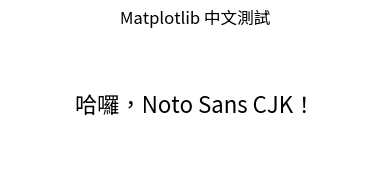

In [22]:
"""
跨平台載入 Noto Sans CJK 字型並驗證
在 VS Code + 本地 Python 環境執行
"""

import os
import sys
import platform
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---------- 1. 推斷各作業系統的預設字型路徑 ----------
def guess_noto_path() -> str | None:
    """回傳可能存在的 NotoSansCJK-Regular.ttc 路徑，找不到則回傳 None"""
    candidates = []

    match platform.system():
        case "Windows":
            candidates = [
                r"C:\Windows\Fonts\NotoSansCJK-Regular.ttc",
                r"C:\Windows\Fonts\NotoSansCJKtc-Regular.otf",
            ]
        case "Darwin":  # macOS
            candidates = [
                "/Library/Fonts/NotoSansCJK-Regular.ttc",
                "/System/Library/Fonts/NotoSansCJK.ttc",
            ]
        case "Linux":
            # 常見安裝位置；亦可加入 ~/.local/share/fonts
            candidates = [
                "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
                "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
                str(Path.home() / ".local/share/fonts/NotoSansCJK-Regular.ttc"),
            ]

    for p in candidates:
        if Path(p).is_file():
            return p
    return None


# ---------- 2. 取得字型路徑（可改為專案內相對路徑） ----------
# font_path = guess_noto_path()
font_path = 'NotoSansTC-Regular.ttf'  # 若已下載字型檔，請確認路徑正確

if font_path is None:
    # 若系統沒安裝，可改成專案相對路徑，例如 Path("fonts/NotoSansCJK-Regular.ttc")
    font_path = "fonts/NotoSansCJK-Regular.ttc"  # 請確認實際檔案位置
    if not Path(font_path).is_file():
        sys.exit(
            f"❌ 找不到 Noto Sans CJK 字型！\n"
            f"  請先安裝字型或把字型檔放到 {font_path}"
        )

# ---------- 3. 動態註冊並設定為預設中文字型 ----------
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()

# ---------- 4. 驗證 ----------
print("✅ 已載入字型：", plt.rcParams["font.family"])

# (可選) 畫個示範圖
plt.figure(figsize=(4, 2))
plt.title("Matplotlib 中文測試")
plt.text(0.5, 0.5, "哈囉，Noto Sans CJK！", ha="center", va="center", size=16)
plt.axis("off")
plt.tight_layout()
plt.show()


=== 製作SFSS篩選出的15個特徵相關性熱感圖 ===
final_dataset_sfss 資料集形狀: (67610, 17)
資料集欄位: ['CUST_NO', '工單升級趨勢', 'SUB_CAT_拆機挽回_RATIO', 'MAIN_CAT_帳務相關_RATIO', 'MAIN_CAT_帳務相關_COUNT', 'SUB_CAT_無法上網_RATIO', 'SUB_CAT_拆機挽回_COUNT', 'paytype_1', 'paymethod_廠商代收', 'MAIN_CAT_網路連線問題_RATIO', 'MAIN_CAT_網路連線問題_COUNT', 'MAIN_CAT_經銷商問題_RATIO', 'SUB_CAT_無法上網_COUNT', 'SUB_CAT_台哥大-電訪約裝_RATIO', 'SUB_CAT_用戶退租_RATIO', '平均繳款延遲日數', '使用狀態_編碼']

篩選出的特徵數量: 15
特徵列表:
 1. 工單升級趨勢
 2. SUB_CAT_拆機挽回_RATIO
 3. MAIN_CAT_帳務相關_RATIO
 4. MAIN_CAT_帳務相關_COUNT
 5. SUB_CAT_無法上網_RATIO
 6. SUB_CAT_拆機挽回_COUNT
 7. paytype_1
 8. paymethod_廠商代收
 9. MAIN_CAT_網路連線問題_RATIO
10. MAIN_CAT_網路連線問題_COUNT
11. MAIN_CAT_經銷商問題_RATIO
12. SUB_CAT_無法上網_COUNT
13. SUB_CAT_台哥大-電訪約裝_RATIO
14. SUB_CAT_用戶退租_RATIO
15. 平均繳款延遲日數

=== 資料預處理 ===
總空值數: 531714
有空值的欄位:
  工單升級趨勢: 17739 個空值
  SUB_CAT_拆機挽回_RATIO: 32289 個空值
  MAIN_CAT_帳務相關_RATIO: 32289 個空值
  MAIN_CAT_帳務相關_COUNT: 32289 個空值
  SUB_CAT_無法上網_RATIO: 32289 個空值
  SUB_CAT_拆機挽回_COUNT: 32289 個空值
  paytype_1: 52932 個空值
  paymet

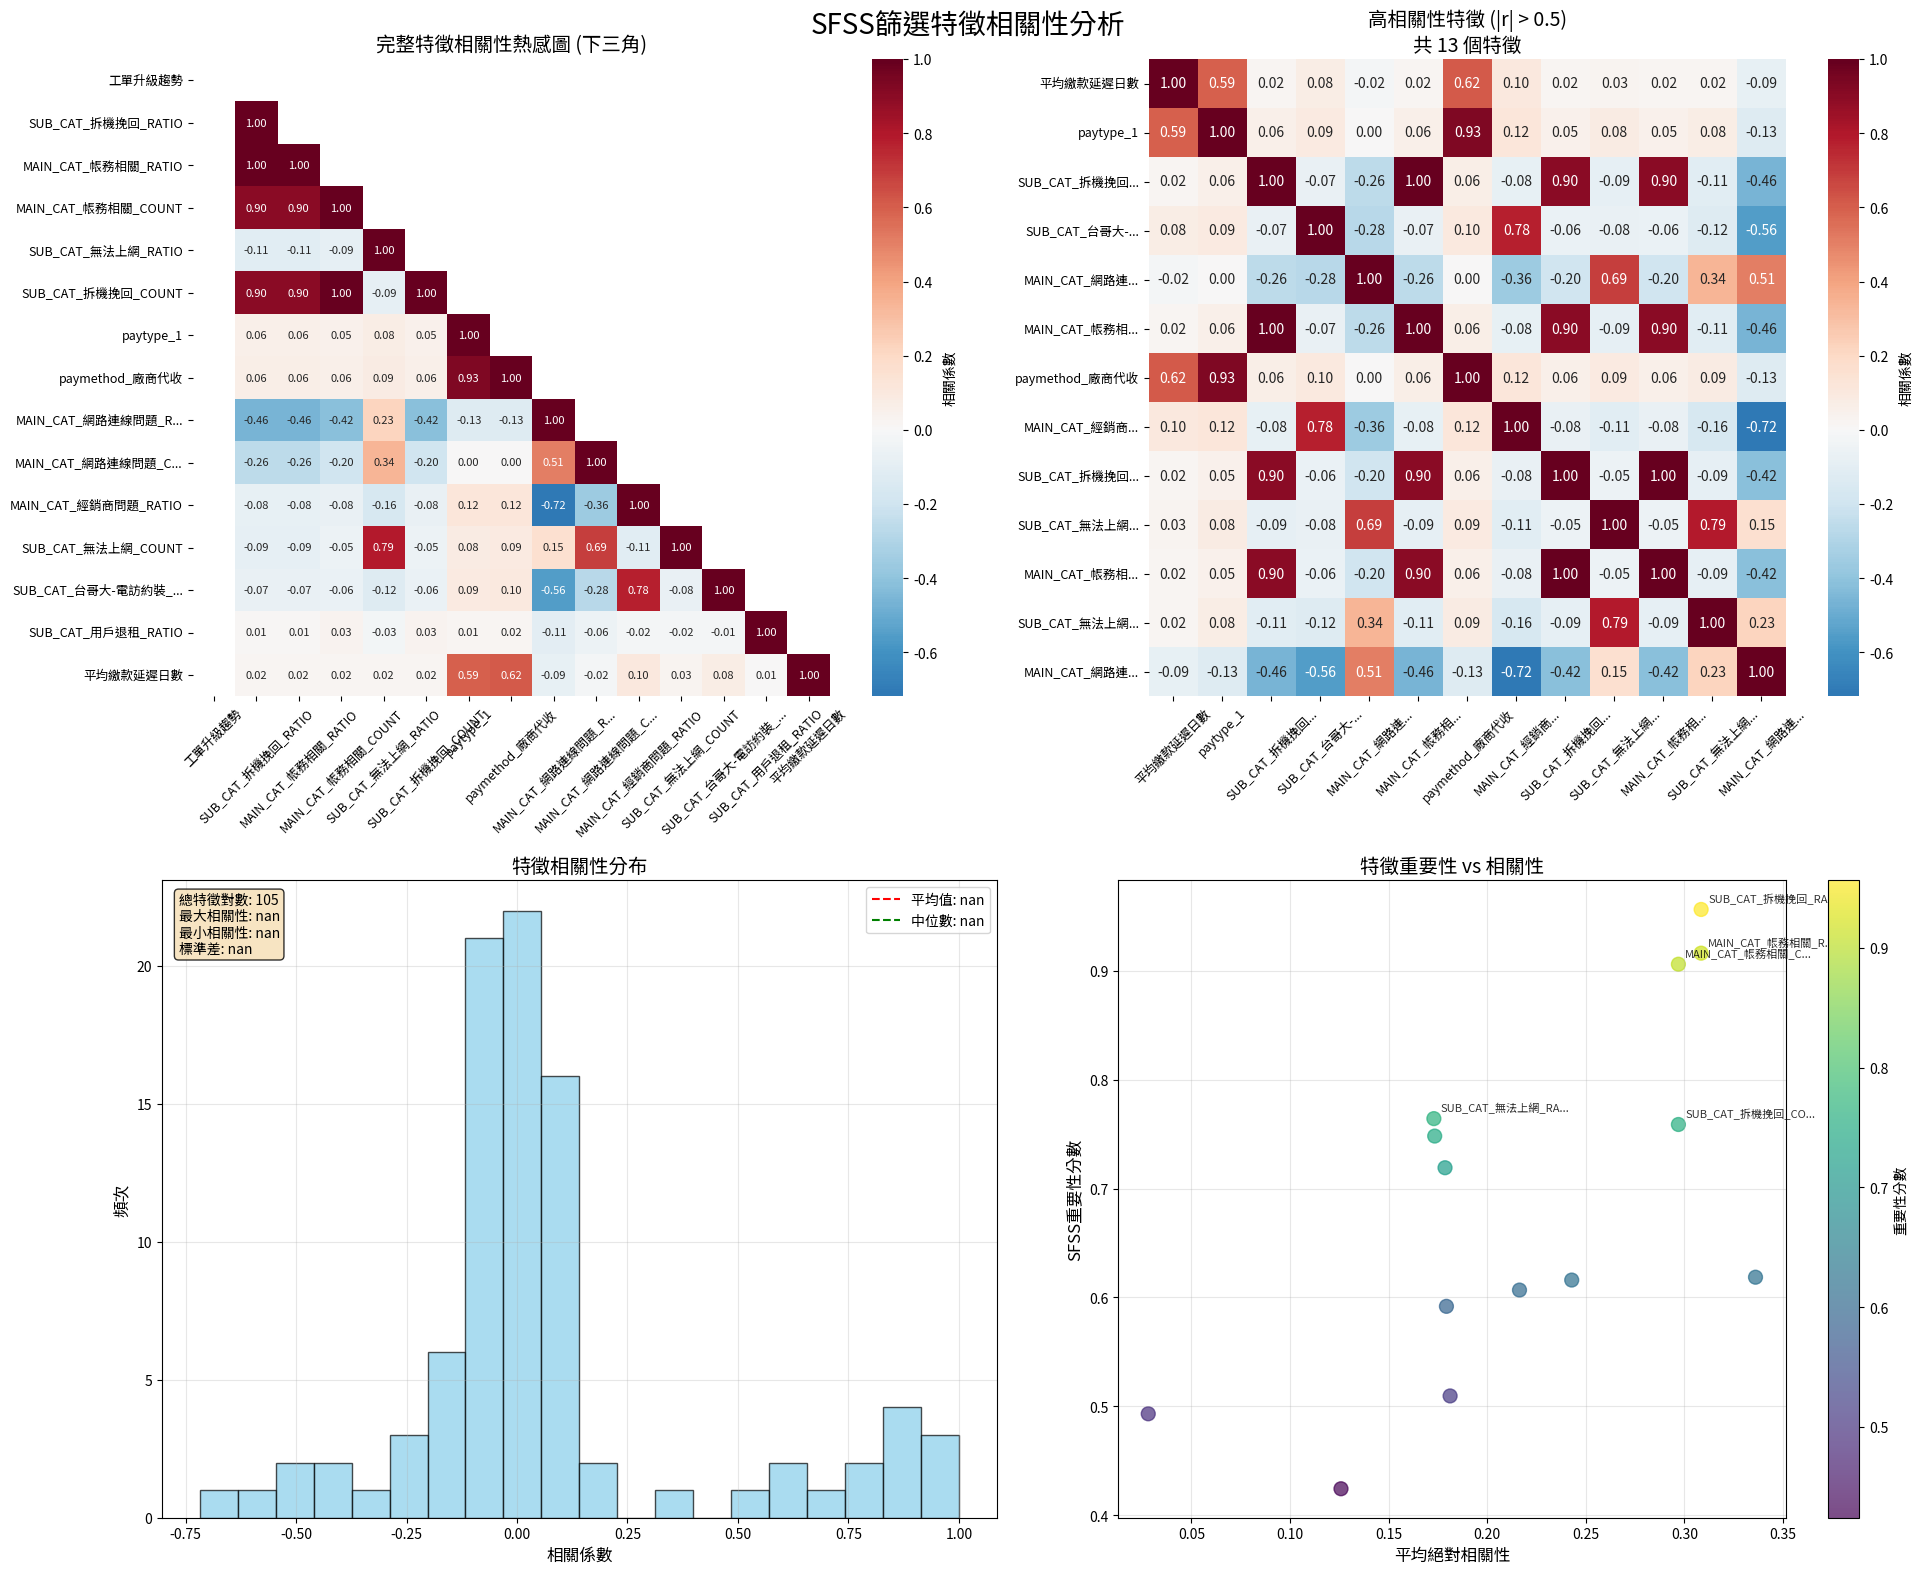


=== 相關性分析結果 ===
特徵數量: 15
特徵對數量: 105
相關係數統計:
  平均值: nan
  中位數: nan
  標準差: nan
  最大值: nan
  最小值: nan

相關性強度分布:
  強正相關 (> 0.7): 9 對
  中等正相關 (0.3-0.7): 5 對
  弱正相關 (0-0.3): 35 對
  弱負相關 (-0.3-0): 35 對
  中等負相關 (-0.7--0.3): 6 對
  強負相關 (< -0.7): 1 對

高相關性特徵對詳細列表:
 1. SUB_CAT_拆機挽回_RATIO             ↔ MAIN_CAT_帳務相關_RATIO            (r=1.000)
 2. MAIN_CAT_帳務相關_COUNT            ↔ SUB_CAT_拆機挽回_COUNT             (r=1.000)
 3. paytype_1                      ↔ paymethod_廠商代收                 (r=0.927)
 4. SUB_CAT_拆機挽回_RATIO             ↔ MAIN_CAT_帳務相關_COUNT            (r=0.895)
 5. SUB_CAT_拆機挽回_RATIO             ↔ SUB_CAT_拆機挽回_COUNT             (r=0.895)
 6. MAIN_CAT_帳務相關_RATIO            ↔ MAIN_CAT_帳務相關_COUNT            (r=0.895)
 7. MAIN_CAT_帳務相關_RATIO            ↔ SUB_CAT_拆機挽回_COUNT             (r=0.895)
 8. SUB_CAT_無法上網_RATIO             ↔ SUB_CAT_無法上網_COUNT             (r=0.788)
 9. MAIN_CAT_經銷商問題_RATIO           ↔ SUB_CAT_台哥大-電訪約裝_RATIO         (r=0.776)
10. MAIN_CAT_網路連線問題_RATIO          ↔ MAIN_

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 製作篩選出的15個特徵的相關性熱感圖
print("=== 製作SFSS篩選出的15個特徵相關性熱感圖 ===")

# 檢查 final_dataset_sfss 的基本資訊
print(f"final_dataset_sfss 資料集形狀: {final_dataset_sfss.shape}")
print(f"資料集欄位: {list(final_dataset_sfss.columns)}")

# 排除非特徵欄位，只保留特徵欄位
feature_cols = [col for col in final_dataset_sfss.columns 
               if col not in ['CUST_NO', '使用狀態', '使用狀態_編碼']]

print(f"\n篩選出的特徵數量: {len(feature_cols)}")
print(f"特徵列表:")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:2d}. {col}")

# 確保有足夠的特徵進行分析
if len(feature_cols) == 0:
    print("❌ 沒有找到可用的特徵欄位")
else:
    # 準備特徵資料
    feature_data = final_dataset_sfss[feature_cols].copy()
    
    # 處理空值
    print(f"\n=== 資料預處理 ===")
    null_counts = feature_data.isnull().sum()
    total_nulls = null_counts.sum()
    print(f"總空值數: {total_nulls}")
    
    if total_nulls > 0:
        print("有空值的欄位:")
        for col, count in null_counts[null_counts > 0].items():
            print(f"  {col}: {count} 個空值")
        
        # 填補空值
        feature_data = feature_data.fillna(feature_data.median())
        print("✅ 已用中位數填補空值")
    
    # 確保所有資料都是數值型
    for col in feature_data.columns:
        feature_data[col] = pd.to_numeric(feature_data[col], errors='coerce')
    
    # 再次處理可能產生的空值
    feature_data = feature_data.fillna(0)
    
    # 計算相關性矩陣
    print(f"\n=== 計算相關性矩陣 ===")
    correlation_matrix = feature_data.corr()
    print(f"相關性矩陣形狀: {correlation_matrix.shape}")
    
    # 設定中文字體
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS', 'SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    
    # 創建熱感圖
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('SFSS篩選特徵相關性分析', fontsize=20, fontweight='bold', y=0.98)
    
    # ==========================================
    # 圖1: 完整相關性熱感圖
    # ==========================================
    ax1 = axes[0, 0]
    
    # 調整特徵名稱長度以適應顯示
    display_names = []
    for col in feature_data.columns:
        if len(col) > 20:
            display_names.append(col[:17] + '...')
        else:
            display_names.append(col)
    
    # 重新命名相關性矩陣的行列
    correlation_display = correlation_matrix.copy()
    correlation_display.index = display_names
    correlation_display.columns = display_names
    
    mask = np.triu(np.ones_like(correlation_display, dtype=bool), k=1)  # 遮罩上三角
    
    sns.heatmap(correlation_display, 
                mask=mask,
                annot=True, 
                cmap='RdBu_r', 
                center=0,
                fmt='.2f',
                square=True,
                cbar_kws={'label': '相關係數'},
                ax=ax1,
                annot_kws={'size': 8})
    
    ax1.set_title('完整特徵相關性熱感圖 (下三角)', fontsize=14, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45, labelsize=9)
    ax1.tick_params(axis='y', rotation=0, labelsize=9)
    
    # ==========================================
    # 圖2: 高相關性特徵對 (|r| > 0.5)
    # ==========================================
    ax2 = axes[0, 1]
    
    # 找出高相關性的特徵對
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_val = correlation_matrix.iloc[i, j]
            if abs(corr_val) > 0.5:
                high_corr_pairs.append({
                    'feature1': correlation_matrix.columns[i],
                    'feature2': correlation_matrix.columns[j],
                    'correlation': corr_val
                })
    
    print(f"\n高相關性特徵對 (|r| > 0.5): {len(high_corr_pairs)} 對")
    
    if high_corr_pairs:
        # 創建高相關性特徵的子矩陣
        high_corr_features = list(set([pair['feature1'] for pair in high_corr_pairs] + 
                                    [pair['feature2'] for pair in high_corr_pairs]))
        
        if len(high_corr_features) > 1:
            high_corr_matrix = correlation_matrix.loc[high_corr_features, high_corr_features]
            
            # 調整特徵名稱
            high_corr_display_names = []
            for col in high_corr_features:
                if len(col) > 15:
                    high_corr_display_names.append(col[:12] + '...')
                else:
                    high_corr_display_names.append(col)
            
            high_corr_matrix.index = high_corr_display_names
            high_corr_matrix.columns = high_corr_display_names
            
            sns.heatmap(high_corr_matrix, 
                       annot=True, 
                       cmap='RdBu_r', 
                       center=0,
                       fmt='.2f',
                       square=True,
                       cbar_kws={'label': '相關係數'},
                       ax=ax2,
                       annot_kws={'size': 10})
            
            ax2.set_title(f'高相關性特徵 (|r| > 0.5)\n共 {len(high_corr_features)} 個特徵', 
                         fontsize=14, fontweight='bold')
        else:
            ax2.text(0.5, 0.5, '沒有發現高相關性\n特徵對 (|r| > 0.5)', 
                    ha='center', va='center', fontsize=12, transform=ax2.transAxes)
            ax2.set_title('高相關性特徵分析', fontsize=14, fontweight='bold')
    else:
        ax2.text(0.5, 0.5, '沒有發現高相關性\n特徵對 (|r| > 0.5)', 
                ha='center', va='center', fontsize=12, transform=ax2.transAxes)
        ax2.set_title('高相關性特徵分析', fontsize=14, fontweight='bold')
    
    ax2.tick_params(axis='x', rotation=45, labelsize=9)
    ax2.tick_params(axis='y', rotation=0, labelsize=9)
    
    # ==========================================
    # 圖3: 相關性分布直方圖
    # ==========================================
    ax3 = axes[1, 0]
    
    # 取得所有相關係數（不包括對角線）
    corr_values = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_values.append(correlation_matrix.iloc[i, j])
    
    # 繪製直方圖
    n_bins = min(20, len(corr_values) // 2) if len(corr_values) > 10 else 10
    ax3.hist(corr_values, bins=n_bins, alpha=0.7, color='skyblue', edgecolor='black')
    ax3.axvline(x=np.mean(corr_values), color='red', linestyle='--', 
               label=f'平均值: {np.mean(corr_values):.3f}')
    ax3.axvline(x=np.median(corr_values), color='green', linestyle='--', 
               label=f'中位數: {np.median(corr_values):.3f}')
    
    ax3.set_xlabel('相關係數', fontsize=12)
    ax3.set_ylabel('頻次', fontsize=12)
    ax3.set_title('特徵相關性分布', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # 添加統計資訊
    ax3.text(0.02, 0.98, f'總特徵對數: {len(corr_values)}\n'
                         f'最大相關性: {np.max(corr_values):.3f}\n'
                         f'最小相關性: {np.min(corr_values):.3f}\n'
                         f'標準差: {np.std(corr_values):.3f}',
            transform=ax3.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=10)
    
    # ==========================================
    # 圖4: 特徵重要性 vs 相關性散佈圖
    # ==========================================
    ax4 = axes[1, 1]
    
    # 如果有 SFSS 結果，顯示特徵重要性
    if 'sfss_results' in locals() and sfss_results:
        feature_scores = sfss_results.get('feature_scores', {})
        
        if feature_scores:
            # 準備散佈圖資料
            scatter_data = []
            
            for feature in feature_cols:
                importance = feature_scores.get(feature, 0)
                # 計算該特徵與其他特徵的平均絕對相關性
                other_features = [f for f in feature_cols if f != feature]
                if other_features:
                    avg_abs_corr = correlation_matrix.loc[feature, other_features].abs().mean()
                else:
                    avg_abs_corr = 0
                
                scatter_data.append({
                    'feature': feature,
                    'importance': importance,
                    'avg_abs_correlation': avg_abs_corr
                })
            
            # 繪製散佈圖
            scatter_df = pd.DataFrame(scatter_data)
            
            scatter = ax4.scatter(scatter_df['avg_abs_correlation'], 
                                scatter_df['importance'],
                                c=scatter_df['importance'], 
                                cmap='viridis', 
                                s=100, alpha=0.7)
            
            # 添加特徵名稱標註（只標註前5個重要特徵）
            top_features = scatter_df.nlargest(5, 'importance')
            for _, row in top_features.iterrows():
                feature_name = row['feature'][:15] + '...' if len(row['feature']) > 15 else row['feature']
                ax4.annotate(feature_name, 
                           (row['avg_abs_correlation'], row['importance']),
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=8, alpha=0.8)
            
            ax4.set_xlabel('平均絕對相關性', fontsize=12)
            ax4.set_ylabel('SFSS重要性分數', fontsize=12)
            ax4.set_title('特徵重要性 vs 相關性', fontsize=14, fontweight='bold')
            
            # 添加顏色條
            cbar = plt.colorbar(scatter, ax=ax4)
            cbar.set_label('重要性分數', fontsize=10)
            
            ax4.grid(alpha=0.3)
        else:
            ax4.text(0.5, 0.5, '無SFSS重要性\n分數資料', 
                    ha='center', va='center', fontsize=12, transform=ax4.transAxes)
            ax4.set_title('特徵重要性分析', fontsize=14, fontweight='bold')
    else:
        ax4.text(0.5, 0.5, '無SFSS結果\n資料可用', 
                ha='center', va='center', fontsize=12, transform=ax4.transAxes)
        ax4.set_title('特徵重要性分析', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()
    
    # ==========================================
    # 輸出詳細統計資訊
    # ==========================================
    print(f"\n=== 相關性分析結果 ===")
    print(f"特徵數量: {len(feature_cols)}")
    print(f"特徵對數量: {len(corr_values)}")
    print(f"相關係數統計:")
    print(f"  平均值: {np.mean(corr_values):.4f}")
    print(f"  中位數: {np.median(corr_values):.4f}")
    print(f"  標準差: {np.std(corr_values):.4f}")
    print(f"  最大值: {np.max(corr_values):.4f}")
    print(f"  最小值: {np.min(corr_values):.4f}")
    
    # 相關性強度分類
    strong_positive = sum(1 for x in corr_values if x > 0.7)
    moderate_positive = sum(1 for x in corr_values if 0.3 < x <= 0.7)
    weak_positive = sum(1 for x in corr_values if 0 < x <= 0.3)
    weak_negative = sum(1 for x in corr_values if -0.3 <= x < 0)
    moderate_negative = sum(1 for x in corr_values if -0.7 <= x < -0.3)
    strong_negative = sum(1 for x in corr_values if x < -0.7)
    
    print(f"\n相關性強度分布:")
    print(f"  強正相關 (> 0.7): {strong_positive} 對")
    print(f"  中等正相關 (0.3-0.7): {moderate_positive} 對")
    print(f"  弱正相關 (0-0.3): {weak_positive} 對")
    print(f"  弱負相關 (-0.3-0): {weak_negative} 對")
    print(f"  中等負相關 (-0.7--0.3): {moderate_negative} 對")
    print(f"  強負相關 (< -0.7): {strong_negative} 對")
    
    if high_corr_pairs:
        print(f"\n高相關性特徵對詳細列表:")
        for i, pair in enumerate(sorted(high_corr_pairs, 
                                       key=lambda x: abs(x['correlation']), 
                                       reverse=True)[:10], 1):
            print(f"{i:2d}. {pair['feature1'][:30]:<30} ↔ "
                  f"{pair['feature2'][:30]:<30} (r={pair['correlation']:.3f})")
    
    print(f"\n✅ 相關性熱感圖製作完成！")

# 刪除 `final_merged` 中的「使用狀態」欄位

- 需求：移除 `final_merged` DataFrame 的「使用狀態」欄位。
- 安全性：先檢查 `final_merged` 是否存在且包含該欄位，避免 KeyError。
- 輸出：列印刪除前後欄位數與欄位名清單，便於確認。

In [26]:
# 安全刪除 final_merged 的「使用狀態」欄位

# 檢查物件與欄位是否存在
if 'final_merged' not in globals():
    raise NameError("變數 final_merged 未定義。請先建立 final_merged 再執行此步驟。")

if not hasattr(final_merged, 'columns'):
    raise TypeError("final_merged 非 DataFrame 或缺少 columns 屬性。")

before_cols = list(final_merged.columns)

if "使用狀態" in final_merged.columns:
    final_merged = final_merged.drop(columns=["使用狀態"])  # 建立新物件，避免就地修改影響參照
    removed = True
else:
    removed = False

after_cols = list(final_merged.columns)

print("是否刪除：", removed)
print("刪除前欄位數：", len(before_cols))
print("刪除後欄位數：", len(after_cols))
print("刪除後欄位名前 20：", after_cols[:20])

是否刪除： True
刪除前欄位數： 201
刪除後欄位數： 200
刪除後欄位名前 20： ['CUST_NO', '平均繳款延遲日數', 'paytype_1', 'paytype_3', 'paytype_6', 'paytype_12', 'paytype_15', 'paytype_99', 'paymethod_APP臨櫃代收(7-11)', 'paymethod_CVS臨櫃代收(7-11)', 'paymethod_信用卡扣款', 'paymethod_其他繳款方式', 'paymethod_廠商代收', 'paymethod_當月繳帳單', 'paymethod_簡訊帳單臨櫃代收(7-11)', 'paymethod_金融機構轉帳', '工單原因_種類數', '工單原因_重複率', '工單嚴重程度_平均', '工單嚴重程度_最高']
